# Avaliação de BM25 com BGE-Reranker em datasets BEIR

Este notebook investiga um pipeline de recuperação em duas etapas: o **BM25** faz a recuperação lexical inicial e o **BGE-Reranker** reordena os candidatos com um *cross-encoder*. A avaliação utiliza SciFact, TREC-COVID e NF-Corpus, três coleções do benchmark BEIR com características bastante diferentes [1].

## Objetivo

Avaliar em que condições o reranqueamento neural melhora a qualidade do BM25, qual é seu custo computacional e quais tipos de query mais se beneficiam ou são prejudicados.

## Pipeline experimental

`query → BM25 top-100 → BGE-Reranker → ranking final → nDCG, MRR, Recall e MAP`

Além da comparação principal, o notebook inclui análises de custo, significância estatística, falhas por query, fusão RRF, visualizações qualitativas e classificadores exploratórios para aplicação seletiva do reranker.


### Instalação das dependências

Esta célula instala as bibliotecas necessárias no ambiente do Colab: `ir-datasets` para carregar os datasets BEIR, `rank-bm25` para a recuperação inicial, `transformers` para o reranker, além das bibliotecas de gráficos e embeddings usadas nas visualizações.


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
!pip -q install ir-datasets rank-bm25 transformers accelerate pandas tqdm matplotlib seaborn plotly scikit-learn faiss-cpu sentence-transformers scipy


### Imports, configurações e protocolo experimental

Aqui são importadas as bibliotecas usadas no notebook, definido o diretório de cache e configurado o experimento.

Configuração principal:

- recuperação inicial com `BM25Okapi`, usando tokenização lexical simples em minúsculas [5];
- `BM25_TOP_N = 100`: até 100 candidatos são entregues ao reranker;
- avaliação em `k = 5, 10 e 20`, com destaque para as métricas em `k = 10`;
- `BAAI/bge-reranker-base` como *cross-encoder* de reranqueamento [6];
- todas as queries disponíveis nos *splits* selecionados, pois `MAX_QUERIES_PER_DATASET = None`;
- execução em GPU quando CUDA está disponível;
- Dense Retrieval, busca híbrida e *sweep* do número de candidatos permanecem opcionais.

Os tempos medidos são tempos de consulta dentro desta implementação e deste ambiente de execução. Eles servem para comparar os pipelines no experimento, mas não representam um benchmark universal de latência.


In [14]:
import contextlib
import json
import logging
import math
import os
import re
import shutil
import time
from pathlib import Path

os.environ.setdefault("IR_DATASETS_HOME", "/content/ir_datasets")

import faiss
import ir_datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import torch
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from scipy.stats import wilcoxon
from sklearn.decomposition import PCA
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer

RERANKER_MODEL_NAME = "BAAI/bge-reranker-base"

BM25_TOP_N = 100
FINAL_TOP_K = 10
EVAL_K_VALUES = [5, 10, 20]
CANDIDATE_RECALL_N = BM25_TOP_N
BATCH_SIZE = 16

# Use None para avaliar todas as queries. Use um numero menor para teste rapido.
MAX_QUERIES_PER_DATASET = None

# Silencia logs/progresso de download e construção de docstore do ir_datasets.
SILENCE_IR_DATASETS_LOGS = True

# Desative se quiser rodar apenas BM25.
RUN_RERANKER = True

# Opcional: faz uma análise de trade-off variando o número de candidatos do BM25.
RUN_BM25_TOP_N_SWEEP = False
BM25_TOP_N_VALUES = [10, 25, 50, 100, 200]

# Opcional: Dense Retrieval com FAISS e Hybrid BM25 + Dense via RRF.
# Pode ser pesado, especialmente para TREC-COVID.
RUN_DENSE_RETRIEVAL = False
DENSE_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
DENSE_BATCH_SIZE = 128
DENSE_TOP_K = max(EVAL_K_VALUES)
HYBRID_RRF_K = 60

DATASETS = [
    {
        "name": "SciFact",
        "slug": "scifact",
        "docs_id": "beir/scifact",
        "eval_id": "beir/scifact/test",
    },
    {
        "name": "TREC-COVID",
        "slug": "trec_covid",
        "docs_id": "beir/trec-covid",
        "eval_id": "beir/trec-covid",
    },
    {
        "name": "NF-Corpus",
        "slug": "nfcorpus",
        "docs_id": "beir/nfcorpus",
        "eval_id": "beir/nfcorpus/test",
    },
]

sns.set_theme(style="whitegrid", context="notebook")

logging.getLogger("ir_datasets").setLevel(logging.ERROR)
logging.getLogger("ir_datasets.log").setLevel(logging.ERROR)
logging.getLogger("ir_datasets.util.download").setLevel(logging.ERROR)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE


'cuda'

### Carregamento dos datasets e recuperação BM25

Esta célula define funções para carregar documentos, queries e qrels de cada dataset BEIR. Ela também cria a tokenização simples, constrói o índice BM25 e implementa a função que recupera os documentos mais bem ranqueados pelo BM25.


In [15]:
@contextlib.contextmanager
def maybe_silence_ir_datasets():
    if SILENCE_IR_DATASETS_LOGS:
        with open(os.devnull, "w") as devnull:
            with contextlib.redirect_stdout(devnull), contextlib.redirect_stderr(devnull):
                yield
    else:
        yield


def load_beir_dataset(config, max_queries=None):
    with maybe_silence_ir_datasets():
        docs_dataset = ir_datasets.load(config["docs_id"])
        eval_dataset = ir_datasets.load(config["eval_id"])

        documents = {}
        for doc in docs_dataset.docs_iter():
            doc_id = str(doc.doc_id)
            title = getattr(doc, "title", "") or ""
            text = getattr(doc, "text", "") or ""
            documents[doc_id] = f"{title}. {text}".strip()

        queries = {}
        for query in eval_dataset.queries_iter():
            query_id = str(query.query_id)
            queries[query_id] = query.text
            if max_queries is not None and len(queries) >= max_queries:
                break

        selected_query_ids = set(queries.keys())
        qrels = {}
        for qrel in eval_dataset.qrels_iter():
            query_id = str(qrel.query_id)
            if query_id not in selected_query_ids:
                continue

            doc_id = str(qrel.doc_id)
            relevance = int(qrel.relevance)
            qrels.setdefault(query_id, {})[doc_id] = relevance

    queries = {query_id: text for query_id, text in queries.items() if query_id in qrels}
    return documents, queries, qrels


def tokenize(text):
    return re.findall(r"\w+", text.lower())


def build_bm25_index(documents):
    doc_ids = list(documents.keys())
    corpus = [documents[doc_id] for doc_id in doc_ids]
    tokenized_corpus = [tokenize(doc) for doc in tqdm(corpus, desc="Tokenizando corpus")]
    bm25 = BM25Okapi(tokenized_corpus)
    return bm25, doc_ids


def retrieve_bm25(query, bm25, doc_ids, top_k=10):
    scores = bm25.get_scores(tokenize(query))
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [
        {"doc_id": doc_ids[idx], "score": float(scores[idx])}
        for idx in top_indices
    ]


### Datasets avaliados e amostras

As coleções são carregadas por meio do `ir-datasets`, usando as versões disponibilizadas no benchmark BEIR [1].

- **SciFact**: recuperação de evidências científicas para verificar afirmações. A coleção original foi proposta por Wadden et al. [2]. Nesta execução, são avaliadas 300 queries sobre 5.183 documentos.
- **TREC-COVID**: recuperação de literatura científica relacionada à COVID-19, criada durante a pandemia para representar necessidades reais e mutáveis de informação biomédica [3]. Nesta execução, são avaliados 50 tópicos sobre 171.332 documentos.
- **NF-Corpus**: coleção médica que relaciona consultas, em geral curtas, a documentos científicos e informações de saúde [4]. Nesta execução, são avaliadas 323 queries sobre 3.633 documentos.

Os datasets diferem bastante no número de documentos relevantes por query. Isso é importante para interpretar o Recall: TREC-COVID possui centenas de julgamentos relevantes por tópico, enquanto SciFact normalmente possui poucos documentos de evidência.

Para tornar a estrutura concreta, a célula seguinte exibe exemplos de documentos, queries e qrels. O `qrels` contém os julgamentos de relevância usados somente na avaliação, nunca na recuperação.


In [16]:
def preview_text(text, max_chars=220):
    text = str(text).replace("\n", " ").strip()
    return text if len(text) <= max_chars else text[:max_chars] + "..."


def sample_dataset(config, n_docs=3, n_queries=3, n_qrels=5):
    with maybe_silence_ir_datasets():
        docs_dataset = ir_datasets.load(config["docs_id"])
        eval_dataset = ir_datasets.load(config["eval_id"])

        doc_rows = []
        doc_lookup = {}
        for doc in docs_dataset.docs_iter():
            doc_id = str(doc.doc_id)
            title = getattr(doc, "title", "") or ""
            text = getattr(doc, "text", "") or ""
            full_text = f"{title}. {text}".strip()
            doc_lookup[doc_id] = {
                "title": title,
                "text": text,
                "full_text": full_text,
            }
            if len(doc_rows) < n_docs:
                doc_rows.append({
                    "dataset": config["name"],
                    "doc_id": doc_id,
                    "title": preview_text(title, 120),
                    "text": preview_text(text),
                })

        query_rows = []
        query_lookup = {}
        for query in eval_dataset.queries_iter():
            query_id = str(query.query_id)
            query_lookup[query_id] = query.text
            if len(query_rows) < n_queries:
                query_rows.append({
                    "dataset": config["name"],
                    "query_id": query_id,
                    "query": preview_text(query.text),
                })

        qrel_rows = []
        for qrel in eval_dataset.qrels_iter():
            query_id = str(qrel.query_id)
            doc_id = str(qrel.doc_id)
            doc_info = doc_lookup.get(doc_id, {})
            qrel_rows.append({
                "dataset": config["name"],
                "query_id": query_id,
                "query": preview_text(query_lookup.get(query_id, ""), 180),
                "doc_id": doc_id,
                "relevance": int(qrel.relevance),
                "doc_title": preview_text(doc_info.get("title", ""), 120),
                "doc_preview": preview_text(doc_info.get("full_text", ""), 260),
            })
            if len(qrel_rows) >= n_qrels:
                break

    return (
        pd.DataFrame(doc_rows),
        pd.DataFrame(query_rows),
        pd.DataFrame(qrel_rows),
    )


sample_by_dataset = {}

for config in DATASETS:
    docs_sample, queries_sample, qrels_sample = sample_dataset(config)
    sample_by_dataset[config["slug"]] = {
        "documents": docs_sample,
        "queries": queries_sample,
        "qrels": qrels_sample,
    }

    print("=" * 100)
    print(f"Dataset: {config['name']}")

    print("\nDocumentos:")
    display(docs_sample)

    print("\nQueries:")
    display(queries_sample)

    print("\nQrels:")
    display(qrels_sample)


Dataset: SciFact

Documentos:


,dataset,doc_id,title,text
0,SciFact,4983,Microstructural development of human newborn c...,Alterations of the architecture of cerebral wh...
1,SciFact,5836,Induction of myelodysplasia by myeloid-derived...,Myelodysplastic syndromes (MDS) are age-depend...
2,SciFact,7912,"BC1 RNA, the transcript from a master gene for...",ID elements are short interspersed elements (S...



Queries:


,dataset,query_id,query
0,SciFact,1,0-dimensional biomaterials show inductive prop...
1,SciFact,3,"1,000 genomes project enables mapping of genet..."
2,SciFact,5,1/2000 in UK have abnormal PrP positivity.



Qrels:


...

,dataset,doc_id,title,text
0,NF-Corpus,MED-10,Statin Use and Breast Cancer Survival: A Natio...,"Recent studies have suggested that statins, an..."
1,NF-Corpus,MED-14,Statin use after diagnosis of breast cancer an...,BACKGROUND: Preclinical studies have shown tha...
2,NF-Corpus,MED-118,Alkylphenols in human milk and their relations...,The aims of this study were to determine the c...



Queries:


,dataset,query_id,query
0,NF-Corpus,PLAIN-2,Do Cholesterol Statin Drugs Cause Breast Cancer?
1,NF-Corpus,PLAIN-12,Exploiting Autophagy to Live Longer
2,NF-Corpus,PLAIN-23,How to Reduce Exposure to Alkylphenols Through...



Qrels:


,dataset,query_id,query,doc_id,relevance,doc_title,doc_preview
0,NF-Corpus,PLAIN-2,Do Cholesterol Statin Drugs Cause Breast Cancer?,MED-2427,2,Elevated Levels of Cholesterol-Rich Lipid Raft...,Elevated Levels of Cholesterol-Rich Lipid Raft...
1,NF-Corpus,PLAIN-2,Do Cholesterol Statin Drugs Cause Breast Cancer?,MED-10,2,Statin Use and Breast Cancer Survival: A Natio...,Statin Use and Breast Cancer Survival: A Natio...
2,NF-Corpus,PLAIN-2,Do Cholesterol Statin Drugs Cause Breast Cancer?,MED-2429,2,Statin use and risk of breast cancer: a meta-a...,Statin use and risk of breast cancer: a meta-a...
3,NF-Corpus,PLAIN-2,Do Cholesterol Statin Drugs Cause Breast Cancer?,MED-2430,2,beta-Sitosterol enhances tamoxifen effectivene...,beta-Sitosterol enhances tamoxifen effectivene...
4,NF-Corpus,PLAIN-2,Do Cholesterol Statin Drugs Cause Breast Cancer?,MED-2431,2,Long-term statin use and risk of ductal and lo...,Long-term statin use and risk of ductal and lo...


### Métricas de avaliação

As métricas são calculadas por query e depois agregadas pela média:

- **nDCG@k**: valoriza documentos relevantes nas primeiras posições e considera graus de relevância;
- **MRR@k**: mede o inverso da posição do primeiro documento relevante;
- **Recall@k**: fração dos documentos relevantes da query recuperada nas primeiras `k` posições;
- **MAP@k**: resume a precisão observada a cada documento relevante recuperado até `k`;
- **Candidate Recall@100**: mede a cobertura dos documentos relevantes antes do reranqueamento.

O Candidate Recall representa um limite estrutural do pipeline: o reranker apenas reorganiza os candidatos recuperados pelo BM25 e não consegue recuperar um documento ausente do top-100. Os resultados principais usam `k = 10`, enquanto `k = 5` e `k = 20` ajudam a verificar se a tendência se mantém em diferentes profundidades.


In [17]:

def dcg_at_k(relevances, k):
    dcg = 0.0
    for i, rel in enumerate(relevances[:k]):
        position = i + 1
        dcg += rel / math.log2(position + 1)
    return dcg


def ndcg_at_k(retrieved_doc_ids, relevant_docs, k):
    relevances = [relevant_docs.get(doc_id, 0) for doc_id in retrieved_doc_ids[:k]]
    dcg = dcg_at_k(relevances, k)
    ideal_relevances = sorted(relevant_docs.values(), reverse=True)
    idcg = dcg_at_k(ideal_relevances, k)
    return 0.0 if idcg == 0 else dcg / idcg


def mrr_at_k(retrieved_doc_ids, relevant_docs, k):
    for i, doc_id in enumerate(retrieved_doc_ids[:k]):
        if relevant_docs.get(doc_id, 0) > 0:
            return 1.0 / (i + 1)
    return 0.0


def recall_at_k(retrieved_doc_ids, relevant_docs, k):
    relevant_doc_ids = {
        doc_id for doc_id, relevance in relevant_docs.items() if relevance > 0
    }
    if not relevant_doc_ids:
        return 0.0
    retrieved_at_k = set(retrieved_doc_ids[:k])
    return len(retrieved_at_k.intersection(relevant_doc_ids)) / len(relevant_doc_ids)


def average_precision_at_k(retrieved_doc_ids, relevant_docs, k):
    relevant_doc_ids = {
        doc_id for doc_id, relevance in relevant_docs.items() if relevance > 0
    }
    if not relevant_doc_ids:
        return 0.0

    hits = 0
    precision_sum = 0.0
    for i, doc_id in enumerate(retrieved_doc_ids[:k], start=1):
        if doc_id in relevant_doc_ids:
            hits += 1
            precision_sum += hits / i

    return precision_sum / min(len(relevant_doc_ids), k)


def metric_values(retrieved_doc_ids, relevant_docs, k_values=EVAL_K_VALUES):
    values = {}
    for k in k_values:
        values[f"ndcg@{k}"] = ndcg_at_k(retrieved_doc_ids, relevant_docs, k)
        values[f"mrr@{k}"] = mrr_at_k(retrieved_doc_ids, relevant_docs, k)
        values[f"recall@{k}"] = recall_at_k(retrieved_doc_ids, relevant_docs, k)
        values[f"map@{k}"] = average_precision_at_k(retrieved_doc_ids, relevant_docs, k)

    values["ndcg"] = values[f"ndcg@{FINAL_TOP_K}"]
    values["mrr"] = values[f"mrr@{FINAL_TOP_K}"]
    values["recall"] = values[f"recall@{FINAL_TOP_K}"]
    values["map"] = values[f"map@{FINAL_TOP_K}"]
    return values


def timed_retrieve(retrieve_fn, query):
    start = time.perf_counter()
    retrieved = retrieve_fn(query)
    elapsed_sec = time.perf_counter() - start
    return retrieved, elapsed_sec


def ranking_rows(dataset_name, pipeline_name, query_id, query_text, retrieved, relevant_docs, documents):
    rows = []
    for rank, item in enumerate(retrieved, start=1):
        doc_id = item["doc_id"]
        doc_text = documents.get(doc_id, "")
        rows.append({
            "dataset": dataset_name,
            "pipeline": pipeline_name,
            "query_id": query_id,
            "query_text": query_text,
            "rank": rank,
            "doc_id": doc_id,
            "score": item.get("score"),
            "relevance": relevant_docs.get(doc_id, 0),
            "doc_text": doc_text,
            "doc_preview": preview_text(doc_text, 500) if "preview_text" in globals() else str(doc_text)[:500],
        })
    return rows


def grouped_ranking_rows(rankings_df):
    grouped_rows = []
    if rankings_df.empty:
        return pd.DataFrame(grouped_rows)

    sort_cols = ["dataset", "pipeline", "query_id", "rank"]
    rankings_df = rankings_df.sort_values(sort_cols)

    for (dataset, pipeline, query_id), group in rankings_df.groupby(["dataset", "pipeline", "query_id"], sort=False):
        query_text = group["query_text"].iloc[0]
        ranking = []
        for row in group.itertuples(index=False):
            ranking.append({
                "rank": int(row.rank),
                "doc_id": row.doc_id,
                "score": None if pd.isna(row.score) else float(row.score),
                "relevance": int(row.relevance),
                "doc_preview": row.doc_preview,
            })

        grouped_rows.append({
            "dataset": dataset,
            "pipeline": pipeline,
            "query_id": query_id,
            "query_text": query_text,
            "top_k": len(ranking),
            "ranking": ranking,
            "ranking_json": json.dumps(ranking, ensure_ascii=False),
        })

    return pd.DataFrame(grouped_rows)


def save_grouped_rankings_json(df, output_path):
    records = []
    for row in df.itertuples(index=False):
        ranking = row.ranking
        if isinstance(ranking, str):
            ranking = json.loads(ranking)

        records.append({
            "dataset": row.dataset,
            "pipeline": row.pipeline,
            "query_id": str(row.query_id),
            "query_text": row.query_text,
            "top_k": int(row.top_k),
            "ranking": ranking,
        })

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2, allow_nan=False)

    return output_path


def normalize_ranking_for_json(ranking):
    if isinstance(ranking, str):
        ranking = json.loads(ranking)

    normalized = []
    for item in ranking:
        normalized.append({
            "rank": int(item.get("rank")),
            "doc_id": str(item.get("doc_id")),
            "score": None if pd.isna(item.get("score")) else float(item.get("score")),
            "relevance": int(item.get("relevance", 0)),
            "doc_preview": item.get("doc_preview", ""),
        })
    return normalized


def build_bm25_bge_query_rankings(rankings_grouped_df):
    rows = []
    if rankings_grouped_df.empty:
        return rows

    for (dataset, query_id), group in rankings_grouped_df.groupby(["dataset", "query_id"], sort=False):
        bm25_group = group[group["pipeline"] == "BM25"]
        bge_group = group[group["pipeline"] == "BM25 + BGE-Reranker"]

        if bm25_group.empty and bge_group.empty:
            continue

        base_row = bm25_group.iloc[0] if not bm25_group.empty else bge_group.iloc[0]
        ranking_bm25 = [] if bm25_group.empty else normalize_ranking_for_json(bm25_group.iloc[0]["ranking"])
        ranking_bge = [] if bge_group.empty else normalize_ranking_for_json(bge_group.iloc[0]["ranking"])

        rows.append({
            "dataset": dataset,
            "query_id": str(query_id),
            "query": base_row["query_text"],
            "ranking_bm25": ranking_bm25,
            "ranking_bge": ranking_bge,
        })

    return rows


def save_bm25_bge_query_rankings_json(rankings_grouped_df, output_path):
    rows = build_bm25_bge_query_rankings(rankings_grouped_df)
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(rows, f, ensure_ascii=False, indent=2, allow_nan=False)
    return rows

def evaluate_retrieved(dataset_name, pipeline_name, queries, qrels, retrieve_fn, documents, top_k=10):
    metric_rows = []
    all_ranking_rows = []

    for query_id, query_text in tqdm(queries.items(), desc=f"{dataset_name} | {pipeline_name}"):
        relevant_docs = qrels[query_id]
        retrieved, elapsed_sec = timed_retrieve(retrieve_fn, query_text)
        retrieved_doc_ids = [item["doc_id"] for item in retrieved]
        metrics = metric_values(retrieved_doc_ids, relevant_docs)

        metric_rows.append({
            "dataset": dataset_name,
            "pipeline": pipeline_name,
            "query_id": query_id,
            "query_text": query_text,
            "elapsed_sec": elapsed_sec,
            **metrics,
        })
        all_ranking_rows.extend(
            ranking_rows(dataset_name, pipeline_name, query_id, query_text, retrieved[:top_k], relevant_docs, documents)
        )

    rankings_df = pd.DataFrame(all_ranking_rows)
    grouped_rankings_df = grouped_ranking_rows(rankings_df)
    return pd.DataFrame(metric_rows), rankings_df, grouped_rankings_df


def candidate_recall_at_n(query_text, relevant_docs, bm25, doc_ids, n=100):
    bm25_candidates = retrieve_bm25(query_text, bm25, doc_ids, top_k=n)
    candidate_ids = {item["doc_id"] for item in bm25_candidates}
    relevant_ids = {
        doc_id for doc_id, rel in relevant_docs.items() if rel > 0
    }

    if not relevant_ids:
        return 0.0

    return len(candidate_ids & relevant_ids) / len(relevant_ids)


def evaluate_candidate_recall(dataset_name, queries, qrels, bm25, doc_ids, n=100):
    rows = []
    for query_id, query_text in tqdm(queries.items(), desc=f"{dataset_name} | Candidate Recall@{n}"):
        rows.append({
            "dataset": dataset_name,
            "query_id": query_id,
            f"candidate_recall@{n}": candidate_recall_at_n(
                query_text,
                qrels[query_id],
                bm25,
                doc_ids,
                n=n,
            ),
        })
    return pd.DataFrame(rows)


def summarize_results(df):
    aggregations = {
        "nDCG@10": ("ndcg", "mean"),
        "MRR@10": ("mrr", "mean"),
        "Recall@10": ("recall", "mean"),
        "MAP@10": ("map", "mean"),
        "avg_time_sec": ("elapsed_sec", "mean"),
        "total_time_sec": ("elapsed_sec", "sum"),
        "num_queries": ("query_id", "count"),
    }

    for k in EVAL_K_VALUES:
        aggregations[f"nDCG@{k}"] = (f"ndcg@{k}", "mean")
        aggregations[f"MRR@{k}"] = (f"mrr@{k}", "mean")
        aggregations[f"Recall@{k}"] = (f"recall@{k}", "mean")
        aggregations[f"MAP@{k}"] = (f"map@{k}", "mean")

    return (
        df.groupby(["dataset", "pipeline"], as_index=False)
        .agg(**aggregations)
        .sort_values(["dataset", "pipeline"])
        .reset_index(drop=True)
    )


### Reranker BGE


In [18]:
def load_reranker(model_name=RERANKER_MODEL_NAME):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    model.to(DEVICE)
    model.eval()
    return tokenizer, model


@torch.no_grad()
def rerank_documents(query, bm25_results, documents, tokenizer, model, batch_size=BATCH_SIZE):
    pairs = []
    doc_ids = []

    for item in bm25_results:
        doc_id = item["doc_id"]
        pairs.append((query, documents[doc_id]))
        doc_ids.append(doc_id)

    all_scores = []
    for start in range(0, len(pairs), batch_size):
        batch_pairs = pairs[start:start + batch_size]
        inputs = tokenizer(
            batch_pairs,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt",
        )
        inputs = {key: value.to(DEVICE) for key, value in inputs.items()}
        outputs = model(**inputs)
        scores = outputs.logits.squeeze(-1).detach().cpu().tolist()
        if isinstance(scores, float):
            scores = [scores]
        all_scores.extend(scores)

    reranked = [
        {"doc_id": doc_id, "score": float(score)}
        for doc_id, score in zip(doc_ids, all_scores)
    ]
    return sorted(reranked, key=lambda x: x["score"], reverse=True)


def retrieve_bm25_plus_reranker(
    query,
    bm25,
    doc_ids,
    documents,
    tokenizer,
    model,
    bm25_top_n=100,
    final_top_k=10,
):
    bm25_candidates = retrieve_bm25(query, bm25, doc_ids, top_k=bm25_top_n)
    reranked_results = rerank_documents(
        query=query,
        bm25_results=bm25_candidates,
        documents=documents,
        tokenizer=tokenizer,
        model=model,
    )
    return reranked_results[:final_top_k]

### Inicialização do reranker


In [19]:
tokenizer = None
reranker_model = None

if RUN_RERANKER:
    print("Carregando BGE-Reranker...")
    tokenizer, reranker_model = load_reranker()

print("Device:", DEVICE)

Carregando BGE-Reranker...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Device: cuda


### Execução dos experimentos


In [20]:

all_results = []
all_rankings = []
all_grouped_rankings = []
candidate_recall_results = []
experiment_cache = {}

for config in DATASETS:
    print("=" * 80)
    print(f"Dataset: {config['name']}")
    print("Carregando dataset...")

    documents, queries, qrels = load_beir_dataset(
        config,
        max_queries=MAX_QUERIES_PER_DATASET,
    )

    print(f"Documentos: {len(documents)}")
    print(f"Queries avaliadas: {len(queries)}")
    print(f"Qrels: {len(qrels)}")

    print("Construindo indice BM25...")
    bm25, doc_ids = build_bm25_index(documents)
    experiment_cache[config["slug"]] = {
        "config": config,
        "documents": documents,
        "queries": queries,
        "qrels": qrels,
        "bm25": bm25,
        "doc_ids": doc_ids,
    }

    candidate_recall_df = evaluate_candidate_recall(
        dataset_name=config["name"],
        queries=queries,
        qrels=qrels,
        bm25=bm25,
        doc_ids=doc_ids,
        n=CANDIDATE_RECALL_N,
    )
    candidate_recall_df.to_csv(f"candidate_recall_{config['slug']}.csv", index=False)
    candidate_recall_results.append(candidate_recall_df)

    bm25_df, bm25_rankings, bm25_grouped_rankings = evaluate_retrieved(
        dataset_name=config["name"],
        pipeline_name="BM25",
        queries=queries,
        qrels=qrels,
        retrieve_fn=lambda query, bm25=bm25, doc_ids=doc_ids: retrieve_bm25(
            query,
            bm25,
            doc_ids,
            top_k=max(EVAL_K_VALUES),
        ),
        documents=documents,
        top_k=max(EVAL_K_VALUES),
    )
    bm25_df.to_csv(f"results_{config['slug']}_bm25.csv", index=False)
    bm25_rankings.to_csv(f"rankings_{config['slug']}_bm25.csv", index=False)
    bm25_grouped_rankings.to_csv(f"rankings_grouped_{config['slug']}_bm25.csv", index=False)
    save_grouped_rankings_json(bm25_grouped_rankings, f"rankings_grouped_{config['slug']}_bm25.json")
    all_results.append(bm25_df)
    all_rankings.append(bm25_rankings)
    all_grouped_rankings.append(bm25_grouped_rankings)

    if RUN_RERANKER:
        reranker_df, reranker_rankings, reranker_grouped_rankings = evaluate_retrieved(
            dataset_name=config["name"],
            pipeline_name="BM25 + BGE-Reranker",
            queries=queries,
            qrels=qrels,
            retrieve_fn=lambda query, bm25=bm25, doc_ids=doc_ids, documents=documents: retrieve_bm25_plus_reranker(
                query=query,
                bm25=bm25,
                doc_ids=doc_ids,
                documents=documents,
                tokenizer=tokenizer,
                model=reranker_model,
                bm25_top_n=BM25_TOP_N,
                final_top_k=max(EVAL_K_VALUES),
            ),
            documents=documents,
            top_k=max(EVAL_K_VALUES),
        )
        reranker_df.to_csv(f"results_{config['slug']}_bm25_bge_reranker.csv", index=False)
        reranker_rankings.to_csv(f"rankings_{config['slug']}_bm25_bge_reranker.csv", index=False)
        reranker_grouped_rankings.to_csv(f"rankings_grouped_{config['slug']}_bm25_bge_reranker.csv", index=False)
        save_grouped_rankings_json(reranker_grouped_rankings, f"rankings_grouped_{config['slug']}_bm25_bge_reranker.json")
        all_results.append(reranker_df)
        all_rankings.append(reranker_rankings)
        all_grouped_rankings.append(reranker_grouped_rankings)

results_all = pd.concat(all_results, ignore_index=True)
rankings_all = pd.concat(all_rankings, ignore_index=True)
rankings_grouped_all = pd.concat(all_grouped_rankings, ignore_index=True)
candidate_recall_all = pd.concat(candidate_recall_results, ignore_index=True)
summary = summarize_results(results_all)

candidate_recall_summary = (
    candidate_recall_all
    .groupby("dataset", as_index=False)[f"candidate_recall@{CANDIDATE_RECALL_N}"]
    .mean()
)

summary = summary.merge(candidate_recall_summary, on="dataset", how="left")

results_all.to_csv("results_all_datasets.csv", index=False)
rankings_all.to_csv("rankings_all_datasets.csv", index=False)
rankings_grouped_all.to_csv("rankings_grouped_all_datasets.csv", index=False)
save_grouped_rankings_json(rankings_grouped_all, "rankings_grouped_all_datasets.json")

if RUN_RERANKER:
    query_rankings_bm25_vs_bge = save_bm25_bge_query_rankings_json(
        rankings_grouped_all,
        "query_rankings_bm25_vs_bge_all_datasets.json",
    )

    for config in DATASETS:
        dataset_grouped_rankings = rankings_grouped_all[
            rankings_grouped_all["dataset"] == config["name"]
        ]
        save_bm25_bge_query_rankings_json(
            dataset_grouped_rankings,
            f"query_rankings_bm25_vs_bge_{config['slug']}.json",
        )
candidate_recall_all.to_csv("candidate_recall_all_datasets.csv", index=False)
summary.to_csv("summary_all_datasets.csv", index=False)

print("Exemplo de ranking agrupado por query:")
display(rankings_grouped_all.head(3))

summary


Dataset: SciFact
Carregando dataset...
Documentos: 5183
Queries avaliadas: 300
Qrels: 300
Construindo indice BM25...


Tokenizando corpus:   0%|          | 0/5183 [00:00<?, ?it/s]

SciFact | Candidate Recall@100:   0%|          | 0/300 [00:00<?, ?it/s]

SciFact | BM25:   0%|          | 0/300 [00:00<?, ?it/s]

SciFact | BM25 + BGE-Reranker:   0%|          | 0/300 [00:00<?, ?it/s]

...

NF-Corpus | BM25:   0%|          | 0/323 [00:00<?, ?it/s]

NF-Corpus | BM25 + BGE-Reranker:   0%|          | 0/323 [00:00<?, ?it/s]

Exemplo de ranking agrupado por query:


,dataset,pipeline,query_id,query_text,top_k,ranking,ranking_json
0,SciFact,BM25,1,0-dimensional biomaterials show inductive prop...,20,"[{'rank': 1, 'doc_id': '10608397', 'score': 10...","[{""rank"": 1, ""doc_id"": ""10608397"", ""score"": 10..."
1,SciFact,BM25,100,All hematopoietic stem cells segregate their c...,20,"[{'rank': 1, 'doc_id': '4381486', 'score': 32....","[{""rank"": 1, ""doc_id"": ""4381486"", ""score"": 32...."
2,SciFact,BM25,1012,Radioiodine treatment of non-toxic multinodula...,20,"[{'rank': 1, 'doc_id': '9745001', 'score': 68....","[{""rank"": 1, ""doc_id"": ""9745001"", ""score"": 68...."


,dataset,pipeline,nDCG@10,MRR@10,Recall@10,MAP@10,avg_time_sec,total_time_sec,num_queries,nDCG@5,MRR@5,Recall@5,MAP@5,nDCG@20,MRR@20,Recall@20,MAP@20,candidate_recall@100
0,NF-Corpus,BM25,0.306317,0.508971,0.152153,0.219001,0.004985,1.610298,323,0.334028,0.499742,0.115050,0.268051,0.278253,0.510282,0.172116,0.178807,0.235936
1,NF-Corpus,BM25 + BGE-Reranker,0.308620,0.527299,0.142758,0.219340,3.249737,1049.665175,323,0.343844,0.520795,0.115398,0.274281,0.280110,0.529833,0.167174,0.178012,0.235936
2,SciFact,BM25,0.651893,0.618615,0.774000,0.606975,0.019358,5.807493,300,0.636032,0.613222,0.728444,0.599106,0.667184,0.622329,0.832278,0.611460,0.873056
3,SciFact,BM25 + BGE-Reranker,0.694917,0.669444,0.801833,0.654127,3.298408,989.522298,300,0.676903,0.663000,0.752611,0.645000,0.706466,0.672174,0.845722,0.657581,0.873056
4,TREC-COVID,BM25,0.576817,0.758000,0.015293,0.523202,0.972226,48.611324,50,0.606150,0.751333,0.007984,0.573867,0.524540,0.759667,0.027364,0.448882,0.093570
5,TREC-COVID,BM25 + BGE-Reranker,0.643443,0.871524,0.016341,0.605649,4.115285,205.764230,50,0.691654,0.868667,0.009265,0.686733,0.617824,0.871524,0.031637,0.559027,0.093570


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Exemplo do JSON BM25 vs BGE por query

Esta célula mostra um exemplo do novo formato pedido: cada objeto contém uma query e os rankings `ranking_bm25` e `ranking_bge` lado a lado.


In [22]:
if RUN_RERANKER and "query_rankings_bm25_vs_bge" in globals():
    print("Exemplo de query com rankings BM25 e BGE lado a lado:")
    display(pd.DataFrame(query_rankings_bm25_vs_bge[:3]))
else:
    print("Execute a célula principal dos experimentos com RUN_RERANKER=True para gerar query_rankings_bm25_vs_bge.")


Exemplo de query com rankings BM25 e BGE lado a lado:


,dataset,query_id,query,ranking_bm25,ranking_bge
0,SciFact,1,0-dimensional biomaterials show inductive prop...,"[{'rank': 1, 'doc_id': '10608397', 'score': 10...","[{'rank': 1, 'doc_id': '38037690', 'score': -6..."
1,SciFact,100,All hematopoietic stem cells segregate their c...,"[{'rank': 1, 'doc_id': '4381486', 'score': 32....","[{'rank': 1, 'doc_id': '4381486', 'score': 4.6..."
2,SciFact,1012,Radioiodine treatment of non-toxic multinodula...,"[{'rank': 1, 'doc_id': '9745001', 'score': 68....","[{'rank': 1, 'doc_id': '9745001', 'score': 8.1..."


## Estatísticas descritivas dos datasets e qrels

Esta seção resume o tamanho e o perfil dos datasets já carregados: quantidade de documentos, queries, tamanho médio dos textos e distribuição de documentos relevantes por query no `qrels`. Isso ajuda a contextualizar os resultados.


,dataset,dataset_slug,num_documents,num_queries,num_qrels_queries,avg_doc_tokens,median_doc_tokens,avg_query_tokens,median_query_tokens,avg_relevant_docs_per_query,median_relevant_docs_per_query,max_relevant_docs_per_query
0,SciFact,scifact,5183,300,300,225.325101,213.0,13.066667,12.0,1.130000,1.0,5
1,TREC-COVID,trec_covid,171332,50,50,169.420885,176.0,11.720000,11.0,493.460000,478.0,1266
2,NF-Corpus,nfcorpus,3633,323,323,245.792458,250.0,3.352941,2.0,38.185759,16.0,475


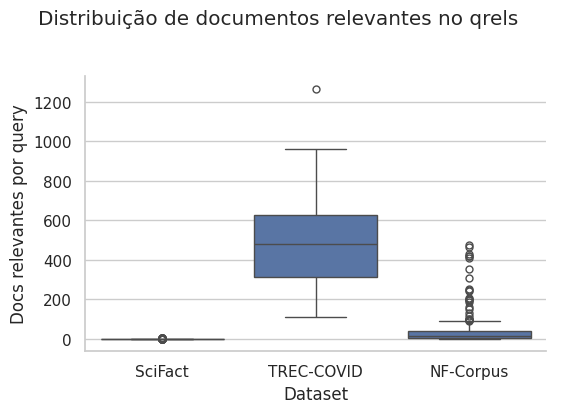

In [23]:
dataset_stats_rows = []
qrels_distribution_rows = []

for slug, case in experiment_cache.items():
    documents = case["documents"]
    queries = case["queries"]
    qrels = case["qrels"]

    doc_lengths = np.array([len(tokenize(text)) for text in documents.values()])
    query_lengths = np.array([len(tokenize(text)) for text in queries.values()])
    relevant_counts = np.array([
        sum(1 for relevance in rels.values() if relevance > 0)
        for rels in qrels.values()
    ])

    dataset_stats_rows.append({
        "dataset": case["config"]["name"],
        "dataset_slug": slug,
        "num_documents": len(documents),
        "num_queries": len(queries),
        "num_qrels_queries": len(qrels),
        "avg_doc_tokens": float(doc_lengths.mean()) if len(doc_lengths) else 0.0,
        "median_doc_tokens": float(np.median(doc_lengths)) if len(doc_lengths) else 0.0,
        "avg_query_tokens": float(query_lengths.mean()) if len(query_lengths) else 0.0,
        "median_query_tokens": float(np.median(query_lengths)) if len(query_lengths) else 0.0,
        "avg_relevant_docs_per_query": float(relevant_counts.mean()) if len(relevant_counts) else 0.0,
        "median_relevant_docs_per_query": float(np.median(relevant_counts)) if len(relevant_counts) else 0.0,
        "max_relevant_docs_per_query": int(relevant_counts.max()) if len(relevant_counts) else 0,
    })

    for query_id, rels in qrels.items():
        qrels_distribution_rows.append({
            "dataset": case["config"]["name"],
            "dataset_slug": slug,
            "query_id": query_id,
            "num_relevant_docs": sum(1 for relevance in rels.values() if relevance > 0),
            "num_judged_docs": len(rels),
        })

dataset_stats = pd.DataFrame(dataset_stats_rows)
qrels_distribution = pd.DataFrame(qrels_distribution_rows)

dataset_stats.to_csv("dataset_descriptive_stats.csv", index=False)
qrels_distribution.to_csv("qrels_distribution_by_query.csv", index=False)

display(dataset_stats)

g = sns.catplot(
    data=qrels_distribution,
    kind="box",
    x="dataset",
    y="num_relevant_docs",
    height=4,
    aspect=1.4,
)
g.set_axis_labels("Dataset", "Docs relevantes por query")
g.figure.suptitle("Distribuição de documentos relevantes no qrels", y=1.03)
g.figure.tight_layout()
g.figure.savefig("qrels_relevance_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


### Tabela comparativa em formato pivotado


In [24]:
summary_pivot = summary.pivot(
    index="dataset",
    columns="pipeline",
    values=["nDCG@10", "MRR@10", "Recall@10"],
)
summary_pivot

nDCG@10                        MRR@10                      \
pipeline        BM25 BM25 + BGE-Reranker      BM25 BM25 + BGE-Reranker   
dataset                                                                  
NF-Corpus   0.306317            0.308620  0.508971            0.527299   
SciFact     0.651893            0.694917  0.618615            0.669444   
TREC-COVID  0.576817            0.643443  0.758000            0.871524   

           Recall@10                      
pipeline        BM25 BM25 + BGE-Reranker  
dataset                                   
NF-Corpus   0.152153            0.142758  
SciFact     0.774000            0.801833  
TREC-COVID  0.015293            0.016341

## OPCIONAL: Dense Retrieval com FAISS e Hybrid Retrieval

Esta seção implementa Dense Retrieval com FAISS e recuperação híbrida BM25+Dense. Ela fica desligada por padrão porque gerar embeddings de todos os documentos pode ser pesado. Para ativar, mude:

```python
RUN_DENSE_RETRIEVAL = True
```


In [25]:
def build_faiss_dense_index(documents, dense_model, batch_size=DENSE_BATCH_SIZE):
    dense_doc_ids = list(documents.keys())
    doc_texts = [documents[doc_id] for doc_id in dense_doc_ids]
    doc_embeddings = dense_model.encode(
        doc_texts,
        batch_size=batch_size,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    ).astype("float32")
    dense_index = faiss.IndexFlatIP(doc_embeddings.shape[1])
    dense_index.add(doc_embeddings)
    return dense_index, dense_doc_ids, doc_embeddings


def retrieve_dense_faiss(query, dense_model, dense_index, dense_doc_ids, top_k=10):
    query_embedding = dense_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    ).astype("float32")
    scores, indices = dense_index.search(query_embedding, top_k)
    return [
        {"doc_id": dense_doc_ids[int(idx)], "score": float(score)}
        for score, idx in zip(scores[0], indices[0])
        if idx != -1
    ]


def reciprocal_rank_fusion(rankings, rrf_k=60, top_k=10):
    fused_scores = {}
    for ranking in rankings:
        for rank, item in enumerate(ranking, start=1):
            doc_id = item["doc_id"]
            fused_scores[doc_id] = fused_scores.get(doc_id, 0.0) + 1.0 / (rrf_k + rank)
    fused = [{"doc_id": doc_id, "score": score} for doc_id, score in fused_scores.items()]
    return sorted(fused, key=lambda item: item["score"], reverse=True)[:top_k]


def retrieve_hybrid_rrf(query, bm25, doc_ids, dense_model, dense_index, dense_doc_ids, candidate_n=100, top_k=10):
    bm25_results = retrieve_bm25(query, bm25, doc_ids, top_k=candidate_n)
    dense_results = retrieve_dense_faiss(query, dense_model, dense_index, dense_doc_ids, top_k=candidate_n)
    return reciprocal_rank_fusion([bm25_results, dense_results], rrf_k=HYBRID_RRF_K, top_k=top_k)


def retrieve_dense_plus_reranker(query, dense_model, dense_index, dense_doc_ids, documents, tokenizer, model, dense_top_n=100, final_top_k=10):
    dense_candidates = retrieve_dense_faiss(query, dense_model, dense_index, dense_doc_ids, top_k=dense_top_n)
    return rerank_documents(query, dense_candidates, documents, tokenizer, model)[:final_top_k]


def retrieve_hybrid_plus_reranker(query, bm25, doc_ids, dense_model, dense_index, dense_doc_ids, documents, tokenizer, model, candidate_n=100, final_top_k=10):
    hybrid_candidates = retrieve_hybrid_rrf(query, bm25, doc_ids, dense_model, dense_index, dense_doc_ids, candidate_n=candidate_n, top_k=candidate_n)
    return rerank_documents(query, hybrid_candidates, documents, tokenizer, model)[:final_top_k]


In [26]:
dense_hybrid_results = []
dense_hybrid_rankings = []
dense_hybrid_grouped_rankings = []
dense_hybrid_summary = pd.DataFrame()

if RUN_DENSE_RETRIEVAL:
    dense_model = SentenceTransformer(DENSE_MODEL_NAME, device=DEVICE)

    for slug, case in experiment_cache.items():
        config = case["config"]
        documents = case["documents"]
        queries = case["queries"]
        qrels = case["qrels"]
        bm25 = case["bm25"]
        doc_ids = case["doc_ids"]

        print("=" * 80)
        print(f"Dense/Hybrid | Dataset: {config['name']}")
        dense_index, dense_doc_ids, dense_doc_embeddings = build_faiss_dense_index(documents, dense_model)

        optional_pipelines = [
            ("Dense Retrieval", lambda query, dense_model=dense_model, dense_index=dense_index, dense_doc_ids=dense_doc_ids: retrieve_dense_faiss(query, dense_model, dense_index, dense_doc_ids, top_k=max(EVAL_K_VALUES)), "dense"),
            ("Hybrid BM25 + Dense", lambda query, bm25=bm25, doc_ids=doc_ids, dense_model=dense_model, dense_index=dense_index, dense_doc_ids=dense_doc_ids: retrieve_hybrid_rrf(query, bm25, doc_ids, dense_model, dense_index, dense_doc_ids, candidate_n=BM25_TOP_N, top_k=max(EVAL_K_VALUES)), "hybrid_rrf"),
        ]

        if RUN_RERANKER:
            optional_pipelines.extend([
                ("Dense Retrieval + BGE-Reranker", lambda query, dense_model=dense_model, dense_index=dense_index, dense_doc_ids=dense_doc_ids, documents=documents: retrieve_dense_plus_reranker(query, dense_model, dense_index, dense_doc_ids, documents, tokenizer, reranker_model, dense_top_n=BM25_TOP_N, final_top_k=max(EVAL_K_VALUES)), "dense_bge_reranker"),
                ("Hybrid BM25 + Dense + BGE-Reranker", lambda query, bm25=bm25, doc_ids=doc_ids, dense_model=dense_model, dense_index=dense_index, dense_doc_ids=dense_doc_ids, documents=documents: retrieve_hybrid_plus_reranker(query, bm25, doc_ids, dense_model, dense_index, dense_doc_ids, documents, tokenizer, reranker_model, candidate_n=BM25_TOP_N, final_top_k=max(EVAL_K_VALUES)), "hybrid_rrf_bge_reranker"),
            ])

        for pipeline_name, retrieve_fn, file_slug in optional_pipelines:
            df, ranking_df, grouped_df = evaluate_retrieved(config["name"], pipeline_name, queries, qrels, retrieve_fn, documents, top_k=max(EVAL_K_VALUES))
            df.to_csv(f"results_{config['slug']}_{file_slug}.csv", index=False)
            ranking_df.to_csv(f"rankings_{config['slug']}_{file_slug}.csv", index=False)
            grouped_df.to_csv(f"rankings_grouped_{config['slug']}_{file_slug}.csv", index=False)
            save_grouped_rankings_json(grouped_df, f"rankings_grouped_{config['slug']}_{file_slug}.json")
            dense_hybrid_results.append(df)
            dense_hybrid_rankings.append(ranking_df)
            dense_hybrid_grouped_rankings.append(grouped_df)

    dense_hybrid_results_all = pd.concat(dense_hybrid_results, ignore_index=True)
    dense_hybrid_rankings_all = pd.concat(dense_hybrid_rankings, ignore_index=True)
    dense_hybrid_grouped_all = pd.concat(dense_hybrid_grouped_rankings, ignore_index=True)
    dense_hybrid_summary = summarize_results(dense_hybrid_results_all)

    dense_hybrid_results_all.to_csv("results_dense_hybrid_all_datasets.csv", index=False)
    dense_hybrid_rankings_all.to_csv("rankings_dense_hybrid_all_datasets.csv", index=False)
    dense_hybrid_grouped_all.to_csv("rankings_grouped_dense_hybrid_all_datasets.csv", index=False)
    save_grouped_rankings_json(dense_hybrid_grouped_all, "rankings_grouped_dense_hybrid_all_datasets.json")
    dense_hybrid_summary.to_csv("summary_dense_hybrid_optional.csv", index=False)
    summary_with_optional_pipelines = pd.concat([summary, dense_hybrid_summary], ignore_index=True)
    summary_with_optional_pipelines.to_csv("summary_with_dense_hybrid_optional.csv", index=False)
    display(summary_with_optional_pipelines)
else:
    dense_hybrid_results_all = pd.DataFrame()
    dense_hybrid_rankings_all = pd.DataFrame()
    dense_hybrid_grouped_all = pd.DataFrame()
    summary_with_optional_pipelines = summary.copy()
    print("Dense/Hybrid desativado. Para rodar, defina RUN_DENSE_RETRIEVAL=True no bloco de configuração.")


Dense/Hybrid desativado. Para rodar, defina RUN_DENSE_RETRIEVAL=True no bloco de configuração.


## Curvas de Precisão-Revocação


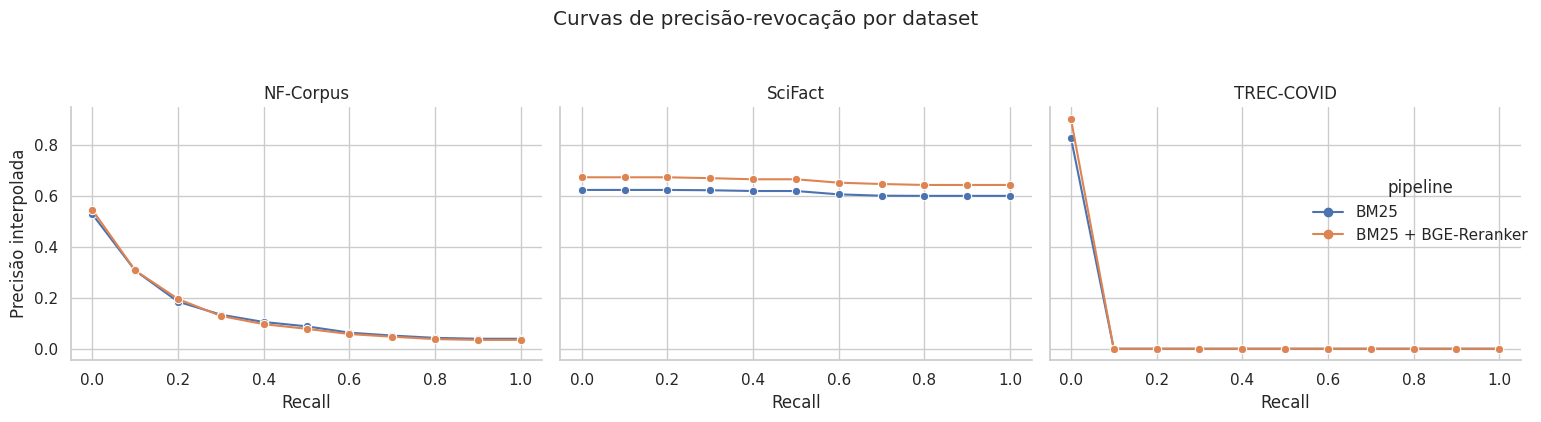

,dataset,pipeline,recall_level,precision
0,NF-Corpus,BM25,0.0,0.527416
1,NF-Corpus,BM25,0.1,0.306468
2,NF-Corpus,BM25,0.2,0.184594
3,NF-Corpus,BM25,0.3,0.133688
4,NF-Corpus,BM25,0.4,0.104934


In [27]:
def interpolated_precision_at_recall_levels(retrieved_doc_ids, relevant_docs, recall_levels=None):
    if recall_levels is None:
        recall_levels = np.linspace(0, 1, 11)
    relevant_ids = {str(doc_id) for doc_id, relevance in relevant_docs.items() if relevance > 0}
    if not relevant_ids:
        return {float(level): 0.0 for level in recall_levels}
    precisions = []
    recalls = []
    hits = 0
    for rank, doc_id in enumerate(retrieved_doc_ids, start=1):
        if str(doc_id) in relevant_ids:
            hits += 1
        precisions.append(hits / rank)
        recalls.append(hits / len(relevant_ids))
    return {
        float(level): max([p for p, r in zip(precisions, recalls) if r >= level], default=0.0)
        for level in recall_levels
    }


def build_precision_recall_curve_df(rankings_df, experiment_cache, recall_levels=None):
    if recall_levels is None:
        recall_levels = np.linspace(0, 1, 11)
    qrels_by_dataset = {case["config"]["name"]: case["qrels"] for case in experiment_cache.values()}
    rows = []
    if rankings_df.empty:
        return pd.DataFrame(rows)
    for (dataset, pipeline, query_id), group in rankings_df.groupby(["dataset", "pipeline", "query_id"], sort=False):
        group = group.sort_values("rank")
        retrieved_doc_ids = [str(doc_id) for doc_id in group["doc_id"].tolist()]
        relevant_docs = qrels_by_dataset[dataset].get(str(query_id), {})
        values = interpolated_precision_at_recall_levels(retrieved_doc_ids, relevant_docs, recall_levels)
        for recall_level, precision in values.items():
            rows.append({"dataset": dataset, "pipeline": pipeline, "query_id": str(query_id), "recall_level": recall_level, "precision": precision})
    return pd.DataFrame(rows)

combined_rankings_for_pr = rankings_all.copy()
if "dense_hybrid_rankings_all" in globals() and not dense_hybrid_rankings_all.empty:
    combined_rankings_for_pr = pd.concat([combined_rankings_for_pr, dense_hybrid_rankings_all], ignore_index=True)

precision_recall_per_query = build_precision_recall_curve_df(combined_rankings_for_pr, experiment_cache)
precision_recall_curves = precision_recall_per_query.groupby(["dataset", "pipeline", "recall_level"], as_index=False)["precision"].mean()
precision_recall_per_query.to_csv("precision_recall_per_query.csv", index=False)
precision_recall_curves.to_csv("precision_recall_curves.csv", index=False)

if not precision_recall_curves.empty:
    g = sns.relplot(data=precision_recall_curves, kind="line", x="recall_level", y="precision", hue="pipeline", col="dataset", marker="o", height=4, aspect=1.1)
    g.set_axis_labels("Recall", "Precisão interpolada")
    g.set_titles("{col_name}")
    g.figure.suptitle("Curvas de precisão-revocação por dataset", y=1.05)
    g.figure.tight_layout()
    g.figure.savefig("precision_recall_curves.png", dpi=160, bbox_inches="tight")
    plt.show()
    fig = px.line(precision_recall_curves, x="recall_level", y="precision", color="pipeline", facet_col="dataset", markers=True, title="Curvas de precisão-revocação por dataset")
    fig.write_html("precision_recall_curves.html")
    fig.show()

precision_recall_curves.head()


## Análise de trade-off do número de candidatos

In [28]:
bm25_top_n_sweep_results = []

if RUN_RERANKER and RUN_BM25_TOP_N_SWEEP:
    for slug, case in experiment_cache.items():
        config = case["config"]
        documents = case["documents"]
        queries = case["queries"]
        qrels = case["qrels"]
        bm25 = case["bm25"]
        doc_ids = case["doc_ids"]

        for candidate_n in BM25_TOP_N_VALUES:
            print("=" * 80)
            print(f"Dataset: {config['name']} | BM25_TOP_N={candidate_n}")

            sweep_df, _, _ = evaluate_retrieved(
                dataset_name=config["name"],
                pipeline_name=f"BM25 + BGE-Reranker | topN={candidate_n}",
                queries=queries,
                qrels=qrels,
                retrieve_fn=lambda query, candidate_n=candidate_n, bm25=bm25, doc_ids=doc_ids, documents=documents: retrieve_bm25_plus_reranker(
                    query=query,
                    bm25=bm25,
                    doc_ids=doc_ids,
                    documents=documents,
                    tokenizer=tokenizer,
                    model=reranker_model,
                    bm25_top_n=candidate_n,
                    final_top_k=max(EVAL_K_VALUES),
                ),
                documents=documents,
                top_k=max(EVAL_K_VALUES),
            )
            sweep_summary = summarize_results(sweep_df)
            sweep_summary["BM25_TOP_N"] = candidate_n
            bm25_top_n_sweep_results.append(sweep_summary)

    bm25_top_n_sweep = pd.concat(bm25_top_n_sweep_results, ignore_index=True)
    bm25_top_n_sweep.to_csv("bm25_top_n_sweep.csv", index=False)
    display(bm25_top_n_sweep)
else:
    bm25_top_n_sweep = pd.DataFrame()
    print("Sweep desativado. Para rodar, defina RUN_BM25_TOP_N_SWEEP=True no bloco de configuração.")


Sweep desativado. Para rodar, defina RUN_BM25_TOP_N_SWEEP=True no bloco de configuração.


In [29]:
if RUN_RERANKER and RUN_BM25_TOP_N_SWEEP and not bm25_top_n_sweep.empty:
    fig = px.line(
        bm25_top_n_sweep,
        x="BM25_TOP_N",
        y="nDCG@10",
        color="dataset",
        markers=True,
        hover_data=["MRR@10", "Recall@10", "MAP@10", "avg_time_sec"],
        title="Trade-off entre número de candidatos BM25 e nDCG@10 do reranker",
    )
    fig.write_html("bm25_top_n_sweep_ndcg.html")
    fig.show()

    fig = px.line(
        bm25_top_n_sweep,
        x="BM25_TOP_N",
        y="avg_time_sec",
        color="dataset",
        markers=True,
        hover_data=["nDCG@10", "MRR@10", "Recall@10", "MAP@10"],
        title="Custo médio por query ao variar BM25_TOP_N",
    )
    fig.write_html("bm25_top_n_sweep_time.html")
    fig.show()
else:
    print("Sem gráficos de sweep para exibir.")


Sem gráficos de sweep para exibir.


## Visualização 3D dos candidatos recuperados


### Escolha dos datasets e queries para visualização 3D


In [30]:
# Escolha quais datasets visualizar.
# Use None para gerar visualizações para todos os datasets em experiment_cache.
VIS_DATASET_SLUGS = ["scifact", "trec_covid", "nfcorpus"]

# Opcional: escolha uma query específica por dataset. None usa a primeira query disponível.
VIS_QUERY_IDS = {
    "scifact": None,
    "trec_covid": None,
    "nfcorpus": None,
}

# Use menos pontos para um 3D mais legível. A recuperação/reranking ainda pode usar mais candidatos.
VIS_NUM_CANDIDATES = 60
VIS_MAX_POINTS_3D = 35
VIS_TOP_RERANKED = 10
VIS_SHARED_TOP_N = 5
VIS_QUERY_LINK_TOP_N = 5
VIS_QRELS_LINK_TOP_N = 5
VIS_LABEL_TOP_N = 8
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=DEVICE)

vis_dataset_slugs = VIS_DATASET_SLUGS or list(experiment_cache.keys())
for slug in vis_dataset_slugs:
    case_preview = experiment_cache[slug]
    query_id_preview = VIS_QUERY_IDS.get(slug) or next(iter(case_preview["queries"].keys()))
    print("Dataset:", case_preview["config"]["name"])
    print("Query ID:", query_id_preview)
    print("Query:", case_preview["queries"][query_id_preview])
    print("-" * 80)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Dataset: SciFact
Query ID: 1
Query: 0-dimensional biomaterials show inductive properties.
--------------------------------------------------------------------------------
Dataset: TREC-COVID
Query ID: 1
Query: what is the origin of COVID-19
--------------------------------------------------------------------------------
Dataset: NF-Corpus
Query ID: PLAIN-2
Query: Do Cholesterol Statin Drugs Cause Breast Cancer?
--------------------------------------------------------------------------------


### Função para criar gráficos 3D por dataset


In [31]:
if not RUN_RERANKER:
    raise ValueError("Esta visualizacao precisa de RUN_RERANKER=True.")

color_map = {
    "Top 5 BM25 e BGE": "#d62728",
    "Relevante no qrels": "#2ca02c",
    "Top reranker": "#1f77b4",
    "Subiu": "#17becf",
    "Caiu": "#d62728",
    "Sem mudança": "#9e9e9e",
}

def make_query_link_trace(query_coord, row, trace_name, color, legendgroup, hover_title):
    line_style = dict(color=color, width=4, dash="dash")
    trace_kwargs = dict(
        x=[query_coord[0], row["x"]],
        y=[query_coord[1], row["y"]],
        z=[query_coord[2], row["z"]],
        mode="lines",
        line=line_style,
        opacity=0.78,
        name=trace_name,
        legendgroup=legendgroup,
        hovertemplate=(
            f"<b>{hover_title}</b><br>"
            f"Doc: {row['doc_id']}<br>"
            f"Rank BGE: {int(row['rerank_rank'])}<br>"
            f"Rank BM25: {int(row['bm25_rank'])}<br>"
            f"Relevancia qrels: {int(row['relevance'])}"
            "<extra></extra>"
        ),
    )
    try:
        return go.Scatter3d(**trace_kwargs)
    except ValueError:
        trace_kwargs["line"] = dict(color=color, width=4)
        return go.Scatter3d(**trace_kwargs)


def add_query_to_docs_lines(
    fig,
    query_coord,
    docs_df,
    trace_name,
    color,
    legendgroup,
    hover_title,
):
    for _, row in docs_df.iterrows():
        trace = make_query_link_trace(
            query_coord=query_coord,
            row=row,
            trace_name=trace_name,
            color=color,
            legendgroup=legendgroup,
            hover_title=hover_title,
        )
        trace.showlegend = not any(
            getattr(existing_trace, "legendgroup", None) == legendgroup
            for existing_trace in fig.data
        )
        fig.add_trace(trace)


def add_query_comparison_lines(fig, query_coord, vis_df):
    top_reranker_docs = vis_df.sort_values("rerank_rank").head(VIS_QUERY_LINK_TOP_N)
    top_qrels_docs = (
        vis_df[vis_df["relevance"] > 0]
        .sort_values(["relevance", "rerank_rank", "bm25_rank"], ascending=[False, True, True])
        .head(VIS_QRELS_LINK_TOP_N)
    )

    add_query_to_docs_lines(
        fig=fig,
        query_coord=query_coord,
        docs_df=top_reranker_docs,
        trace_name=f"Query -> top {VIS_QUERY_LINK_TOP_N} BGE",
        color="#111111",
        legendgroup="query_top_bge_links",
        hover_title="Query -> documento top BGE",
    )
    add_query_to_docs_lines(
        fig=fig,
        query_coord=query_coord,
        docs_df=top_qrels_docs,
        trace_name=f"Query -> top {VIS_QRELS_LINK_TOP_N} qrels",
        color="#2ca02c",
        legendgroup="query_top_qrels_links",
        hover_title="Query -> documento relevante no qrels",
    )

def format_query_metrics_html(query_metrics):
    if not query_metrics:
        return ""

    metric_specs = [
        ("nDCG@10", "bm25_ndcg", "reranker_ndcg", "delta_nDCG@10"),
        ("MRR@10", "bm25_mrr", "reranker_mrr", "delta_MRR@10"),
        ("Recall@10", "bm25_recall", "reranker_recall", "delta_Recall@10"),
        ("MAP@10", "bm25_map", "reranker_map", "delta_MAP@10"),
    ]
    parts = []
    for label, bm25_key, bge_key, delta_key in metric_specs:
        if bm25_key not in query_metrics or bge_key not in query_metrics:
            continue
        delta = query_metrics.get(
            delta_key,
            query_metrics[bge_key] - query_metrics[bm25_key],
        )
        parts.append(
            f"{label}: BM25={query_metrics[bm25_key]:.3f} | "
            f"BGE={query_metrics[bge_key]:.3f} | delta={delta:+.3f}"
        )
    return "<br><sup>" + " &nbsp; | &nbsp; ".join(parts) + "</sup>" if parts else ""

def build_3d_visualization_for_dataset(
    dataset_slug,
    query_id=None,
    output_suffix=None,
    show_figures=True,
    generate_overview=True,
    query_metrics=None,
):
    case = experiment_cache[dataset_slug]
    vis_queries = case["queries"]
    vis_query_id = query_id or next(iter(vis_queries.keys()))
    vis_query_text = vis_queries[vis_query_id]
    file_suffix = output_suffix or dataset_slug
    metrics_html = format_query_metrics_html(query_metrics)

    vis_bm25_candidates = retrieve_bm25(
        vis_query_text,
        case["bm25"],
        case["doc_ids"],
        top_k=VIS_NUM_CANDIDATES,
    )

    vis_reranked = rerank_documents(
        query=vis_query_text,
        bm25_results=vis_bm25_candidates,
        documents=case["documents"],
        tokenizer=tokenizer,
        model=reranker_model,
    )

    bm25_rank = {
        item["doc_id"]: rank
        for rank, item in enumerate(vis_bm25_candidates, start=1)
    }
    bm25_score = {item["doc_id"]: item["score"] for item in vis_bm25_candidates}
    rerank_rank = {
        item["doc_id"]: rank
        for rank, item in enumerate(vis_reranked, start=1)
    }
    rerank_score = {item["doc_id"]: item["score"] for item in vis_reranked}

    candidate_doc_ids = [item["doc_id"] for item in vis_bm25_candidates]
    candidate_texts = [case["documents"][doc_id] for doc_id in candidate_doc_ids]
    embedding_texts = [vis_query_text] + candidate_texts
    embeddings = embedding_model.encode(
        embedding_texts,
        batch_size=32,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    )

    coords = PCA(n_components=3, random_state=42).fit_transform(embeddings)
    query_coord = coords[0]
    doc_coords = coords[1:]

    qrels_for_query = case["qrels"].get(vis_query_id, {})
    vis_rows = []
    for doc_id, coord in zip(candidate_doc_ids, doc_coords):
        before_rank = bm25_rank[doc_id]
        after_rank = rerank_rank[doc_id]
        rank_gain = before_rank - after_rank
        relevance = qrels_for_query.get(doc_id, 0)
        text_preview = preview_text(case["documents"][doc_id], 240)

        if before_rank <= VIS_SHARED_TOP_N and after_rank <= VIS_SHARED_TOP_N:
            visual_group = "Top 5 BM25 e BGE"
        elif relevance > 0:
            visual_group = "Relevante no qrels"
        elif after_rank <= VIS_TOP_RERANKED:
            visual_group = "Top reranker"
        elif rank_gain > 0:
            visual_group = "Subiu"
        elif rank_gain < 0:
            visual_group = "Caiu"
        else:
            visual_group = "Sem mudança"

        vis_rows.append({
            "dataset": case["config"]["name"],
            "dataset_slug": dataset_slug,
            "query_id": vis_query_id,
            "query_text": vis_query_text,
            "doc_id": doc_id,
            "x": coord[0],
            "y": coord[1],
            "z": coord[2],
            "bm25_rank": before_rank,
            "rerank_rank": after_rank,
            "rank_gain": rank_gain,
            "bm25_score": bm25_score[doc_id],
            "reranker_score": rerank_score[doc_id],
            "relevance": relevance,
            "visual_group": visual_group,
            "preview": text_preview,
        })

    vis_df = pd.DataFrame(vis_rows)
    vis_df["abs_rank_gain"] = vis_df["rank_gain"].abs()
    vis_df["label"] = ""

    label_mask = (
        (vis_df["rerank_rank"] <= VIS_LABEL_TOP_N)
        | (vis_df["relevance"] > 0)
        | (vis_df["abs_rank_gain"].rank(method="first", ascending=False) <= VIS_LABEL_TOP_N)
    )
    vis_df.loc[label_mask, "label"] = vis_df.loc[label_mask, "doc_id"].astype(str)

    vis_plot_df = (
        vis_df.assign(
            priority=(vis_df["relevance"] > 0).astype(int) * 1000
            + (VIS_TOP_RERANKED + 1 - vis_df["rerank_rank"].clip(upper=VIS_TOP_RERANKED)).clip(lower=0) * 10
            + vis_df["abs_rank_gain"]
        )
        .sort_values("priority", ascending=False)
        .head(VIS_MAX_POINTS_3D)
        .sort_values("rerank_rank")
    )
    vis_plot_df["marker_size"] = 7 + vis_plot_df["abs_rank_gain"].clip(upper=20) * 0.7

    fig = px.scatter_3d(
        vis_plot_df,
        x="x",
        y="y",
        z="z",
        color="visual_group",
        color_discrete_map=color_map,
        size="marker_size",
        text="label",
        hover_name="doc_id",
        hover_data={
            "bm25_rank": True,
            "rerank_rank": True,
            "rank_gain": True,
            "bm25_score": ":.3f",
            "reranker_score": ":.3f",
            "relevance": True,
            "preview": True,
            "marker_size": False,
            "label": False,
            "x": False,
            "y": False,
            "z": False,
        },
        title=f"Candidatos em 3D - {case['config']['name']} | query {vis_query_id}{metrics_html}",
    )

    fig.add_trace(
        go.Scatter3d(
            x=[query_coord[0]],
            y=[query_coord[1]],
            z=[query_coord[2]],
            mode="markers+text",
            marker=dict(size=11, color="black", symbol="diamond"),
            text=["Query"],
            textposition="top center",
            name="Query",
            hovertemplate=f"<b>Query</b><br>{vis_query_text}<extra></extra>",
        )
    )


    add_query_comparison_lines(fig, query_coord, vis_df)

    fig.update_traces(
        textposition="top center",
        selector=dict(mode="markers+text"),
    )
    fig.update_layout(
        width=980,
        height=720,
        legend_title_text="Tipo de ponto",
        margin=dict(l=0, r=0, t=125 if metrics_html else 70, b=0),
        scene=dict(
            xaxis=dict(title="PCA 1", showbackground=False, showticklabels=False),
            yaxis=dict(title="PCA 2", showbackground=False, showticklabels=False),
            zaxis=dict(title="PCA 3", showbackground=False, showticklabels=False),
            camera=dict(eye=dict(x=1.6, y=1.6, z=1.1)),
        ),
    )

    candidates_html = None
    if generate_overview:
        candidates_html = f"ranking_candidates_3d_{file_suffix}.html"
        fig.write_html(candidates_html)
        if show_figures:
            fig.show()

    rank_change_df = vis_df.sort_values("rank_gain", ascending=False).copy()
    rank_change_df["direction"] = np.select(
        [
            rank_change_df["rank_gain"] > 0,
            rank_change_df["rank_gain"] < 0,
        ],
        ["Subiu", "Caiu"],
        default="Igual",
    )

    rank_change_focus = pd.concat([
        rank_change_df.sort_values("rank_gain", ascending=False).head(15),
        rank_change_df.sort_values("rank_gain", ascending=True).head(15),
    ], ignore_index=True).drop_duplicates("doc_id")

    fig_bar = px.bar(
        rank_change_focus.sort_values("rank_gain", ascending=False),
        x="doc_id",
        y="rank_gain",
        color="direction",
        color_discrete_map={"Subiu": "#17becf", "Caiu": "#d62728", "Igual": "#9e9e9e"},
        hover_data={
            "bm25_rank": True,
            "rerank_rank": True,
            "reranker_score": ":.3f",
            "relevance": True,
            "preview": True,
        },
        title=f"Maiores mudanças de posição - {case['config']['name']} | query {vis_query_id}{metrics_html}",
        labels={
            "doc_id": "Documento",
            "rank_gain": "Ganho de posição: rank BM25 - rank reranker",
        },
    )
    fig_bar.add_hline(y=0, line_width=1, line_color="black")
    fig_bar.update_layout(
        width=980,
        height=560 if metrics_html else 520,
        margin=dict(t=125 if metrics_html else 70),
        xaxis_tickangle=-45,
    )

    rank_changes_html = f"reranking_rank_changes_{file_suffix}.html"
    fig_bar.write_html(rank_changes_html)
    if show_figures:
        fig_bar.show()

    movement_df = vis_df[vis_df["rank_gain"] != 0].copy()
    movement_df = movement_df.sort_values("abs_rank_gain", ascending=False).head(VIS_MAX_POINTS_3D)
    movement_df["direction"] = np.where(movement_df["rank_gain"] > 0, "Subiu", "Caiu")
    movement_df["marker_size"] = 7 + movement_df["abs_rank_gain"].clip(upper=20) * 0.8
    movement_df["label"] = np.where(
        movement_df["abs_rank_gain"].rank(method="first", ascending=False) <= VIS_LABEL_TOP_N,
        movement_df["doc_id"].astype(str),
        "",
    )

    fig_move = px.scatter_3d(
        movement_df,
        x="x",
        y="y",
        z="z",
        color="direction",
        color_discrete_map={"Subiu": "#17becf", "Caiu": "#d62728"},
        size="marker_size",
        text="label",
        hover_name="doc_id",
        hover_data={
            "bm25_rank": True,
            "rerank_rank": True,
            "rank_gain": True,
            "relevance": True,
            "preview": True,
            "marker_size": False,
            "label": False,
            "x": False,
            "y": False,
            "z": False,
        },
        title=f"Movimento dos chunks em 3D - {case['config']['name']} | query {vis_query_id}{metrics_html}",
    )
    fig_move.add_trace(
        go.Scatter3d(
            x=[query_coord[0]],
            y=[query_coord[1]],
            z=[query_coord[2]],
            mode="markers+text",
            marker=dict(size=11, color="black", symbol="diamond"),
            text=["Query"],
            textposition="top center",
            name="Query",
            hovertemplate=f"<b>Query</b><br>{vis_query_text}<extra></extra>",
        )
    )

    add_query_comparison_lines(fig_move, query_coord, vis_df)

    fig_move.update_layout(
        width=980,
        height=720,
        legend_title_text="Movimento",
        margin=dict(l=0, r=0, t=125 if metrics_html else 70, b=0),
        scene=dict(
            xaxis=dict(title="PCA 1", showbackground=False, showticklabels=False),
            yaxis=dict(title="PCA 2", showbackground=False, showticklabels=False),
            zaxis=dict(title="PCA 3", showbackground=False, showticklabels=False),
            camera=dict(eye=dict(x=1.6, y=1.6, z=1.1)),
        ),
    )

    movement_html = f"reranking_movement_3d_{file_suffix}.html"
    fig_move.write_html(movement_html)
    if show_figures:
        fig_move.show()

    vis_df.to_csv(f"visualization_3d_points_{file_suffix}.csv", index=False)
    rank_change_df.to_csv(f"visualization_3d_rank_changes_{file_suffix}.csv", index=False)

    return {
        "dataset_slug": dataset_slug,
        "dataset": case["config"]["name"],
        "query_id": vis_query_id,
        "query_text": vis_query_text,
        "points_df": vis_df,
        "rank_change_df": rank_change_df,
        "files": {
            "candidates_3d": candidates_html,
            "rank_changes": rank_changes_html,
            "movement_3d": movement_html,
            "points_csv": f"visualization_3d_points_{file_suffix}.csv",
            "rank_changes_csv": f"visualization_3d_rank_changes_{file_suffix}.csv",
        },
    }


### Gerar visualizações 3D para todos os datasets escolhidos


In [32]:
visualization_3d_results = []

for dataset_slug in vis_dataset_slugs:
    print("=" * 80)
    print(f"Gerando visualizações 3D para: {dataset_slug}")
    result = build_3d_visualization_for_dataset(
        dataset_slug=dataset_slug,
        query_id=VIS_QUERY_IDS.get(dataset_slug),
        show_figures=True,
    )
    visualization_3d_results.append(result)
    print("Arquivos gerados:")
    for file_path in result["files"].values():
        print("-", file_path)

visualization_3d_summary = pd.DataFrame([
    {
        "dataset_slug": item["dataset_slug"],
        "dataset": item["dataset"],
        "query_id": item["query_id"],
        "query_text": item["query_text"],
        **item["files"],
    }
    for item in visualization_3d_results
])
visualization_3d_summary.to_csv("visualization_3d_summary.csv", index=False)
visualization_3d_summary


Gerando visualizações 3D para: scifact


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Arquivos gerados:
- ranking_candidates_3d_scifact.html
- reranking_rank_changes_scifact.html
- reranking_movement_3d_scifact.html
- visualization_3d_points_scifact.csv
- visualization_3d_rank_changes_scifact.csv
Gerando visualizações 3D para: trec_covid


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Arquivos gerados:
- ranking_candidates_3d_trec_covid.html
- reranking_rank_changes_trec_covid.html
- reranking_movement_3d_trec_covid.html
- visualization_3d_points_trec_covid.csv
- visualization_3d_rank_changes_trec_covid.csv
Gerando visualizações 3D para: nfcorpus


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Arquivos gerados:
- ranking_candidates_3d_nfcorpus.html
- reranking_rank_changes_nfcorpus.html
- reranking_movement_3d_nfcorpus.html
- visualization_3d_points_nfcorpus.csv
- visualization_3d_rank_changes_nfcorpus.csv


,dataset_slug,dataset,query_id,query_text,candidates_3d,rank_changes,movement_3d,points_csv,rank_changes_csv
0,scifact,SciFact,1,0-dimensional biomaterials show inductive prop...,ranking_candidates_3d_scifact.html,reranking_rank_changes_scifact.html,reranking_movement_3d_scifact.html,visualization_3d_points_scifact.csv,visualization_3d_rank_changes_scifact.csv
1,trec_covid,TREC-COVID,1,what is the origin of COVID-19,ranking_candidates_3d_trec_covid.html,reranking_rank_changes_trec_covid.html,reranking_movement_3d_trec_covid.html,visualization_3d_points_trec_covid.csv,visualization_3d_rank_changes_trec_covid.csv
2,nfcorpus,NF-Corpus,PLAIN-2,Do Cholesterol Statin Drugs Cause Breast Cancer?,ranking_candidates_3d_nfcorpus.html,reranking_rank_changes_nfcorpus.html,reranking_movement_3d_nfcorpus.html,visualization_3d_points_nfcorpus.csv,visualization_3d_rank_changes_nfcorpus.csv


### Visualizações 3D dos 3 melhores e 3 piores casos por dataset


In [33]:
def build_query_deltas(results_df):
    bm25_query = results_df[results_df["pipeline"] == "BM25"][[
        "dataset", "query_id", "ndcg", "mrr", "recall", "map"
    ]].rename(columns={
        "ndcg": "bm25_ndcg",
        "mrr": "bm25_mrr",
        "recall": "bm25_recall",
        "map": "bm25_map",
    })

    reranker_query = results_df[results_df["pipeline"] == "BM25 + BGE-Reranker"][[
        "dataset", "query_id", "ndcg", "mrr", "recall", "map"
    ]].rename(columns={
        "ndcg": "reranker_ndcg",
        "mrr": "reranker_mrr",
        "recall": "reranker_recall",
        "map": "reranker_map",
    })

    deltas = bm25_query.merge(reranker_query, on=["dataset", "query_id"])
    deltas["delta_nDCG@10"] = deltas["reranker_ndcg"] - deltas["bm25_ndcg"]
    deltas["delta_MRR@10"] = deltas["reranker_mrr"] - deltas["bm25_mrr"]
    deltas["delta_Recall@10"] = deltas["reranker_recall"] - deltas["bm25_recall"]
    deltas["delta_MAP@10"] = deltas["reranker_map"] - deltas["bm25_map"]
    return deltas

TOP_BOTTOM_3D_PER_DATASET = 3
GENERATE_TOP_BOTTOM_OVERVIEW = True
SHOW_TOP_BOTTOM_3D_FIGURES = False  # deixe True para exibir as visualizações no notebook

top_bottom_3d_results = []
top_bottom_cases = []

if RUN_RERANKER:
    required_metric_columns = {"bm25_map", "reranker_map", "delta_MAP@10"}
    if (
        "query_deltas" not in globals()
        or not required_metric_columns.issubset(query_deltas.columns)
    ):
        query_deltas = build_query_deltas(results_all)
        query_deltas.to_csv("query_level_metric_deltas.csv", index=False)

    slug_by_dataset = {
        case["config"]["name"]: slug
        for slug, case in experiment_cache.items()
    }

    for dataset, dataset_deltas in query_deltas.groupby("dataset", sort=False):
        dataset_slug = slug_by_dataset[dataset]

        best_cases = (
            dataset_deltas
            .sort_values("delta_nDCG@10", ascending=False)
            .head(TOP_BOTTOM_3D_PER_DATASET)
            .assign(case_type="melhorou")
        )
        worst_cases = (
            dataset_deltas
            .sort_values("delta_nDCG@10", ascending=True)
            .head(TOP_BOTTOM_3D_PER_DATASET)
            .assign(case_type="piorou")
        )

        selected_cases = pd.concat([best_cases, worst_cases], ignore_index=True)

        for _, row in selected_cases.iterrows():
            safe_query_id = re.sub(r"[^A-Za-z0-9_-]+", "_", str(row["query_id"]))
            suffix = f"{dataset_slug}_{row['case_type']}_{safe_query_id}"

            print("=" * 80)
            print(f"Dataset: {dataset} | caso: {row['case_type']} | query: {row['query_id']}")
            print(f"delta_nDCG@10: {row['delta_nDCG@10']:.4f}")
            overview_html = f"ranking_candidates_3d_{suffix}.html"
            if GENERATE_TOP_BOTTOM_OVERVIEW:
                print(f"Visão geral: {overview_html}")

            result = build_3d_visualization_for_dataset(
                dataset_slug=dataset_slug,
                query_id=str(row["query_id"]),
                output_suffix=suffix,
                show_figures=SHOW_TOP_BOTTOM_3D_FIGURES,
                generate_overview=GENERATE_TOP_BOTTOM_OVERVIEW,
                query_metrics=row.to_dict(),
            )

            result_summary = {
                "dataset": dataset,
                "dataset_slug": dataset_slug,
                "case_type": row["case_type"],
                "query_id": str(row["query_id"]),
                "delta_nDCG@10": row["delta_nDCG@10"],
                "delta_MRR@10": row["delta_MRR@10"],
                "delta_Recall@10": row["delta_Recall@10"],
                "bm25_nDCG@10": row["bm25_ndcg"],
                "reranker_nDCG@10": row["reranker_ndcg"],
                "bm25_MRR@10": row["bm25_mrr"],
                "reranker_MRR@10": row["reranker_mrr"],
                "bm25_Recall@10": row["bm25_recall"],
                "reranker_Recall@10": row["reranker_recall"],
                "bm25_MAP@10": row["bm25_map"],
                "reranker_MAP@10": row["reranker_map"],
                "delta_MAP@10": row["delta_MAP@10"],
                "query_text": result["query_text"],
                "overview_3d": result["files"]["candidates_3d"] if GENERATE_TOP_BOTTOM_OVERVIEW else None,
                **result["files"],
            }
            top_bottom_3d_results.append(result_summary)
            top_bottom_cases.append(result)

    top_bottom_3d_summary = pd.DataFrame(top_bottom_3d_results)
    top_bottom_3d_summary.to_csv("visualization_3d_top3_best_worst_summary.csv", index=False)

    with open("visualization_3d_top3_best_worst_summary.json", "w", encoding="utf-8") as f:
        json.dump(
            top_bottom_3d_summary.astype(object).where(pd.notna(top_bottom_3d_summary), None).to_dict(orient="records"),
            f,
            ensure_ascii=False,
            indent=2,
            allow_nan=False,
        )

    display(top_bottom_3d_summary)
else:
    top_bottom_3d_summary = pd.DataFrame()
    print("RUN_RERANKER=False; visualizações 3D de melhores/piores casos indisponíveis.")


Dataset: SciFact | caso: melhorou | query: 1382
delta_nDCG@10: 1.0000
Visão geral: ranking_candidates_3d_scifact_melhorou_1382.html


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Dataset: SciFact | caso: melhorou | query: 1140
delta_nDCG@10: 1.0000
Visão geral: ranking_candidates_3d_scifact_melhorou_1140.html


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Dataset: SciFact | caso: melhorou | query: 575
delta_nDCG@10: 1.0000
Visão geral: ranking_candidates_3d_scifact_melhorou_575.html


...

Dataset: NF-Corpus | caso: piorou | query: PLAIN-3342
delta_nDCG@10: -0.4800
Visão geral: ranking_candidates_3d_nfcorpus_piorou_PLAIN-3342.html


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Dataset: NF-Corpus | caso: piorou | query: PLAIN-2490
delta_nDCG@10: -0.4544
Visão geral: ranking_candidates_3d_nfcorpus_piorou_PLAIN-2490.html


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

,dataset,dataset_slug,case_type,query_id,delta_nDCG@10,delta_MRR@10,delta_Recall@10,bm25_nDCG@10,reranker_nDCG@10,bm25_MRR@10,...,bm25_MAP@10,reranker_MAP@10,delta_MAP@10,query_text,overview_3d,candidates_3d,rank_changes,movement_3d,points_csv,rank_changes_csv
0,SciFact,scifact,melhorou,1382,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,1.000000,1.000000,aPKCz causes tumour enhancement by affecting g...,ranking_candidates_3d_scifact_melhorou_1382.html,ranking_candidates_3d_scifact_melhorou_1382.html,reranking_rank_changes_scifact_melhorou_1382.html,reranking_movement_3d_scifact_melhorou_1382.html,visualization_3d_points_scifact_melhorou_1382.csv,visualization_3d_rank_changes_scifact_melhorou...
1,SciFact,scifact,melhorou,1140,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,1.000000,1.000000,Taking 400mg of α-tocopheryl acetate helps to ...,ranking_candidates_3d_scifact_melhorou_1140.html,ranking_candidates_3d_scifact_melhorou_1140.html,reranking_rank_changes_scifact_melhorou_1140.html,reranking_movement_3d_scifact_melhorou_1140.html,visualization_3d_points_scifact_melhorou_1140.csv,visualization_3d_rank_changes_scifact_melhorou...
2,SciFact,scifact,melhorou,575,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,1.000000,1.000000,In domesticated populations of Saccharomyces c...,ranking_candidates_3d_scifact_melhorou_575.html,ranking_candidates_3d_scifact_melhorou_575.html,reranking_rank_changes_scifact_melhorou_575.html,reranking_movement_3d_scifact_melhorou_575.html,visualization_3d_points_scifact_melhorou_575.csv,visualization_3d_rank_changes_scifact_melhorou...
3,SciFact,scifact,piorou,513,-1.000000,-1.000000,-1.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,-1.000000,High cardiopulmonary fitness causes increased ...,ranking_candidates_3d_scifact_piorou_513.html,ranking_candidates_3d_scifact_piorou_513.html,reranking_rank_changes_scifact_piorou_513.html,reranking_movement_3d_scifact_piorou_513.html,visualization_3d_points_scifact_piorou_513.csv,visualization_3d_rank_changes_scifact_piorou_5...
4,SciFact,scifact,piorou,294,-1.000000,-1.000000,-1.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,-1.000000,Crossover hot spots are not found within gene ...,ranking_candidates_3d_scifact_piorou_294.html,ranking_candidates_3d_scifact_piorou_294.html,reranking_rank_changes_scifact_piorou_294.html,reranking_movement_3d_scifact_piorou_294.html,visualization_3d_points_scifact_piorou_294.csv,visualization_3d_rank_changes_scifact_piorou_2...
5,SciFact,scifact,piorou,1303,-0.666667,-0.857143,0.000000,1.000000,0.333333,1.000000,...,1.000000,0.142857,-0.857143,Tirasemtiv has no effect on fast-twitch muscle.,ranking_candidates_3d_scifact_piorou_1303.html,ranking_candidates_3d_scifact_piorou_1303.html,reranking_rank_changes_scifact_piorou_1303.html,reranking_movement_3d_scifact_piorou_1303.html,visualization_3d_points_scifact_piorou_1303.csv,visualization_3d_rank_changes_scifact_piorou_1...
6,TREC-COVID,trec_covid,melhorou,47,0.579642,0.833333,0.011905,0.184889,0.764531,0.166667,...,0.078571,0.788889,0.710317,what are the health outcomes for children who ...,ranking_candidates_3d_trec_covid_melhorou_47.html,ranking_candidates_3d_trec_covid_melhorou_47.html,reranking_rank_changes_trec_covid_melhorou_47....,reranking_movement_3d_trec_covid_melhorou_47.html,visualization_3d_points_trec_covid_melhorou_47...,visualization_3d_rank_changes_trec_covid_melho...
7,TREC-COVID,trec_covid,melhorou,11,0.469000,1.000000,0.007229,0.000000,0.469000,0.000000,...,0.000000,0.300000,0.300000,what are the guidelines for triaging patients ...,ranking_candidates_3d_trec_covid_melhorou_11.html,ranking_candidates_3d_trec_covid_melhorou_11.html,reranking_rank_changes_trec_covid_melhorou_11....,reranking_movement_3d_trec_covid_melhorou_11.html,visualization_3d_points_trec_covid_melhorou_11...,visualization_3d_rank_changes_trec_covid_melho...
8,TREC-COVID,trec_covid,melhorou,37,0.439942,0.500000,0.01

## Gráficos de comparação


### Gráfico das métricas médias


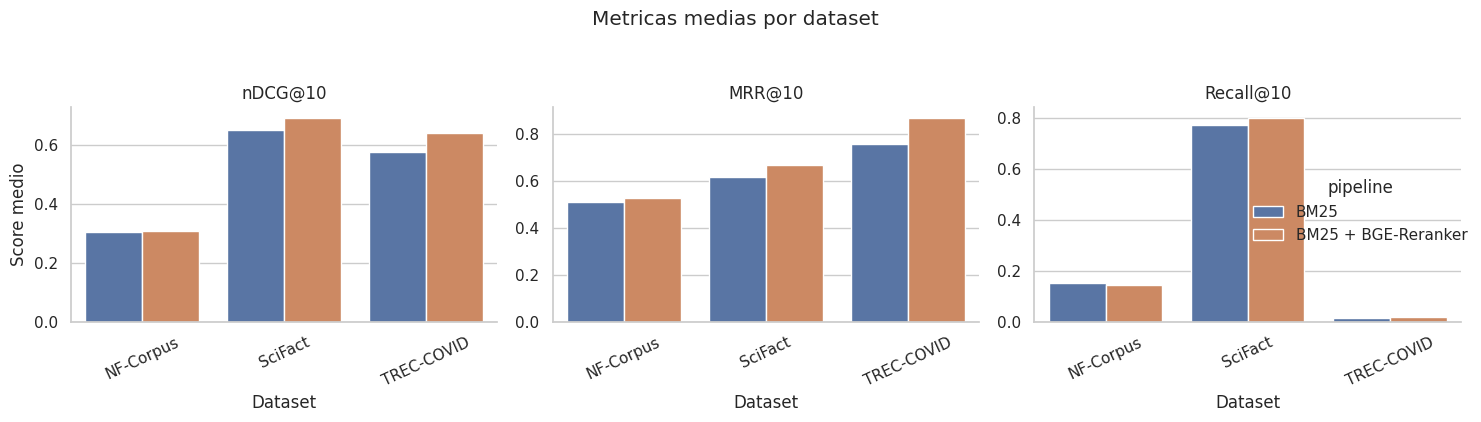

In [34]:
metrics_long = summary.melt(
    id_vars=["dataset", "pipeline", "num_queries"],
    value_vars=["nDCG@10", "MRR@10", "Recall@10"],
    var_name="metric",
    value_name="score",
)

g = sns.catplot(
    data=metrics_long,
    kind="bar",
    x="dataset",
    y="score",
    hue="pipeline",
    col="metric",
    sharey=False,
    height=4,
    aspect=1.05,
)
g.set_axis_labels("Dataset", "Score medio")
g.set_titles("{col_name}")
g.set_xticklabels(rotation=25)
g.figure.suptitle("Metricas medias por dataset", y=1.05)
g.figure.tight_layout()
g.figure.savefig("metrics_mean_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

### Ganho médio do reranker

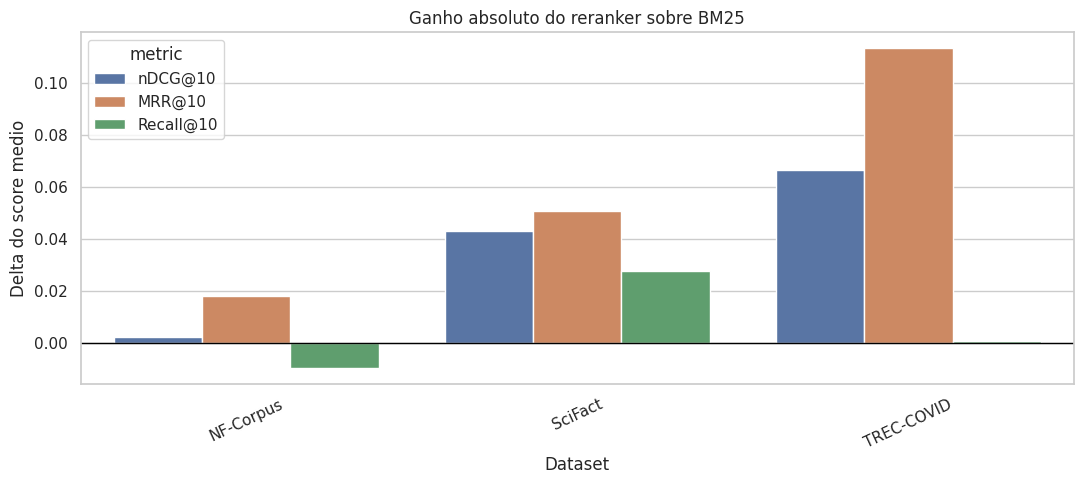

In [35]:
if RUN_RERANKER:
    improvement_rows = []
    for dataset in summary["dataset"].unique():
        dataset_summary = summary[summary["dataset"] == dataset].set_index("pipeline")
        for metric in ["nDCG@10", "MRR@10", "Recall@10"]:
            bm25_score = dataset_summary.loc["BM25", metric]
            reranker_score = dataset_summary.loc["BM25 + BGE-Reranker", metric]
            delta_abs = reranker_score - bm25_score
            delta_pct = np.nan if bm25_score == 0 else 100 * delta_abs / bm25_score
            improvement_rows.append({
                "dataset": dataset,
                "metric": metric,
                "BM25": bm25_score,
                "BM25 + BGE-Reranker": reranker_score,
                "delta_abs": delta_abs,
                "delta_pct": delta_pct,
            })

    improvements = pd.DataFrame(improvement_rows)
    improvements.to_csv("metric_improvements.csv", index=False)

    plt.figure(figsize=(11, 5))
    ax = sns.barplot(
        data=improvements,
        x="dataset",
        y="delta_abs",
        hue="metric",
    )
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("Ganho absoluto do reranker sobre BM25")
    ax.set_xlabel("Dataset")
    ax.set_ylabel("Delta do score medio")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.savefig("metric_improvements_delta.png", dpi=160, bbox_inches="tight")
    plt.show()

    improvements
else:
    print("RUN_RERANKER=False; sem grafico de melhoria pos-rerankeamento.")

### Distribuição do ganho por query


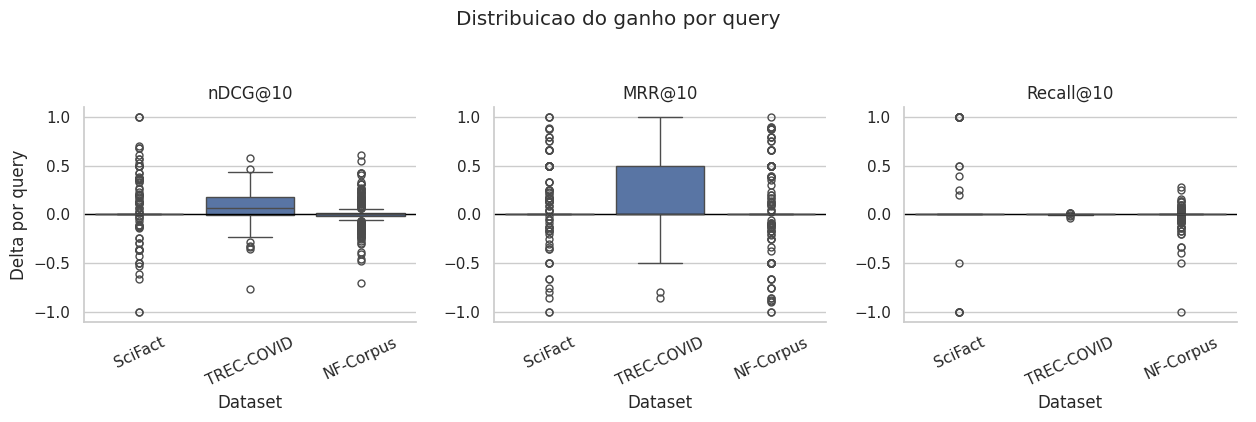

In [36]:
if RUN_RERANKER:
    if "build_query_deltas" not in globals():
        def build_query_deltas(results_df):
            bm25_query = results_df[results_df["pipeline"] == "BM25"][[
                "dataset", "query_id", "ndcg", "mrr", "recall"
            ]].rename(columns={
                "ndcg": "bm25_ndcg",
                "mrr": "bm25_mrr",
                "recall": "bm25_recall",
            })
            reranker_query = results_df[results_df["pipeline"] == "BM25 + BGE-Reranker"][[
                "dataset", "query_id", "ndcg", "mrr", "recall"
            ]].rename(columns={
                "ndcg": "reranker_ndcg",
                "mrr": "reranker_mrr",
                "recall": "reranker_recall",
            })
            deltas = bm25_query.merge(reranker_query, on=["dataset", "query_id"])
            deltas["delta_nDCG@10"] = deltas["reranker_ndcg"] - deltas["bm25_ndcg"]
            deltas["delta_MRR@10"] = deltas["reranker_mrr"] - deltas["bm25_mrr"]
            deltas["delta_Recall@10"] = deltas["reranker_recall"] - deltas["bm25_recall"]
            return deltas

    query_deltas = build_query_deltas(results_all)
    query_deltas.to_csv("query_level_metric_deltas.csv", index=False)

    query_deltas_long = query_deltas.melt(
        id_vars=["dataset", "query_id"],
        value_vars=["delta_nDCG@10", "delta_MRR@10", "delta_Recall@10"],
        var_name="metric",
        value_name="delta",
    )
    query_deltas_long["metric"] = query_deltas_long["metric"].str.replace("delta_", "", regex=False)

    g = sns.catplot(
        data=query_deltas_long,
        kind="box",
        x="dataset",
        y="delta",
        col="metric",
        sharey=False,
        height=4,
        aspect=1.05,
    )
    for ax in g.axes.flat:
        ax.axhline(0, color="black", linewidth=1)
        ax.tick_params(axis="x", rotation=25)
    g.set_axis_labels("Dataset", "Delta por query")
    g.set_titles("{col_name}")
    g.figure.suptitle("Distribuicao do ganho por query", y=1.05)
    g.figure.tight_layout()
    g.figure.savefig("query_level_delta_distribution.png", dpi=160, bbox_inches="tight")
    plt.show()

    query_deltas_long.head()
else:
    print("RUN_RERANKER=False; sem distribuicao por query.")


## Análise qualitativa separada por dataset


In [37]:
if RUN_RERANKER:
    def dataframe_to_json_records(df):
        clean_df = df.astype(object).where(pd.notna(df), None)
        return clean_df.to_dict(orient="records")

    query_text_rows = []
    for slug, case in experiment_cache.items():
        for query_id, query_text in case["queries"].items():
            query_text_rows.append({
                "dataset": case["config"]["name"],
                "dataset_slug": slug,
                "query_id": query_id,
                "query": query_text,
            })
    query_text_df = pd.DataFrame(query_text_rows)

    qualitative_queries = query_deltas.merge(
        query_text_df,
        on=["dataset", "query_id"],
        how="left",
    )

    qualitative_queries["interpretacao"] = np.select(
        [
            qualitative_queries["delta_nDCG@10"] > 0,
            qualitative_queries["delta_nDCG@10"] < 0,
        ],
        [
            "reranker melhorou o ranking da query no topo",
            "reranker piorou o ranking da query no topo",
        ],
        default="sem mudança em nDCG@10",
    )

    qualitative_query_json_files = []
    best_queries_by_dataset = []
    worst_queries_by_dataset = []

    for dataset, dataset_queries in qualitative_queries.groupby("dataset", sort=False):
        dataset_slug = dataset_queries["dataset_slug"].iloc[0]
        dataset_queries = dataset_queries.sort_values("delta_nDCG@10", ascending=False)

        best_dataset_queries = dataset_queries.head(10).copy()
        worst_dataset_queries = dataset_queries.tail(10).sort_values("delta_nDCG@10", ascending=True).copy()

        best_queries_by_dataset.append(best_dataset_queries)
        worst_queries_by_dataset.append(worst_dataset_queries)

        query_analysis_payload = {
            "dataset": dataset,
            "dataset_slug": dataset_slug,
            "metric_used_for_sorting": "delta_nDCG@10",
            "most_improved_queries": dataframe_to_json_records(best_dataset_queries),
            "most_worsened_queries": dataframe_to_json_records(worst_dataset_queries),
            "all_query_deltas": dataframe_to_json_records(dataset_queries),
        }

        json_path = f"qualitative_query_analysis_{dataset_slug}.json"
        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(query_analysis_payload, f, ensure_ascii=False, indent=2, allow_nan=False)
        qualitative_query_json_files.append(json_path)

        dataset_queries.to_csv(f"qualitative_query_deltas_{dataset_slug}.csv", index=False)

    best_queries = pd.concat(best_queries_by_dataset, ignore_index=True)
    worst_queries = pd.concat(worst_queries_by_dataset, ignore_index=True)

    best_queries.to_csv("queries_most_improved_by_dataset.csv", index=False)
    worst_queries.to_csv("queries_most_worsened_by_dataset.csv", index=False)

    print("Arquivos JSON de análise por query salvos:")
    for file_name in qualitative_query_json_files:
        print("-", file_name)

    print("Top queries que mais melhoraram por dataset:")
    display(best_queries[["dataset", "query_id", "query", "bm25_ndcg", "reranker_ndcg", "delta_nDCG@10", "interpretacao"]])

    print("Top queries que mais pioraram por dataset:")
    display(worst_queries[["dataset", "query_id", "query", "bm25_ndcg", "reranker_ndcg", "delta_nDCG@10", "interpretacao"]])
else:
    qualitative_query_json_files = []
    print("RUN_RERANKER=False; análise qualitativa por query indisponível.")


Arquivos JSON de análise por query salvos:
- qualitative_query_analysis_scifact.json
- qualitative_query_analysis_trec_covid.json
- qualitative_query_analysis_nfcorpus.json
Top queries que mais melhoraram por dataset:


,dataset,query_id,query,bm25_ndcg,reranker_ndcg,delta_nDCG@10,interpretacao
0,SciFact,1382,aPKCz causes tumour enhancement by affecting g...,0.000000,1.000000,1.000000,reranker melhorou o ranking da query no topo
1,SciFact,1140,Taking 400mg of α-tocopheryl acetate helps to ...,0.000000,1.000000,1.000000,reranker melhorou o ranking da query no topo
2,SciFact,575,In domesticated populations of Saccharomyces c...,0.000000,1.000000,1.000000,reranker melhorou o ranking da query no topo
3,SciFact,72,Activator-inhibitor pairs are provided dorsall...,0.301030,1.000000,0.698970,reranker melhorou o ranking da query no topo
4,SciFact,1245,The one-child policy has been successful in lo...,0.315465,1.000000,0.684535,reranker melhorou o ranking da query no topo
5,SciFact,1194,The arm density of TatAd complexes is due to s...,0.315465,1.000000,0.684535,reranker melhorou o ranking da query no topo
6,SciFact,660,Ivermectin is used to treat onchocerciasis.,0.386853,1.000000,0.613147,reranker melhorou o ranking da query no topo
7,SciFact,1207,The composition of myosin-II isoform switches ...,0.430677,1.000000,0.569323,reranker melhorou o ranking da query no topo
8,SciFact,784,MicroRNA is involved in the regulation of Neur...,0.430677,1.000000,0.569323,reranker melhorou o ranking da query no topo
9,SciFact,1379,Women with a higher birth weight are more like...,0.334246,0.866543,0.532297,reranker melhorou o ranking da query no topo


Top queries que mais pioraram por dataset:


,dataset,query_id,query,bm25_ndcg,reranker_ndcg,delta_nDCG@10,interpretacao
0,SciFact,294,Crossover hot spots are not found within gene ...,1.000000,0.000000,-1.000000,reranker piorou o ranking da query no topo
1,SciFact,513,High cardiopulmonary fitness causes increased ...,1.000000,0.000000,-1.000000,reranker piorou o ranking da query no topo
2,SciFact,1303,Tirasemtiv has no effect on fast-twitch muscle.,1.000000,0.333333,-0.666667,reranker piorou o ranking da query no topo
3,SciFact,521,High-sensitivity cardiac troponin T (HSCT-T) d...,1.000000,0.386853,-0.613147,reranker piorou o ranking da query no topo
4,SciFact,70,Activation of PPM1D suppresses p53 function.,1.000000,0.468451,-0.531549,reranker piorou o ranking da query no topo
5,SciFact,507,Helminths interfere with immune system control...,1.000000,0.500000,-0.500000,reranker piorou o ranking da query no topo
6,SciFact,1204,The combination of H3K4me3 and H3K79me2 is fou...,1.000000,0.500000,-0.500000,reranker piorou o ranking da query no topo
7,SciFact,388,Ethanol stress decreases the expression of IBP...,0.500000,0.000000,-0.500000,reranker piorou o ranking da query no topo
8,SciFact,551,ITAM phosphorylation prevents the transfer of ...,0.430677,0.000000,-0.430677,reranker piorou o ranking da query no topo
9,SciFact,1320,Transplanted human glial progenitor cells are ...,1.000000,0.630930,-0.369070,reranker piorou o ranking da query no topo


In [38]:
if RUN_RERANKER:
    if "dataframe_to_json_records" not in globals():
        def dataframe_to_json_records(df):
            clean_df = df.astype(object).where(pd.notna(df), None)
            return clean_df.to_dict(orient="records")

    bm25_chunks = rankings_all[rankings_all["pipeline"] == "BM25"][[
        "dataset", "query_id", "query_text", "doc_id", "rank", "score", "relevance", "doc_preview", "doc_text"
    ]].rename(columns={
        "rank": "bm25_rank",
        "score": "bm25_score",
        "doc_preview": "bm25_doc_preview",
        "doc_text": "bm25_doc_text",
    })

    reranker_chunks = rankings_all[rankings_all["pipeline"] == "BM25 + BGE-Reranker"][[
        "dataset", "query_id", "query_text", "doc_id", "rank", "score", "relevance", "doc_preview", "doc_text"
    ]].rename(columns={
        "rank": "reranker_rank",
        "score": "reranker_score",
        "doc_preview": "reranker_doc_preview",
        "doc_text": "reranker_doc_text",
    })

    chunk_rank_changes = bm25_chunks.merge(
        reranker_chunks,
        on=["dataset", "query_id", "doc_id"],
        how="outer",
        suffixes=("_bm25", "_reranker"),
    )

    max_saved_rank = max(EVAL_K_VALUES)
    missing_rank = max_saved_rank + 1

    chunk_rank_changes["query_text"] = chunk_rank_changes["query_text_bm25"].combine_first(
        chunk_rank_changes["query_text_reranker"]
    )
    chunk_rank_changes["relevance"] = chunk_rank_changes["relevance_bm25"].combine_first(
        chunk_rank_changes["relevance_reranker"]
    ).fillna(0).astype(int)
    chunk_rank_changes["doc_preview"] = chunk_rank_changes["bm25_doc_preview"].combine_first(
        chunk_rank_changes["reranker_doc_preview"]
    )
    chunk_rank_changes["doc_text"] = chunk_rank_changes["bm25_doc_text"].combine_first(
        chunk_rank_changes["reranker_doc_text"]
    )

    chunk_rank_changes["bm25_rank_filled"] = chunk_rank_changes["bm25_rank"].fillna(missing_rank)
    chunk_rank_changes["reranker_rank_filled"] = chunk_rank_changes["reranker_rank"].fillna(missing_rank)
    chunk_rank_changes["rank_delta"] = chunk_rank_changes["bm25_rank_filled"] - chunk_rank_changes["reranker_rank_filled"]

    chunk_rank_changes["movement"] = np.select(
        [
            chunk_rank_changes["rank_delta"] > 0,
            chunk_rank_changes["rank_delta"] < 0,
        ],
        ["melhorou", "piorou"],
        default="igual",
    )

    chunk_rank_changes["appeared_only_after_reranker"] = chunk_rank_changes["bm25_rank"].isna()
    chunk_rank_changes["dropped_after_reranker"] = chunk_rank_changes["reranker_rank"].isna()

    chunk_rank_changes = chunk_rank_changes[[
        "dataset", "query_id", "query_text", "doc_id", "relevance",
        "bm25_rank", "reranker_rank", "rank_delta", "movement",
        "bm25_score", "reranker_score", "appeared_only_after_reranker",
        "dropped_after_reranker", "doc_preview", "doc_text",
    ]].sort_values(["dataset", "query_id", "rank_delta"], ascending=[True, True, False])

    qualitative_chunk_json_files = []
    qualitative_combined_json_files = []
    chunk_analysis_by_dataset = {}

    slug_by_dataset = {
        case["config"]["name"]: slug
        for slug, case in experiment_cache.items()
    }

    for dataset, dataset_chunks in chunk_rank_changes.groupby("dataset", sort=False):
        dataset_slug = slug_by_dataset.get(dataset, dataset.lower().replace(" ", "_"))

        improved_chunks = dataset_chunks[dataset_chunks["rank_delta"] > 0].sort_values(
            "rank_delta", ascending=False
        )
        worsened_chunks = dataset_chunks[dataset_chunks["rank_delta"] < 0].sort_values(
            "rank_delta", ascending=True
        )
        unchanged_chunks = dataset_chunks[dataset_chunks["rank_delta"] == 0]

        chunk_payload = {
            "dataset": dataset,
            "dataset_slug": dataset_slug,
            "rank_delta_definition": "bm25_rank - reranker_rank; positivo = chunk subiu após rerankeamento; negativo = chunk caiu",
            "max_saved_rank": max_saved_rank,
            "num_chunks_analyzed": int(len(dataset_chunks)),
            "num_chunks_improved": int(len(improved_chunks)),
            "num_chunks_worsened": int(len(worsened_chunks)),
            "num_chunks_unchanged": int(len(unchanged_chunks)),
            "improved_chunks": dataframe_to_json_records(improved_chunks),
            "worsened_chunks": dataframe_to_json_records(worsened_chunks),
            "unchanged_chunks": dataframe_to_json_records(unchanged_chunks),
        }

        chunk_json_path = f"qualitative_chunk_analysis_{dataset_slug}.json"
        with open(chunk_json_path, "w", encoding="utf-8") as f:
            json.dump(chunk_payload, f, ensure_ascii=False, indent=2, allow_nan=False)
        qualitative_chunk_json_files.append(chunk_json_path)

        dataset_chunks.to_csv(f"qualitative_chunk_rank_changes_{dataset_slug}.csv", index=False)

        query_payload_path = f"qualitative_query_analysis_{dataset_slug}.json"
        if os.path.exists(query_payload_path):
            with open(query_payload_path, "r", encoding="utf-8") as f:
                query_payload = json.load(f)
        else:
            query_payload = {}

        combined_payload = {
            "dataset": dataset,
            "dataset_slug": dataset_slug,
            "query_level_analysis": query_payload,
            "chunk_level_analysis": chunk_payload,
        }
        combined_json_path = f"qualitative_reranking_analysis_{dataset_slug}.json"
        with open(combined_json_path, "w", encoding="utf-8") as f:
            json.dump(combined_payload, f, ensure_ascii=False, indent=2, allow_nan=False)
        qualitative_combined_json_files.append(combined_json_path)

        chunk_analysis_by_dataset[dataset] = {
            "improved": improved_chunks,
            "worsened": worsened_chunks,
            "unchanged": unchanged_chunks,
        }

    chunk_rank_changes.to_csv("qualitative_chunk_rank_changes_all_datasets.csv", index=False)

    print("Arquivos JSON de análise de chunks salvos:")
    for file_name in qualitative_chunk_json_files:
        print("-", file_name)

    print("Arquivos JSON consolidados por dataset salvos:")
    for file_name in qualitative_combined_json_files:
        print("-", file_name)

    for dataset, movement_groups in chunk_analysis_by_dataset.items():
        print("=" * 80)
        print(f"Dataset: {dataset}")
        print("Chunks individuais que mais melhoraram:")
        display(movement_groups["improved"][[
            "query_id", "query_text", "doc_id", "relevance", "bm25_rank",
            "reranker_rank", "rank_delta", "bm25_score", "reranker_score", "doc_preview"
        ]].head(10))

        print("Chunks individuais que mais pioraram:")
        display(movement_groups["worsened"][[
            "query_id", "query_text", "doc_id", "relevance", "bm25_rank",
            "reranker_rank", "rank_delta", "bm25_score", "reranker_score", "doc_preview"
        ]].head(10))
else:
    qualitative_chunk_json_files = []
    qualitative_combined_json_files = []
    chunk_rank_changes = pd.DataFrame()
    print("RUN_RERANKER=False; análise qualitativa de chunks indisponível.")


Arquivos JSON de análise de chunks salvos:
- qualitative_chunk_analysis_nfcorpus.json
- qualitative_chunk_analysis_scifact.json
- qualitative_chunk_analysis_trec_covid.json
Arquivos JSON consolidados por dataset salvos:
- qualitative_reranking_analysis_nfcorpus.json
- qualitative_reranking_analysis_scifact.json
- qualitative_reranking_analysis_trec_covid.json
Dataset: NF-Corpus
Chunks individuais que mais melhoraram:


,query_id,query_text,doc_id,relevance,bm25_rank,reranker_rank,rank_delta,bm25_score,reranker_score,doc_preview
1,PLAIN-1008,deafness,MED-5288,0,NaN,1.0,20.0,NaN,-5.290643,Background music genre can modulate flavor ple...
5394,PLAIN-2620,Phytates for the Treatment of Cancer,MED-2208,0,NaN,1.0,20.0,NaN,2.553350,Therapeutic efficacy of once-daily oral admini...
278,PLAIN-1098,eggnog,MED-751,0,NaN,1.0,20.0,NaN,-7.567631,Dietary Fat and Cholesterol and Risk of Cardio...
6587,PLAIN-2970,Preventing Cataracts with Diet,MED-1383,0,NaN,1.0,20.0,NaN,0.240808,Mediterranean diet and non enzymatic antioxida...
5333,PLAIN-2600,Eggs and Arterial Function,MED-2372,2,NaN,1.0,20.0,NaN,0.187115,Egg consumption and endothelial function: a ra...
5314,PLAIN-2590,Do Vegetarians Get Enough Protein?,MED-5004,0,NaN,1.0,20.0,NaN,-1.452842,"Weight gain over 5 years in 21,966 meat-eating..."
7837,PLAIN-3352,Boosting Heart Nerve Control,MED-3424,1,NaN,1.0,20.0,NaN,-1.619680,Subclinical endothelial dysfunction and low-gr...
6429,PLAIN-2920,Human Neurotransmitters in Plants,MED-1352,0,NaN,1.0,20.0,NaN,0.406077,Primum Non Nocere: An Evolutionary Analysis of...
6406,PLAIN-2910,Optimal Phytosterol Dose,MED-2249,0,NaN,1.0,20.0,NaN,0.117119,Zinc and multi-mineral supplementation should ...
4877,PLAIN-248,Treating an Enlarged Prostate With Diet,MED-4234,1,NaN,1.0,20.0,NaN,0.369857,"Dietary patterns, supplement use, and the risk..."


Chunks individuais que mais pioraram:


,query_id,query_text,doc_id,relevance,bm25_rank,reranker_rank,rank_delta,bm25_score,reranker_score,doc_preview
2991,PLAIN-1929,prenatal vitamins,MED-2497,0,1.0,NaN,-20.0,9.782995,NaN,Prenatal exposure to polychlorinated biphenyls...
2154,PLAIN-1679,myelopathy,MED-10,0,1.0,NaN,-20.0,0.000000,NaN,Statin Use and Breast Cancer Survival: A Natio...
8979,PLAIN-583,antinutrients,MED-10,0,1.0,NaN,-20.0,0.000000,NaN,Statin Use and Breast Cancer Survival: A Natio...
1021,PLAIN-133,Starving Tumors of Their Blood Supply,MED-1666,0,1.0,NaN,-20.0,15.801832,NaN,Nutrition of the intervertebral disc.. STUDY D...
2129,PLAIN-1667,muscle health,MED-1474,1,1.0,NaN,-20.0,7.769944,NaN,Free fatty acids and skeletal muscle insulin r...
7809,PLAIN-3342,Is Coconut Milk Good For You?,MED-5012,2,1.0,NaN,-20.0,21.659861,NaN,The cholesterol-lowering effect of coconut fla...
7387,PLAIN-3221,Dietary Theory of Alzheimer's,MED-983,0,1.0,NaN,-20.0,14.686313,NaN,Forecasting the global burden of Alzheimer's d...
261,PLAIN-1098,eggnog,MED-10,0,1.0,NaN,-20.0,0.000000,NaN,Statin Use and Breast Cancer Survival: A Natio...
1214,PLAIN-1374,hormonal dysfunction,MED-820,0,1.0,NaN,-20.0,8.252065,NaN,The effect of marjoram (Origanum majorana) tea...
8116,PLAIN-344,Dioxins Stored in Our Own Fat May Increase Dia...,MED-2495,0,1.0,NaN,-20.0,18.925497,NaN,Prenatal exposure to polychlorinated biphenyls...


Dataset: SciFact
Chunks individuais que mais melhoraram:


...

,query_id,query_text,doc_id,relevance,bm25_rank,reranker_rank,rank_delta,bm25_score,reranker_score,doc_preview
11398,1191,The amount of publicly available DNA data doub...,36355784,0,1.0,NaN,-20.0,24.077420,NaN,The effect of mass screening on incidence and ...
14002,238,Cells undergoing methionine restriction may ac...,4463811,0,1.0,NaN,-20.0,20.922854,NaN,Low methionine ingestion by rats extends life ...
18098,821,N-terminal cleavage reduces success identifyin...,5116145,0,1.0,NaN,-20.0,16.115107,NaN,A library of yeast transcription factor motifs...
12183,1278,The treatment of cancer patients with co-IR bl...,11254040,0,1.0,NaN,-20.0,30.003753,NaN,Adverse Events Associated With the Treatment o...
15052,421,Flexible molecules experience greater steric h...,39728826,0,1.0,NaN,-20.0,24.666015,NaN,Use of TLS parameters to model anisotropic dis...
16661,619,Increased vessel density along with a reductio...,6673421,0,1.0,NaN,-20.0,35.988169,NaN,Cell and molecular mechanisms of insulin-induc...
12235,1279,The treatment of cancer patients with co-IR bl...,3825750,0,1.0,NaN,-20.0,27.580452,NaN,Aliskiren combined with losartan in type 2 dia...
13238,1395,p16INK4A accumulation is linked to an abnorma...,13923069,0,1.0,NaN,-20.0,32.656573,NaN,Targeted nanoparticles containing the proresol...
11491,1197,The availability of safe places to study is no...,2264455,0,1.0,NaN,-20.0,29.720644,NaN,Vaccines against malaria. There is no licenced...
15259,452,Gene expression does not vary appreciably acro...,7042304,0,1.0,NaN,-20.0,13.126051,NaN,The threshold for polyglutamine-expansion prot...


Dataset: TREC-COVID
Chunks individuais que mais melhoraram:


,query_id,query_text,doc_id,relevance,bm25_rank,reranker_rank,rank_delta,bm25_score,reranker_score,doc_preview
19236,1,what is the origin of COVID-19,4dtk1kyh,2,NaN,1.0,20.0,NaN,6.223144,Origin of Novel Coronavirus (COVID-19): A Comp...
20029,31,How does the coronavirus differ from seasonal ...,luloic87,0,NaN,1.0,20.0,NaN,-0.615622,Does COVID-19 infection impact on the trend of...
19429,15,how long can the coronavirus live outside the ...,65kw5eof,0,NaN,1.0,20.0,NaN,-1.408401,Transmission and clinical characteristics of c...
20347,40,What are the observed mutations in the SARS-Co...,16lkzgtq,2,NaN,1.0,20.0,NaN,6.415891,Emerging SARS-CoV-2 mutation hot spots include...
20142,34,What are the longer-term complications of thos...,rhoo2k3r,2,NaN,1.0,20.0,NaN,6.743663,A Case of COVID-19 Infection With Delayed Thro...
20113,33,What vaccine candidates are being tested for C...,wxagjqbt,2,NaN,1.0,20.0,NaN,7.128765,COVID-19 Vaccine Candidates: Prediction and Va...
20206,36,What is the protein structure of the SARS-CoV-...,ust578fc,2,NaN,1.0,20.0,NaN,8.225037,Structural features of coronavirus SARS-CoV-2 ...
19500,17,are there any clinical trials available for th...,f5tpz8ze,1,NaN,1.0,20.0,NaN,4.894417,Off‐Label Therapies for COVID‐19—Are We All In...
19548,18,what are the best masks for preventing infecti...,qi8x5yaq,2,NaN,1.0,20.0,NaN,5.259902,COVID-19: emerging protective measures. The CO...
20526,45,How has the COVID-19 pandemic impacted mental ...,j7novgyb,1,NaN,1.0,20.0,NaN,8.387135,COVID-19 related stress exacerbates common phy...


Chunks individuais que mais pioraram:


,query_id,query_text,doc_id,relevance,bm25_rank,reranker_rank,rank_delta,bm25_score,reranker_score,doc_preview
20581,47,what are the health outcomes for children who ...,29aqx87q,0,1.0,NaN,-20.0,29.844250,NaN,Evaluation and mechanism for outcomes explorat...
20137,34,What are the longer-term complications of thos...,hu9oxea1,0,1.0,NaN,-20.0,32.044502,NaN,Taking the Longer View of COVID‐19. What are t...
19412,14,what evidence is there related to COVID-19 sup...,p48bw6s4,2,1.0,NaN,-20.0,42.123999,NaN,Significance of super spreader events in COVID...
20055,32,"Does SARS-CoV-2 have any subtypes, and if so w...",d3yt1xa8,0,1.0,NaN,-20.0,29.478781,NaN,Coronavirus in pregnancy. What we know so far?...
20023,31,How does the coronavirus differ from seasonal ...,b3hbk43r,0,1.0,NaN,-20.0,25.410317,NaN,Development and verification of real-time PCR ...
20521,45,How has the COVID-19 pandemic impacted mental ...,f6c7e0e4,1,1.0,NaN,-20.0,31.802752,NaN,Nurses' Mental Health and Well-Being: COVID-19...
19461,16,how long does coronavirus remain stable on su...,7ftq02ev,2,1.0,NaN,-20.0,20.718566,NaN,How long does Coronavirus survive on different...
20100,33,What vaccine candidates are being tested for C...,khfiy0m2,2,1.0,NaN,-20.0,26.643851,NaN,SARS-CoV-2 vaccines: 'Warp Speed' needs mind m...
20453,43,How has the COVID-19 pandemic impacted violenc...,gd0v5vfg,0,1.0,NaN,-20.0,44.970539,NaN,Impacts of California Proposition 47 on Crime ...
20219,37,What is the result of phylogenetic analysis of...,agox0lbq,0,1.0,NaN,-20.0,50.889165,NaN,[Analysis on the SARS-CoV genome of PUMC01 iso...


## Teste estatístico pareado


In [39]:
if RUN_RERANKER:
    wilcoxon_rows = []
    metric_pairs = [
        ("nDCG@10", "bm25_ndcg", "reranker_ndcg"),
        ("MRR@10", "bm25_mrr", "reranker_mrr"),
        ("Recall@10", "bm25_recall", "reranker_recall"),
    ]

    for dataset, dataset_df in query_deltas.groupby("dataset"):
        for metric_name, bm25_col, reranker_col in metric_pairs:
            diffs = dataset_df[reranker_col] - dataset_df[bm25_col]
            if np.allclose(diffs, 0):
                statistic = 0.0
                p_value = 1.0
            else:
                statistic, p_value = wilcoxon(dataset_df[reranker_col], dataset_df[bm25_col])

            wilcoxon_rows.append({
                "dataset": dataset,
                "metric": metric_name,
                "wilcoxon_statistic": statistic,
                "p_value": p_value,
                "mean_delta": diffs.mean(),
                "median_delta": diffs.median(),
                "significant_at_0_05": p_value < 0.05,
            })

    wilcoxon_results = pd.DataFrame(wilcoxon_rows)
    wilcoxon_results.to_csv("wilcoxon_results.csv", index=False)
    wilcoxon_results
else:
    wilcoxon_results = pd.DataFrame()
    print("RUN_RERANKER=False; teste estatístico indisponível.")


## Análises finais adicionais


In [40]:
# Utilitários compartilhados das análises finais.
def ensure_query_deltas_available():
    global query_deltas
    if "query_deltas" not in globals():
        query_deltas = build_query_deltas(results_all)
        query_deltas.to_csv("query_level_metric_deltas.csv", index=False)
    return query_deltas


def relevant_ids_for(dataset_name, query_id):
    for case in experiment_cache.values():
        if case["config"]["name"] == dataset_name:
            return {
                str(doc_id)
                for doc_id, relevance in case["qrels"].get(str(query_id), {}).items()
                if relevance > 0
            }
    return set()


def ranked_ids(rankings_df, dataset, pipeline, query_id, k=10):
    rows = rankings_df[
        (rankings_df["dataset"] == dataset)
        & (rankings_df["pipeline"] == pipeline)
        & (rankings_df["query_id"].astype(str) == str(query_id))
        & (rankings_df["rank"] <= k)
    ].sort_values("rank")
    return [str(doc_id) for doc_id in rows["doc_id"].tolist()]


def ranking_items(rankings_df, dataset, pipeline, query_id, k=10):
    rows = rankings_df[
        (rankings_df["dataset"] == dataset)
        & (rankings_df["pipeline"] == pipeline)
        & (rankings_df["query_id"].astype(str) == str(query_id))
        & (rankings_df["rank"] <= k)
    ].sort_values("rank")
    return [
        {"doc_id": str(row.doc_id), "score": float(row.score) if pd.notna(row.score) else 0.0}
        for row in rows.itertuples(index=False)
    ]


def query_text_for(dataset, query_id):
    rows = results_all[
        (results_all["dataset"] == dataset)
        & (results_all["query_id"].astype(str) == str(query_id))
    ]
    if "query_text" in rows.columns and not rows.empty:
        return rows.iloc[0]["query_text"]
    rows = rankings_all[
        (rankings_all["dataset"] == dataset)
        & (rankings_all["query_id"].astype(str) == str(query_id))
    ]
    return "" if rows.empty else rows.iloc[0]["query_text"]


def json_records(df):
    return df.astype(object).where(pd.notna(df), None).to_dict(orient="records")

query_deltas = ensure_query_deltas_available()
analysis_summary_base = summary_with_optional_pipelines if "summary_with_optional_pipelines" in globals() else summary


### 1. Conclusão automática

Esta célula cria uma tabela e um texto curto resumindo, por dataset, se o BGE-Reranker melhorou ou piorou em relação ao BM25, se houve significância estatística e qual foi o custo médio por query.


In [41]:
automatic_conclusion_rows = []
for dataset in summary["dataset"].unique():
    dataset_summary = summary[summary["dataset"] == dataset].set_index("pipeline")
    if "BM25" not in dataset_summary.index or "BM25 + BGE-Reranker" not in dataset_summary.index:
        continue

    bm25_row = dataset_summary.loc["BM25"]
    bge_row = dataset_summary.loc["BM25 + BGE-Reranker"]
    delta_ndcg = bge_row["nDCG@10"] - bm25_row["nDCG@10"]
    delta_mrr = bge_row["MRR@10"] - bm25_row["MRR@10"]
    delta_recall = bge_row["Recall@10"] - bm25_row["Recall@10"]
    time_ratio = np.nan if bm25_row["avg_time_sec"] == 0 else bge_row["avg_time_sec"] / bm25_row["avg_time_sec"]

    wilcoxon_ndcg = None
    if "wilcoxon_results" in globals() and not wilcoxon_results.empty:
        rows = wilcoxon_results[(wilcoxon_results["dataset"] == dataset) & (wilcoxon_results["metric"] == "nDCG@10")]
        if not rows.empty:
            wilcoxon_ndcg = rows.iloc[0].to_dict()

    automatic_conclusion_rows.append({
        "dataset": dataset,
        "delta_nDCG@10": delta_ndcg,
        "delta_MRR@10": delta_mrr,
        "delta_Recall@10": delta_recall,
        "bm25_avg_time_sec": bm25_row["avg_time_sec"],
        "bge_avg_time_sec": bge_row["avg_time_sec"],
        "time_ratio_bge_vs_bm25": time_ratio,
        "candidate_recall@100": bge_row.get(f"candidate_recall@{CANDIDATE_RECALL_N}", np.nan),
        "wilcoxon_p_value_nDCG@10": None if wilcoxon_ndcg is None else wilcoxon_ndcg["p_value"],
        "wilcoxon_significant_0_05": None if wilcoxon_ndcg is None else bool(wilcoxon_ndcg["significant_at_0_05"]),
        "conclusion": "melhorou" if delta_ndcg > 0 else ("piorou" if delta_ndcg < 0 else "igual"),
    })

automatic_conclusions = pd.DataFrame(automatic_conclusion_rows)
automatic_conclusions.to_csv("automatic_conclusions_by_dataset.csv", index=False)

conclusion_lines = ["# Conclusões automáticas por dataset", ""]
for _, row in automatic_conclusions.iterrows():
    conclusion_lines.append(f"## {row['dataset']}")
    conclusion_lines.append(f"- Resultado principal: **{row['conclusion']}** em nDCG@10.")
    conclusion_lines.append(f"- Delta nDCG@10: {row['delta_nDCG@10']:.4f}.")
    conclusion_lines.append(f"- Delta MRR@10: {row['delta_MRR@10']:.4f}.")
    conclusion_lines.append(f"- Delta Recall@10: {row['delta_Recall@10']:.4f}.")
    conclusion_lines.append(f"- Tempo médio BGE/BM25: {row['time_ratio_bge_vs_bm25']:.2f}x.")
    if row["wilcoxon_p_value_nDCG@10"] is not None:
        conclusion_lines.append(f"- Wilcoxon p-value nDCG@10: {row['wilcoxon_p_value_nDCG@10']:.4g}.")
    conclusion_lines.append("")

with open("automatic_conclusions.md", "w", encoding="utf-8") as f:
    f.write("\n".join(conclusion_lines))

display(automatic_conclusions)


,dataset,delta_nDCG@10,delta_MRR@10,delta_Recall@10,bm25_avg_time_sec,bge_avg_time_sec,time_ratio_bge_vs_bm25,candidate_recall@100,wilcoxon_p_value_nDCG@10,wilcoxon_significant_0_05,conclusion
0,NF-Corpus,0.002303,0.018328,-0.009395,0.004985,3.249737,651.845205,0.235936,0.950775,False,melhorou
1,SciFact,0.043025,0.050829,0.027833,0.019358,3.298408,170.387181,0.873056,0.000466,True,melhorou
2,TREC-COVID,0.066626,0.113524,0.001048,0.972226,4.115285,4.232846,0.093570,0.008778,True,melhorou


### 2. Qualidade versus custo computacional

Esta célula cria gráficos de trade-off entre qualidade e tempo médio por query.


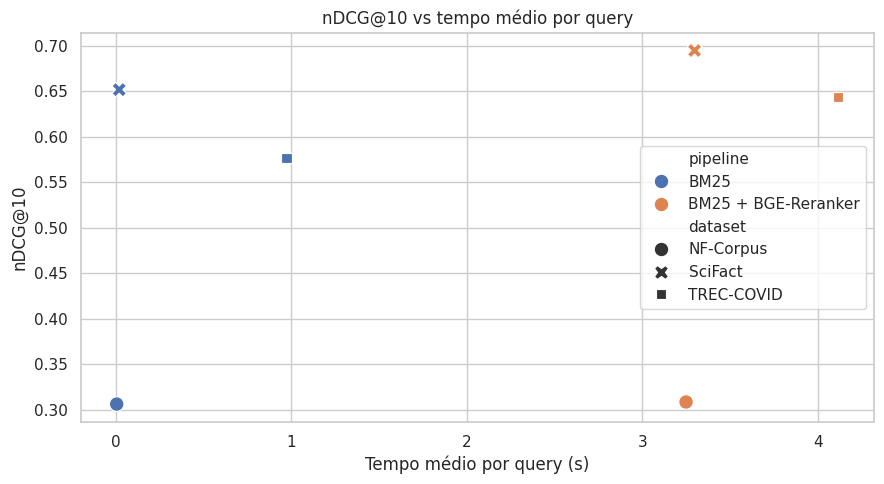

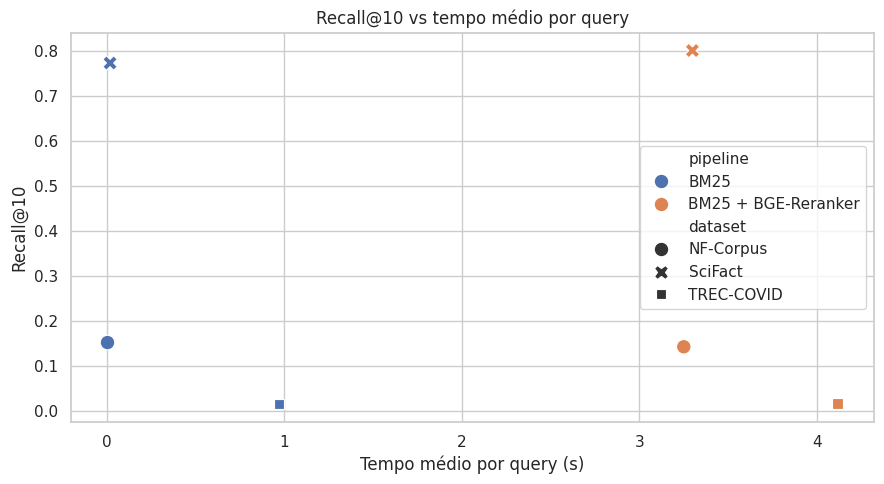

In [42]:
quality_cost_df = analysis_summary_base.copy()
quality_cost_df.to_csv("quality_cost_summary.csv", index=False)

for metric in ["nDCG@10", "Recall@10"]:
    plt.figure(figsize=(9, 5))
    ax = sns.scatterplot(
        data=quality_cost_df,
        x="avg_time_sec",
        y=metric,
        hue="pipeline",
        style="dataset",
        s=110,
    )
    ax.set_title(f"{metric} vs tempo médio por query")
    ax.set_xlabel("Tempo médio por query (s)")
    ax.set_ylabel(metric)
    plt.tight_layout()
    file_name = f"quality_cost_{metric.replace('@', '_at_')}.png"
    plt.savefig(file_name, dpi=160, bbox_inches="tight")
    plt.show()

fig = px.scatter(
    quality_cost_df,
    x="avg_time_sec",
    y="nDCG@10",
    color="pipeline",
    symbol="dataset",
    hover_data=["MRR@10", "Recall@10", "MAP@10", "num_queries"],
    title="Trade-off qualidade/custo: nDCG@10 vs tempo médio por query",
)
fig.write_html("quality_cost_ndcg_time.html")
fig.show()


### 3. Diagnóstico de falha: BM25 ou reranker?

Esta célula classifica cada query conforme o comportamento do pipeline: falha de candidatos iniciais, falha do reranker, sucesso do reranker ou caso sem mudança.


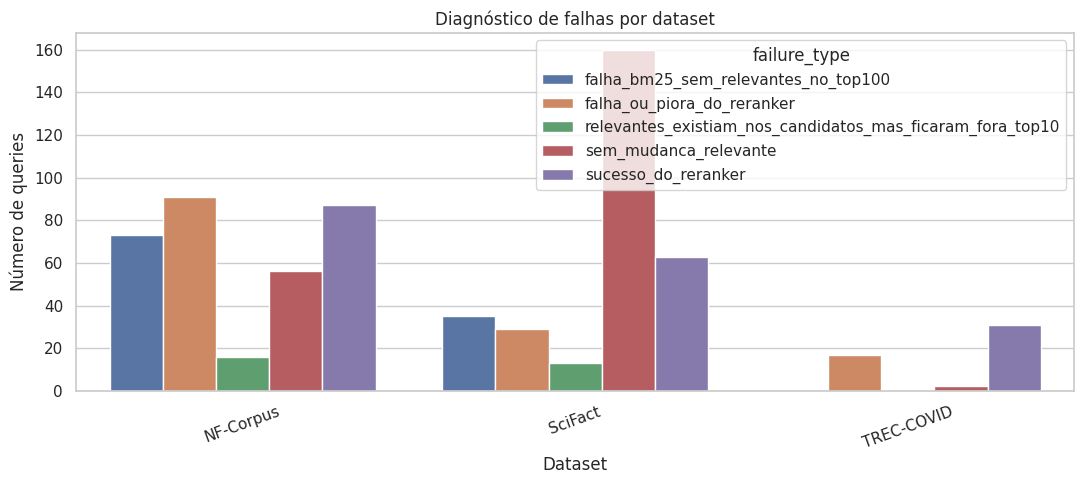

,dataset,failure_type,num_queries
0,NF-Corpus,falha_bm25_sem_relevantes_no_top100,73
1,NF-Corpus,falha_ou_piora_do_reranker,91
2,NF-Corpus,relevantes_existiam_nos_candidatos_mas_ficaram...,16
3,NF-Corpus,sem_mudanca_relevante,56
4,NF-Corpus,sucesso_do_reranker,87
5,SciFact,falha_bm25_sem_relevantes_no_top100,35
6,SciFact,falha_ou_piora_do_reranker,29
7,SciFact,relevantes_existiam_nos_candidatos_mas_ficaram...,13
8,SciFact,sem_mudanca_relevante,160
9,SciFact,sucesso_do_reranker,63


In [43]:
failure_rows = []
for row in query_deltas.itertuples(index=False):
    dataset = row.dataset
    query_id = str(row.query_id)
    relevant_ids = relevant_ids_for(dataset, query_id)
    bm25_top10 = ranked_ids(rankings_all, dataset, "BM25", query_id, k=10)
    bge_top10 = ranked_ids(rankings_all, dataset, "BM25 + BGE-Reranker", query_id, k=10)

    bm25_rel = [doc_id for doc_id in bm25_top10 if doc_id in relevant_ids]
    bge_rel = [doc_id for doc_id in bge_top10 if doc_id in relevant_ids]
    candidate_recall_col = f"candidate_recall@{CANDIDATE_RECALL_N}"
    candidate_rows = candidate_recall_all[
        (candidate_recall_all["dataset"] == dataset)
        & (candidate_recall_all["query_id"].astype(str) == query_id)
    ]
    candidate_recall = None if candidate_rows.empty else float(candidate_rows.iloc[0][candidate_recall_col])

    delta_ndcg = getattr(row, "_6", None)
    # itertuples renames columns with @, so read from query_deltas directly for safety.
    delta_ndcg = float(query_deltas[(query_deltas["dataset"] == dataset) & (query_deltas["query_id"].astype(str) == query_id)].iloc[0]["delta_nDCG@10"])

    if candidate_recall == 0:
        failure_type = "falha_bm25_sem_relevantes_no_top100"
    elif len(bm25_rel) == 0 and len(bge_rel) == 0:
        failure_type = "relevantes_existiam_nos_candidatos_mas_ficaram_fora_top10"
    elif len(bge_rel) < len(bm25_rel) or delta_ndcg < 0:
        failure_type = "falha_ou_piora_do_reranker"
    elif len(bge_rel) > len(bm25_rel) or delta_ndcg > 0:
        failure_type = "sucesso_do_reranker"
    else:
        failure_type = "sem_mudanca_relevante"

    failure_rows.append({
        "dataset": dataset,
        "query_id": query_id,
        "query": query_text_for(dataset, query_id),
        "candidate_recall@100": candidate_recall,
        "num_relevant_qrels": len(relevant_ids),
        "num_bm25_relevant_top10": len(bm25_rel),
        "num_bge_relevant_top10": len(bge_rel),
        "bm25_relevant_top10": bm25_rel,
        "bge_relevant_top10": bge_rel,
        "delta_nDCG@10": delta_ndcg,
        "failure_type": failure_type,
    })

failure_diagnosis = pd.DataFrame(failure_rows)
failure_diagnosis.to_csv("failure_diagnosis_by_query.csv", index=False)

failure_summary = (
    failure_diagnosis
    .groupby(["dataset", "failure_type"], as_index=False)
    .size()
    .rename(columns={"size": "num_queries"})
)
failure_summary.to_csv("failure_diagnosis_summary.csv", index=False)

plt.figure(figsize=(11, 5))
ax = sns.barplot(data=failure_summary, x="dataset", y="num_queries", hue="failure_type")
ax.set_title("Diagnóstico de falhas por dataset")
ax.set_xlabel("Dataset")
ax.set_ylabel("Número de queries")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("failure_diagnosis_summary.png", dpi=160, bbox_inches="tight")
plt.show()

display(failure_summary)


### 4. Heatmap de métricas

Esta célula cria um heatmap para comparar rapidamente datasets, pipelines, métricas e tempo.


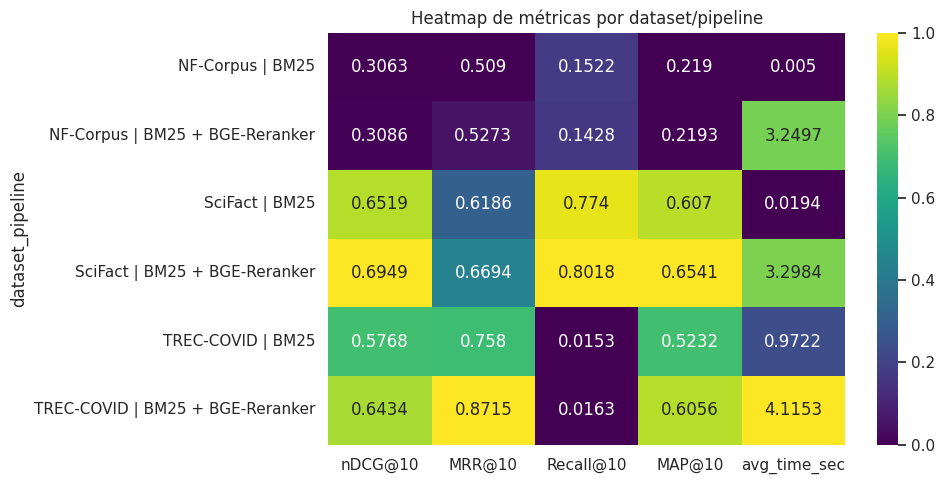

In [44]:
heatmap_metrics = ["nDCG@10", "MRR@10", "Recall@10", "MAP@10", "avg_time_sec"]
heatmap_df = analysis_summary_base.copy()
heatmap_df["dataset_pipeline"] = heatmap_df["dataset"] + " | " + heatmap_df["pipeline"]
heatmap_matrix = heatmap_df.set_index("dataset_pipeline")[heatmap_metrics]

# Normalização por coluna só para visualização: preserva a tabela original nos CSVs.
heatmap_norm = (heatmap_matrix - heatmap_matrix.min()) / (heatmap_matrix.max() - heatmap_matrix.min()).replace(0, 1)

plt.figure(figsize=(10, max(5, len(heatmap_norm) * 0.35)))
ax = sns.heatmap(heatmap_norm, annot=heatmap_matrix.round(4), fmt="", cmap="viridis")
ax.set_title("Heatmap de métricas por dataset/pipeline")
plt.tight_layout()
plt.savefig("metrics_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

heatmap_matrix.to_csv("metrics_heatmap_values.csv")


### 5. Overlap entre top-k do BM25 e do BGE

Esta célula mede quanto do top-10 do BM25 permanece no top-10 após o rerankeamento, e quantos documentos novos aparecem.


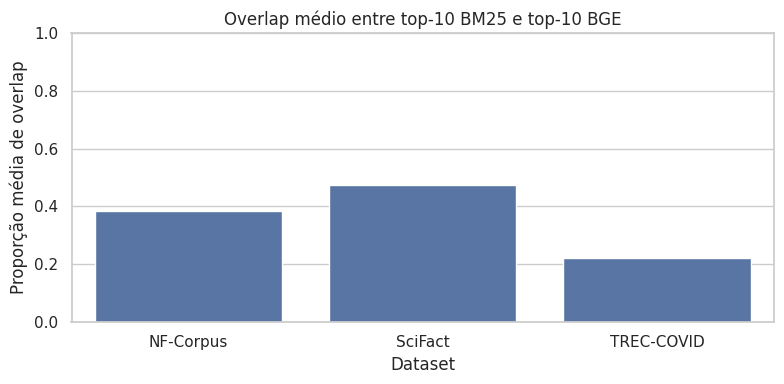

,dataset,avg_top10_overlap,avg_top10_overlap_ratio
0,NF-Corpus,3.854489,0.385449
1,SciFact,4.733333,0.473333
2,TREC-COVID,2.220000,0.222000


In [45]:
overlap_rows = []
for row in query_deltas.itertuples(index=False):
    dataset = row.dataset
    query_id = str(row.query_id)
    bm25_ids = ranked_ids(rankings_all, dataset, "BM25", query_id, k=10)
    bge_ids = ranked_ids(rankings_all, dataset, "BM25 + BGE-Reranker", query_id, k=10)
    overlap = sorted(set(bm25_ids) & set(bge_ids))
    new_after_bge = [doc_id for doc_id in bge_ids if doc_id not in set(bm25_ids)]
    removed_after_bge = [doc_id for doc_id in bm25_ids if doc_id not in set(bge_ids)]

    overlap_rows.append({
        "dataset": dataset,
        "query_id": query_id,
        "query": query_text_for(dataset, query_id),
        "top10_overlap_count": len(overlap),
        "top10_overlap_ratio": len(overlap) / 10,
        "new_docs_after_bge": new_after_bge,
        "removed_docs_after_bge": removed_after_bge,
    })

topk_overlap = pd.DataFrame(overlap_rows)
topk_overlap.to_csv("top10_overlap_bm25_bge_by_query.csv", index=False)

topk_overlap_summary = (
    topk_overlap
    .groupby("dataset", as_index=False)
    .agg(
        avg_top10_overlap=("top10_overlap_count", "mean"),
        avg_top10_overlap_ratio=("top10_overlap_ratio", "mean"),
    )
)
topk_overlap_summary.to_csv("top10_overlap_bm25_bge_summary.csv", index=False)

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=topk_overlap_summary, x="dataset", y="avg_top10_overlap_ratio")
ax.set_ylim(0, 1)
ax.set_title("Overlap médio entre top-10 BM25 e top-10 BGE")
ax.set_ylabel("Proporção média de overlap")
ax.set_xlabel("Dataset")
plt.tight_layout()
plt.savefig("top10_overlap_bm25_bge.png", dpi=160, bbox_inches="tight")
plt.show()

display(topk_overlap_summary)


### 6. Documentos relevantes que subiram ou caíram

Esta célula filtra a análise de chunks para focar apenas em documentos anotados como relevantes no qrels.


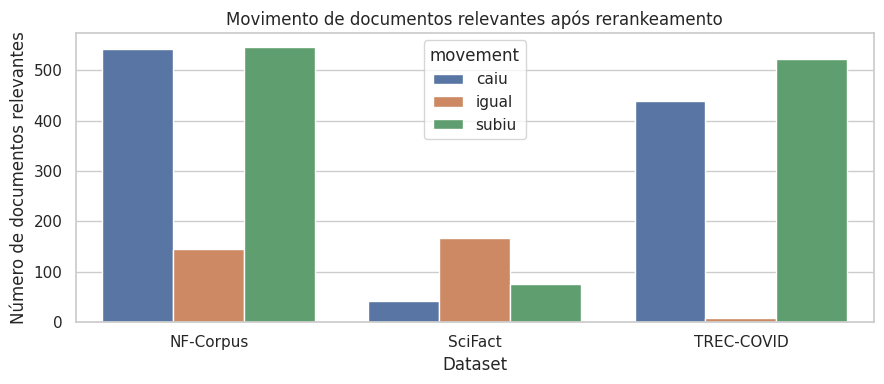

,dataset,query_id,query_text,doc_id,relevance,bm25_rank,reranker_rank,rank_delta,movement,bm25_score,reranker_score,appeared_only_after_reranker,dropped_after_reranker,doc_preview,doc_text
2136,NF-Corpus,PLAIN-1667,muscle health,MED-3453,1,NaN,1.0,20.0,subiu,NaN,0.441521,True,False,Supplementation with vitamin C and N-acetyl-cy...,Supplementation with vitamin C and N-acetyl-cy...
4877,NF-Corpus,PLAIN-248,Treating an Enlarged Prostate With Diet,MED-4234,1,NaN,1.0,20.0,subiu,NaN,0.369857,True,False,"Dietary patterns, supplement use, and the risk...","Dietary patterns, supplement use, and the risk..."
5333,NF-Corpus,PLAIN-2600,Eggs and Arterial Function,MED-2372,2,NaN,1.0,20.0,subiu,NaN,0.187115,True,False,Egg consumption and endothelial function: a ra...,Egg consumption and endothelial function: a ra...
5527,NF-Corpus,PLAIN-2660,How Long to Detox From Fish Before Pregnancy?,MED-3021,2,NaN,1.0,20.0,subiu,NaN,-4.532934,True,False,Hair-to-blood ratio and biological half-life o...,Hair-to-blood ratio and biological half-life o...
5628,NF-Corpus,PLAIN-2690,Chronic Headaches and Pork Tapeworms,MED-3175,2,NaN,1.0,20.0,subiu,NaN,0.755288,True,False,Neurocysticercosis in pregnancy: not just anot...,Neurocysticercosis in pregnancy: not just anot...
5791,NF-Corpus,PLAIN-2730,Anti-Angiogenesis: Cutting Off Tumor Supply Lines,MED-3550,2,NaN,1.0,20.0,subiu,NaN,-0.208223,True,False,Tumor Angiogenesis as a Target for Dietary Can...,Tumor Angiogenesis as a Target for Dietary Can...
6900,NF-Corpus,PLAIN-307,Vitamin D: Shedding some light on the new reco...,MED-716,2,NaN,1.0,20.0,subiu,NaN,-1.339305,True,False,VITAMIN D: A D-LIGHTFUL SOLUTION FOR HEALTH. T...,VITAMIN D: A D-LIGHTFUL SOLUTION FOR HEALTH. T...
7763,NF-Corpus,PLAIN-3332,Alcohol Risks vs. Benefits,MED-3768,1,NaN,1.0,20.0,subiu,NaN,1.401570,True,False,The positive and negative health effects of al...,The positive and negative health effects of al...
7837,NF-Corpus,PLAIN-3352,Boosting Heart Nerve Control,MED-3424,1,NaN,1.0,20.0,subiu,NaN,-1.619680,True,False,Subclinical endothelial dysfunction and low-gr...,Subclinical endothelial dysfunction and low-gr...
9463,NF-Corpus,PLAIN-731,bone fractures,MED-2987,1,NaN,1.0,20.0,subiu,NaN,0.252966,True,False,Protective effect of myo-inositol hexaphosphat...,Protective effect of myo-inositol hexaphosphat...


In [46]:
if "chunk_rank_changes" in globals() and not chunk_rank_changes.empty:
    relevant_rank_movements = chunk_rank_changes[chunk_rank_changes["relevance"] > 0].copy()
else:
    bm25_rel = rankings_all[rankings_all["pipeline"] == "BM25"][["dataset", "query_id", "doc_id", "rank", "score", "relevance", "doc_preview"]].rename(columns={"rank": "bm25_rank", "score": "bm25_score"})
    bge_rel = rankings_all[rankings_all["pipeline"] == "BM25 + BGE-Reranker"][["dataset", "query_id", "doc_id", "rank", "score", "relevance", "doc_preview"]].rename(columns={"rank": "reranker_rank", "score": "reranker_score"})
    relevant_rank_movements = bm25_rel.merge(bge_rel, on=["dataset", "query_id", "doc_id"], how="outer", suffixes=("_bm25", "_bge"))
    relevant_rank_movements["relevance"] = relevant_rank_movements["relevance_bm25"].combine_first(relevant_rank_movements["relevance_bge"]).fillna(0).astype(int)
    relevant_rank_movements["doc_preview"] = relevant_rank_movements["doc_preview_bm25"].combine_first(relevant_rank_movements["doc_preview_bge"])
    missing_rank = max(EVAL_K_VALUES) + 1
    relevant_rank_movements["rank_delta"] = relevant_rank_movements["bm25_rank"].fillna(missing_rank) - relevant_rank_movements["reranker_rank"].fillna(missing_rank)
    relevant_rank_movements = relevant_rank_movements[relevant_rank_movements["relevance"] > 0]

relevant_rank_movements["movement"] = np.select(
    [relevant_rank_movements["rank_delta"] > 0, relevant_rank_movements["rank_delta"] < 0],
    ["subiu", "caiu"],
    default="igual",
)
relevant_rank_movements.to_csv("relevant_documents_rank_movements.csv", index=False)

relevant_movement_summary = (
    relevant_rank_movements
    .groupby(["dataset", "movement"], as_index=False)
    .size()
    .rename(columns={"size": "num_relevant_docs"})
)
relevant_movement_summary.to_csv("relevant_documents_rank_movements_summary.csv", index=False)

plt.figure(figsize=(9, 4))
ax = sns.barplot(data=relevant_movement_summary, x="dataset", y="num_relevant_docs", hue="movement")
ax.set_title("Movimento de documentos relevantes após rerankeamento")
ax.set_xlabel("Dataset")
ax.set_ylabel("Número de documentos relevantes")
plt.tight_layout()
plt.savefig("relevant_documents_rank_movements.png", dpi=160, bbox_inches="tight")
plt.show()

display(relevant_rank_movements.sort_values(["dataset", "rank_delta"], ascending=[True, False]).head(30))


### 7. RRF entre BM25 e BGE

Esta célula cria um pipeline pós-hoc que combina o ranking BM25 e o ranking BGE por Reciprocal Rank Fusion. A ideia é testar se preservar parte do sinal lexical do BM25 reduz pioras do reranker.


In [47]:
rrf_bm25_bge_rows = []
rrf_bm25_bge_rankings = []

for row in query_deltas.itertuples(index=False):
    dataset = row.dataset
    query_id = str(row.query_id)
    query_text = query_text_for(dataset, query_id)
    relevant_docs = None
    for case in experiment_cache.values():
        if case["config"]["name"] == dataset:
            relevant_docs = case["qrels"].get(query_id, {})
            documents = case["documents"]
            break
    if relevant_docs is None:
        continue

    bm25_items = ranking_items(rankings_all, dataset, "BM25", query_id, k=max(EVAL_K_VALUES))
    bge_items = ranking_items(rankings_all, dataset, "BM25 + BGE-Reranker", query_id, k=max(EVAL_K_VALUES))
    fused = reciprocal_rank_fusion([bm25_items, bge_items], rrf_k=HYBRID_RRF_K, top_k=max(EVAL_K_VALUES))
    fused_doc_ids = [item["doc_id"] for item in fused]
    metrics = metric_values(fused_doc_ids, relevant_docs)

    rrf_bm25_bge_rows.append({
        "dataset": dataset,
        "pipeline": "RRF BM25 + BGE",
        "query_id": query_id,
        "query_text": query_text,
        "elapsed_sec": 0.0,
        **metrics,
    })

    for rank, item in enumerate(fused, start=1):
        doc_id = item["doc_id"]
        rrf_bm25_bge_rankings.append({
            "dataset": dataset,
            "pipeline": "RRF BM25 + BGE",
            "query_id": query_id,
            "query_text": query_text,
            "rank": rank,
            "doc_id": doc_id,
            "score": item["score"],
            "relevance": relevant_docs.get(doc_id, 0),
            "doc_text": documents.get(doc_id, ""),
            "doc_preview": preview_text(documents.get(doc_id, ""), 500),
        })

rrf_bm25_bge_df = pd.DataFrame(rrf_bm25_bge_rows)
rrf_bm25_bge_rankings = pd.DataFrame(rrf_bm25_bge_rankings)
rrf_bm25_bge_grouped = grouped_ranking_rows(rrf_bm25_bge_rankings)
rrf_bm25_bge_summary = summarize_results(rrf_bm25_bge_df)

rrf_bm25_bge_df.to_csv("results_rrf_bm25_bge.csv", index=False)
rrf_bm25_bge_rankings.to_csv("rankings_rrf_bm25_bge.csv", index=False)
rrf_bm25_bge_grouped.to_csv("rankings_grouped_rrf_bm25_bge.csv", index=False)
save_grouped_rankings_json(rrf_bm25_bge_grouped, "rankings_grouped_rrf_bm25_bge.json")
rrf_bm25_bge_summary.to_csv("summary_rrf_bm25_bge.csv", index=False)

summary_with_rrf_bm25_bge = pd.concat([analysis_summary_base, rrf_bm25_bge_summary], ignore_index=True)
summary_with_rrf_bm25_bge.to_csv("summary_with_rrf_bm25_bge.csv", index=False)
display(summary_with_rrf_bm25_bge)


,dataset,pipeline,nDCG@10,MRR@10,Recall@10,MAP@10,avg_time_sec,total_time_sec,num_queries,nDCG@5,MRR@5,Recall@5,MAP@5,nDCG@20,MRR@20,Recall@20,MAP@20,candidate_recall@100
0,NF-Corpus,BM25,0.306317,0.508971,0.152153,0.219001,0.004985,1.610298,323,0.334028,0.499742,0.115050,0.268051,0.278253,0.510282,0.172116,0.178807,0.235936
1,NF-Corpus,BM25 + BGE-Reranker,0.308620,0.527299,0.142758,0.219340,3.249737,1049.665175,323,0.343844,0.520795,0.115398,0.274281,0.280110,0.529833,0.167174,0.178012,0.235936
2,SciFact,BM25,0.651893,0.618615,0.774000,0.606975,0.019358,5.807493,300,0.636032,0.613222,0.728444,0.599106,0.667184,0.622329,0.832278,0.611460,0.873056
3,SciFact,BM25 + BGE-Reranker,0.694917,0.669444,0.801833,0.654127,3.298408,989.522298,300,0.676903,0.663000,0.752611,0.645000,0.706466,0.672174,0.845722,0.657581,0.873056
4,TREC-COVID,BM25,0.576817,0.758000,0.015293,0.523202,0.972226,48.611324,50,0.606150,0.751333,0.007984,0.573867,0.524540,0.759667,0.027364,0.448882,0.093570
5,TREC-COVID,BM25 + BGE-Reranker,0.643443,0.871524,0.016341,0.605649,4.115285,205.764230,50,0.691654,0.868667,0.009265,0.686733,0.617824,0.871524,0.031637,0.559027,0.093570
6,NF-Corpus,RRF BM25 + BGE,0.317711,0.545983,0.148118,0.227282,0.000000,0.000000,323,0.354947,0.540609,0.122924,0.285592,0.291427,0.547697,0.178349,0.186762,NaN
7,SciFact,RRF BM25 + BGE,0.693752,0.659336,0.820778,0.646817,0.000000,0.000000,300,0.676209,0.653611,0.769556,0.638472,0.699363,0.660485,0.839611,0.648983,NaN
8,TREC-COVID,RRF BM25 + BGE,0.669321,0.925667,0.017417,0.629600,0.000000,0.000000,50,0.726466,0.925667,0.009713,0.726333,0.604654,0.925667,0.030447,0.537903,NaN


### 8. Relatório final em Markdown

Esta célula exporta um relatório `relatorio_experimento.md` com os principais resultados, gráficos e arquivos gerados.


In [48]:
from datetime import datetime

report_lines = [
    "# Relatório do experimento BEIR: BM25, BGE-Reranker e análises complementares",
    "",
    f"Gerado em: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    "",
    "## Datasets",
]

for row in dataset_stats.itertuples(index=False):
    report_lines.append(f"- **{row.dataset}**: {row.num_documents} documentos, {row.num_queries} queries, média de {row.avg_relevant_docs_per_query:.2f} docs relevantes por query.")

report_lines.extend(["", "## Resumo principal", ""])
report_lines.append(summary.to_markdown(index=False))

if "automatic_conclusions" in globals() and not automatic_conclusions.empty:
    report_lines.extend(["", "## Conclusões automáticas", ""])
    report_lines.append(automatic_conclusions.to_markdown(index=False))

if "failure_summary" in globals() and not failure_summary.empty:
    report_lines.extend(["", "## Diagnóstico de falhas", ""])
    report_lines.append(failure_summary.to_markdown(index=False))

if "topk_overlap_summary" in globals() and not topk_overlap_summary.empty:
    report_lines.extend(["", "## Overlap BM25 vs BGE", ""])
    report_lines.append(topk_overlap_summary.to_markdown(index=False))

if "rrf_bm25_bge_summary" in globals() and not rrf_bm25_bge_summary.empty:
    report_lines.extend(["", "## RRF BM25 + BGE", ""])
    report_lines.append(rrf_bm25_bge_summary.to_markdown(index=False))

report_lines.extend([
    "",
    "## Figuras principais",
    "",
    "- `metrics_mean_comparison.png`",
    "- `metric_improvements_delta.png`",
    "- `query_level_delta_distribution.png`",
    "- `precision_recall_curves.png`",
    "- `quality_cost_nDCG_at_10.png`",
    "- `quality_cost_Recall_at_10.png`",
    "- `failure_diagnosis_summary.png`",
    "- `metrics_heatmap.png`",
    "- `top10_overlap_bm25_bge.png`",
    "- `relevant_documents_rank_movements.png`",
    "",
    "## Arquivos de auditoria qualitativa",
    "",
    "- `query_rankings_bm25_vs_bge_all_datasets.json`",
    "- `qualitative_query_analysis_<dataset>.json`",
    "- `qualitative_chunk_analysis_<dataset>.json`",
    "- `qualitative_reranking_analysis_<dataset>.json`",
])

with open("relatorio_experimento.md", "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print("Relatório salvo em relatorio_experimento.md")


Relatório salvo em relatorio_experimento.md


## Classificador: quando aplicar o reranker?

Esta seção treina uma política seletiva para prever se o BGE-Reranker melhora uma query. O rótulo é `delta_nDCG@10 > 0`; empate e piora são tratados como **não rerankear**.

As features usam somente informações disponíveis antes do rerankeamento: texto da query, distribuição dos scores BM25, margens entre candidatos e cobertura lexical nos documentos recuperados. Qrels e métricas pós-rerankeamento são usados somente para criar o rótulo.

A implementação está inteiramente incorporada ao notebook e não depende de `reranking_query_classifier.py`.


In [49]:
import json
import re
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

TOKEN_RE = re.compile(r"(?u)\b\w+\b")
TARGET_THRESHOLD = 1e-12


def classifier_tokens(text):
    return TOKEN_RE.findall(str(text).lower())


def safe_ratio(numerator, denominator):
    return float(numerator / denominator) if denominator else 0.0


def softmax_entropy(values):
    shifted = values - values.max()
    probabilities = np.exp(shifted)
    probabilities /= probabilities.sum()
    entropy = -(probabilities * np.log(probabilities + 1e-12)).sum()
    return float(entropy / np.log(len(values))) if len(values) > 1 else 0.0


def query_features(query):
    tokens = classifier_tokens(query)
    char_count = len(query)
    return {
        "query_char_count": char_count,
        "query_word_count": len(tokens),
        "query_unique_ratio": safe_ratio(len(set(tokens)), len(tokens)),
        "query_avg_word_length": safe_ratio(sum(map(len, tokens)), len(tokens)),
        "query_digit_ratio": safe_ratio(sum(c.isdigit() for c in query), char_count),
        "query_punctuation_ratio": safe_ratio(
            sum(not c.isalnum() and not c.isspace() for c in query), char_count
        ),
    }


def ranking_features(group):
    ordered = group.sort_values("rank")
    scores = ordered["score"].astype(float).to_numpy()
    top10_scores = scores[:10]
    query_token_set = set(classifier_tokens(ordered["query_text"].iloc[0]))
    document_token_sets = [
        set(classifier_tokens(text)) for text in ordered["doc_text"].fillna("")
    ]
    coverages = np.array([
        safe_ratio(len(query_token_set & tokens), len(query_token_set))
        for tokens in document_token_sets
    ])
    document_lengths = np.array([len(tokens) for tokens in document_token_sets], dtype=float)
    return {
        "bm25_score_max": scores.max(),
        "bm25_score_mean": scores.mean(),
        "bm25_score_std": scores.std(),
        "bm25_score_range": scores.max() - scores.min(),
        "bm25_top1_top2_margin": scores[0] - scores[1] if len(scores) > 1 else 0.0,
        "bm25_top1_top5_margin": scores[0] - scores[min(4, len(scores) - 1)],
        "bm25_top10_std": top10_scores.std(),
        "bm25_top10_entropy": softmax_entropy(top10_scores),
        "bm25_top1_mean_ratio": safe_ratio(scores[0], scores.mean()),
        "bm25_score_slope": np.polyfit(np.arange(1, len(scores) + 1), scores, 1)[0]
        if len(scores) > 1 else 0.0,
        "lexical_coverage_top1": coverages[0],
        "lexical_coverage_mean": coverages.mean(),
        "lexical_coverage_max": coverages.max(),
        "lexical_coverage_std": coverages.std(),
        "lexical_coverage_top3_mean": coverages[:3].mean(),
        "doc_word_count_mean": document_lengths.mean(),
        "doc_word_count_std": document_lengths.std(),
    }


def build_pre_reranking_features(rankings):
    required = {"dataset", "pipeline", "query_id", "query_text", "rank", "score", "doc_text"}
    missing = required - set(rankings.columns)
    if missing:
        raise ValueError(f"Colunas ausentes no ranking: {sorted(missing)}")
    rows = []
    bm25 = rankings[rankings["pipeline"] == "BM25"]
    for (dataset, query_id), group in bm25.groupby(["dataset", "query_id"], sort=False):
        query = str(group["query_text"].iloc[0])
        rows.append({
            "dataset": dataset,
            "query_id": str(query_id),
            "query_text": query,
            **query_features(query),
            **ranking_features(group),
        })
    return pd.DataFrame(rows)


def build_classifier_dataset(rankings, metric_deltas):
    features = build_pre_reranking_features(rankings)
    labels = metric_deltas[["dataset", "query_id", "delta_nDCG@10"]].copy()
    labels["query_id"] = labels["query_id"].astype(str)
    data = features.merge(labels, on=["dataset", "query_id"], validate="one_to_one")
    data["rerank_beneficial"] = (data["delta_nDCG@10"] > TARGET_THRESHOLD).astype(int)
    return data


def make_query_classifier(numeric_columns):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    features = ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_columns),
        ("query_tfidf", TfidfVectorizer(
            lowercase=True, ngram_range=(1, 2), min_df=2,
            max_features=3000, sublinear_tf=True,
        ), "query_text"),
    ])
    return Pipeline([
        ("features", features),
        ("classifier", LogisticRegression(
            class_weight="balanced", max_iter=2000, random_state=42,
        )),
    ])


def classifier_evaluation_summary(frame, probabilities, evaluation):
    target = frame["rerank_beneficial"].to_numpy()
    predicted = (probabilities >= 0.5).astype(int)
    deltas = frame["delta_nDCG@10"].to_numpy()
    selected_delta = deltas * predicted
    positive_gain = np.clip(deltas, 0, None)
    return {
        "evaluation": evaluation,
        "queries": len(frame),
        "positive_rate": target.mean(),
        "roc_auc": roc_auc_score(target, probabilities),
        "average_precision": average_precision_score(target, probabilities),
        "balanced_accuracy": balanced_accuracy_score(target, predicted),
        "precision": precision_score(target, predicted, zero_division=0),
        "recall": recall_score(target, predicted, zero_division=0),
        "f1": f1_score(target, predicted, zero_division=0),
        "rerank_rate": predicted.mean(),
        "mean_delta_always_rerank": deltas.mean(),
        "mean_delta_classifier": selected_delta.mean(),
        "mean_delta_oracle": positive_gain.mean(),
        "gain_retention_vs_always": safe_ratio(selected_delta.mean(), deltas.mean()),
        "reranker_calls_saved_ratio": 1.0 - predicted.mean(),
        "captured_positive_gain_ratio": safe_ratio(
            (positive_gain * predicted).sum(), positive_gain.sum()
        ),
        "harmful_queries_avoided_ratio": safe_ratio(
            ((deltas < -TARGET_THRESHOLD) & (predicted == 0)).sum(),
            (deltas < -TARGET_THRESHOLD).sum(),
        ),
    }


def evaluate_query_classifier(frame):
    excluded = {"dataset", "query_id", "query_text", "delta_nDCG@10", "rerank_beneficial"}
    numeric_columns = [column for column in frame.columns if column not in excluded]
    x = frame[["query_text", *numeric_columns]]
    y = frame["rerank_beneficial"]
    evaluations = [
        ("stratified_5_fold", StratifiedKFold(5, shuffle=True, random_state=42), None),
        ("leave_one_dataset_out", GroupKFold(frame["dataset"].nunique()), frame["dataset"]),
    ]
    summaries = []
    prediction_frames = []
    for name, cv, groups in evaluations:
        probabilities = cross_val_predict(
            make_query_classifier(numeric_columns), x, y, groups=groups,
            cv=cv, method="predict_proba", n_jobs=-1,
        )[:, 1]
        predictions = frame[[
            "dataset", "query_id", "query_text", "delta_nDCG@10", "rerank_beneficial"
        ]].copy()
        predictions["evaluation"] = name
        predictions["rerank_probability"] = probabilities
        predictions["rerank_predicted"] = (probabilities >= 0.5).astype(int)
        prediction_frames.append(predictions)
        summaries.append(classifier_evaluation_summary(frame, probabilities, name))
    return pd.DataFrame(summaries), pd.concat(prediction_frames, ignore_index=True)


def predict_reranking_need(rankings, model, threshold=0.5):
    features = build_pre_reranking_features(rankings)
    probabilities = model.predict_proba(features[list(model.feature_names_in_)])[:, 1]
    result = features[["dataset", "query_id", "query_text"]].copy()
    result["rerank_probability"] = probabilities
    result["rerank_predicted"] = (probabilities >= threshold).astype(int)
    return result


def run_query_classifier_experiment(rankings, metric_deltas, output_dir="."):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    data = build_classifier_dataset(rankings, metric_deltas)
    summary, predictions = evaluate_query_classifier(data)
    excluded = {"dataset", "query_id", "query_text", "delta_nDCG@10", "rerank_beneficial"}
    numeric_columns = [column for column in data.columns if column not in excluded]
    model = make_query_classifier(numeric_columns)
    model.fit(data[["query_text", *numeric_columns]], data["rerank_beneficial"])
    feature_names = model.named_steps["features"].get_feature_names_out()
    coefficients = model.named_steps["classifier"].coef_[0]
    coefficient_table = pd.DataFrame({
        "feature": feature_names, "coefficient": coefficients,
    }).sort_values("coefficient", key=lambda values: values.abs(), ascending=False)
    data.to_csv(output_dir / "query_classifier_dataset.csv", index=False)
    summary.to_csv(output_dir / "query_classifier_evaluation.csv", index=False)
    predictions.to_csv(output_dir / "query_classifier_predictions.csv", index=False)
    coefficient_table.to_csv(output_dir / "query_classifier_coefficients.csv", index=False)
    joblib.dump(model, output_dir / "query_reranking_classifier.joblib")
    metadata = {
        "target": "delta_nDCG@10 > 0",
        "decision_threshold": 0.5,
        "numeric_features": numeric_columns,
        "important_constraint": "Todas as features existem antes do rerankeamento.",
    }
    (output_dir / "query_classifier_metadata.json").write_text(
        json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8"
    )
    return {"dataset": data, "summary": summary, "predictions": predictions, "model": model}


In [50]:
query_classifier_results = run_query_classifier_experiment(
    rankings=rankings_all,
    metric_deltas=query_deltas,
    output_dir=".",
)

display(query_classifier_results["summary"].round(4))
display(
    query_classifier_results["dataset"]
    .groupby("dataset")["rerank_beneficial"]
    .agg(queries="size", beneficial_rate="mean")
    .reset_index()
    .round(4)
)


,evaluation,queries,positive_rate,roc_auc,average_precision,balanced_accuracy,precision,recall,f1,rerank_rate,mean_delta_always_rerank,mean_delta_classifier,mean_delta_oracle,gain_retention_vs_always,reranker_calls_saved_ratio,captured_positive_gain_ratio,harmful_queries_avoided_ratio
0,stratified_5_fold,673,0.2808,0.7145,0.4614,0.637,0.4120,0.6190,0.4947,0.4220,0.0252,0.0187,0.0605,0.7420,0.5780,0.6241,0.4264
1,leave_one_dataset_out,673,0.2808,0.4740,0.2538,0.526,0.2955,0.7566,0.4250,0.7192,0.0252,0.0243,0.0605,0.9617,0.2808,0.8038,0.3566


,dataset,queries,beneficial_rate
0,NF-Corpus,323,0.2879
1,SciFact,300,0.2100
2,TREC-COVID,50,0.6600


## Benchmark query-only

### Comparação de modelos para decidir quando rerankear

Os modelos abaixo recebem **somente o texto da query**. Scores, posições e documentos do BM25 não são usados como features. O rótulo continua sendo `delta_nDCG@10 > 0`.

São comparados TF-IDF de palavras, TF-IDF de caracteres, *gradient boosting* com atributos linguísticos, embedding com regressão logística e embedding com uma pequena rede neural MLP.

Esta análise é exploratória. A validação estratificada mede generalização entre queries misturando os três datasets, enquanto *leave-one-dataset-out* é um cenário mais rigoroso de transferência para um domínio não visto.


In [51]:
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

QUERY_ONLY_EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
QUERY_ONLY_SEED = 42


def build_query_only_data(rankings, metric_deltas):
    queries = rankings[["dataset", "query_id", "query_text"]].drop_duplicates(
        ["dataset", "query_id"]
    ).copy()
    queries["query_id"] = queries["query_id"].astype(str)
    labels = metric_deltas[["dataset", "query_id", "delta_nDCG@10"]].copy()
    labels["query_id"] = labels["query_id"].astype(str)
    data = queries.merge(labels, on=["dataset", "query_id"], validate="one_to_one")
    data["rerank_beneficial"] = (data["delta_nDCG@10"] > TARGET_THRESHOLD).astype(int)
    linguistic = pd.DataFrame(
        [query_features(str(query)) for query in data["query_text"]],
        index=data.index,
    )
    return pd.concat([data, linguistic], axis=1)


def query_only_model_specs():
    balanced_logistic = lambda: LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=QUERY_ONLY_SEED
    )
    return {
        "word_tfidf_logistic": ("text", Pipeline([
            ("tfidf", TfidfVectorizer(
                ngram_range=(1, 2), min_df=2, max_features=5000, sublinear_tf=True
            )),
            ("classifier", balanced_logistic()),
        ]), False),
        "char_tfidf_logistic": ("text", Pipeline([
            ("tfidf", TfidfVectorizer(
                analyzer="char_wb", ngram_range=(3, 5), min_df=2,
                max_features=8000, sublinear_tf=True,
            )),
            ("classifier", balanced_logistic()),
        ]), False),
        "linguistic_gradient_boosting": ("linguistic", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("classifier", HistGradientBoostingClassifier(
                learning_rate=0.05, max_iter=150, max_leaf_nodes=15,
                l2_regularization=1.0, class_weight="balanced",
                random_state=QUERY_ONLY_SEED,
            )),
        ]), False),
        "embedding_logistic": ("embedding", Pipeline([
            ("scale", StandardScaler()),
            ("classifier", LogisticRegression(
                class_weight="balanced", C=0.1, max_iter=2000,
                random_state=QUERY_ONLY_SEED,
            )),
        ]), False),
        "embedding_mlp": ("embedding", Pipeline([
            ("scale", StandardScaler()),
            ("classifier", MLPClassifier(
                hidden_layer_sizes=(64,), alpha=1.0, max_iter=500,
                early_stopping=True, validation_fraction=0.15,
                n_iter_no_change=25, random_state=QUERY_ONLY_SEED,
            )),
        ]), True),
    }


def balance_training_fold(x, y, seed):
    y = np.asarray(y)
    rng = np.random.default_rng(seed)
    groups = [np.flatnonzero(y == label) for label in np.unique(y)]
    target_size = max(map(len, groups))
    indices = np.concatenate([
        np.concatenate([group, rng.choice(group, target_size - len(group), replace=True)])
        if len(group) < target_size else group
        for group in groups
    ])
    rng.shuffle(indices)
    return (x.iloc[indices] if hasattr(x, "iloc") else x[indices]), y[indices]


def benchmark_input(data, input_type, linguistic_columns, embeddings):
    if input_type == "text":
        return data["query_text"]
    if input_type == "linguistic":
        return data[linguistic_columns]
    return embeddings


def evaluate_query_only_benchmark(data, embeddings):
    y = data["rerank_beneficial"].to_numpy()
    linguistic_columns = list(query_features("").keys())
    split_sets = {
        "stratified_5_fold": list(StratifiedKFold(
            5, shuffle=True, random_state=QUERY_ONLY_SEED
        ).split(data, y)),
        "leave_one_dataset_out": list(GroupKFold(
            data["dataset"].nunique()
        ).split(data, y, groups=data["dataset"])),
    }
    summary_rows, prediction_frames, training_history_rows = [], [], []
    for model_name, (input_type, template, oversample) in query_only_model_specs().items():
        x = benchmark_input(data, input_type, linguistic_columns, embeddings)
        for evaluation, splits in split_sets.items():
            probabilities = np.zeros(len(data))
            for fold, (train_idx, test_idx) in enumerate(splits):
                x_train = x.iloc[train_idx] if hasattr(x, "iloc") else x[train_idx]
                x_test = x.iloc[test_idx] if hasattr(x, "iloc") else x[test_idx]
                y_train = y[train_idx]
                if oversample:
                    x_train, y_train = balance_training_fold(
                        x_train, y_train, QUERY_ONLY_SEED + fold
                    )
                model = clone(template).fit(x_train, y_train)
                if model_name == "embedding_mlp":
                    classifier = model.named_steps["classifier"]
                    loss_curve = getattr(classifier, "loss_curve_", [])
                    validation_scores = getattr(classifier, "validation_scores_", [])
                    for epoch in range(max(len(loss_curve), len(validation_scores))):
                        training_history_rows.append({
                            "model": model_name,
                            "evaluation": evaluation,
                            "fold": fold,
                            "epoch": epoch + 1,
                            "loss": loss_curve[epoch] if epoch < len(loss_curve) else np.nan,
                            "validation_score": (
                                validation_scores[epoch]
                                if epoch < len(validation_scores) else np.nan
                            ),
                            "n_iter": getattr(classifier, "n_iter_", np.nan),
                            "train_size": len(y_train),
                            "test_size": len(test_idx),
                        })
                probabilities[test_idx] = model.predict_proba(x_test)[:, 1]
            metrics = classifier_evaluation_summary(data, probabilities, evaluation)
            metrics.update({"model": model_name, "input": input_type})
            summary_rows.append(metrics)
            fold_predictions = data[[
                "dataset", "query_id", "query_text",
                "delta_nDCG@10", "rerank_beneficial",
            ]].copy()
            fold_predictions["model"] = model_name
            fold_predictions["evaluation"] = evaluation
            fold_predictions["rerank_probability"] = probabilities
            fold_predictions["rerank_predicted"] = (probabilities >= 0.5).astype(int)
            prediction_frames.append(fold_predictions)
    return (
        pd.DataFrame(summary_rows),
        pd.concat(prediction_frames, ignore_index=True),
        pd.DataFrame(training_history_rows),
    )


def run_query_only_benchmark(rankings, metric_deltas, output_dir="."):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    data = build_query_only_data(rankings, metric_deltas)
    print(f"Gerando embeddings para {len(data)} queries...")
    encoder = SentenceTransformer(QUERY_ONLY_EMBEDDING_MODEL)
    embedding_start = time.perf_counter()
    embeddings = encoder.encode(
        data["query_text"].tolist(), batch_size=64, show_progress_bar=True,
        convert_to_numpy=True, normalize_embeddings=True,
    )
    embedding_elapsed_sec = time.perf_counter() - embedding_start
    timing = {
        "embedding_encode_total_sec": embedding_elapsed_sec,
        "embedding_encode_avg_sec": safe_ratio(embedding_elapsed_sec, len(data)),
    }
    summary, predictions, training_history = evaluate_query_only_benchmark(data, embeddings)
    data.to_csv(output_dir / "query_only_classifier_dataset.csv", index=False)
    summary.to_csv(output_dir / "query_only_model_benchmark.csv", index=False)
    predictions.to_csv(output_dir / "query_only_model_predictions.csv", index=False)
    training_history.to_csv(output_dir / "query_only_mlp_training_history.csv", index=False)
    np.save(output_dir / "query_only_embeddings.npy", embeddings)
    return {
        "dataset": data,
        "summary": summary,
        "predictions": predictions,
        "training_history": training_history,
        "embeddings": embeddings,
        "timing": timing,
    }


Gerando embeddings para 673 queries...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

,evaluation,queries,positive_rate,roc_auc,average_precision,balanced_accuracy,precision,recall,f1,rerank_rate,mean_delta_always_rerank,mean_delta_classifier,mean_delta_oracle,gain_retention_vs_always,reranker_calls_saved_ratio,captured_positive_gain_ratio,harmful_queries_avoided_ratio,model,input
3,leave_one_dataset_out,673,0.2808,0.5294,0.3059,0.5360,0.3416,0.2910,0.3143,0.2392,0.0252,0.0138,0.0605,0.5475,0.7608,0.3484,0.8295,char_tfidf_logistic,text
1,leave_one_dataset_out,673,0.2808,0.4911,0.2802,0.4799,0.2597,0.3545,0.2998,0.3834,0.0252,0.0107,0.0605,0.4248,0.6166,0.4497,0.6744,word_tfidf_logistic,text
7,leave_one_dataset_out,673,0.2808,0.4784,0.2674,0.4854,0.2645,0.3386,0.2970,0.3596,0.0252,0.0098,0.0605,0.3866,0.6404,0.3323,0.6667,embedding_logistic,embedding
9,leave_one_dataset_out,673,0.2808,0.4673,0.2802,0.4652,0.2389,0.2857,0.2602,0.3358,0.0252,0.0059,0.0605,0.2338,0.6642,0.2768,0.6202,embedding_mlp,embedding
5,leave_one_dataset_out,673,0.2808,0.4065,0.2277,0.4353,0.2257,0.3810,0.2835,0.4740,0.0252,0.0143,0.0605,0.5676,0.5260,0.5137,0.6822,linguistic_gradient_boosting,linguistic
2,stratified_5_fold,673,0.2808,0.6808,0.4754,0.6403,0.5000,0.4603,0.4793,0.2585,0.0252,0.0128,0.0605,0.5070,0.7415,0.3981,0.6899,char_tfidf_logistic,text
8,stratified_5_fold,673,0.2808,0.6357,0.4446,0.6058,0.4355,0.4286,0.4320,0.2764,0.0252,0.0130,0.0605,0.5162,0.7236,0.3835,0.7054,embedding_mlp,embedding
0,stratified_5_fold,673,0.2808,0.6353,0.4523,0.6223,0.4765,0.4286,0.4513,0.2526,0.0252,0.0121,0.0605,0.4795,0.7474,0.3865,0.6977,word_tfidf_logistic,text
6,stratified_5_fold,673,0.2808,0.6036,0.3777,0.5726,0.3644,0.4550,0.4047,0.3507,0.0252,0.0148,0.0605,0.5879,0.6493,0.4598,0.6357,embedding_logistic,embedding
4,stratified_5_fold,673,0.2808,0.5220,0.2912,0.5085,0.2905,0.3704,0.3256,0.3581,0.0252,0.0028,0.0605,0.1098,0.6419,0.3261,0.5271,linguistic_gradient_boosting,linguistic


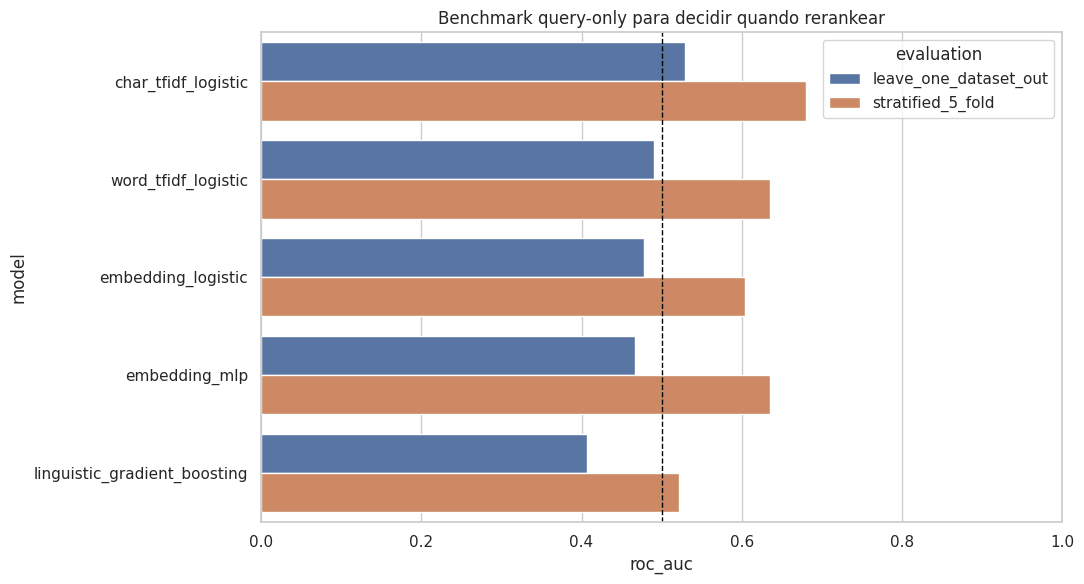

,model,evaluation,fold,epoch,loss,validation_score,n_iter,train_size,test_size
0,embedding_mlp,stratified_5_fold,0,1,1.117203,0.598291,78,774,135
1,embedding_mlp,stratified_5_fold,0,2,0.945935,0.615385,78,774,135
2,embedding_mlp,stratified_5_fold,0,3,0.855081,0.692308,78,774,135
3,embedding_mlp,stratified_5_fold,0,4,0.782941,0.735043,78,774,135
4,embedding_mlp,stratified_5_fold,0,5,0.722355,0.743590,78,774,135


/tmp/ipykernel_6883/1336950671.py:30: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.


/tmp/ipykernel_6883/1336950671.py:40: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.




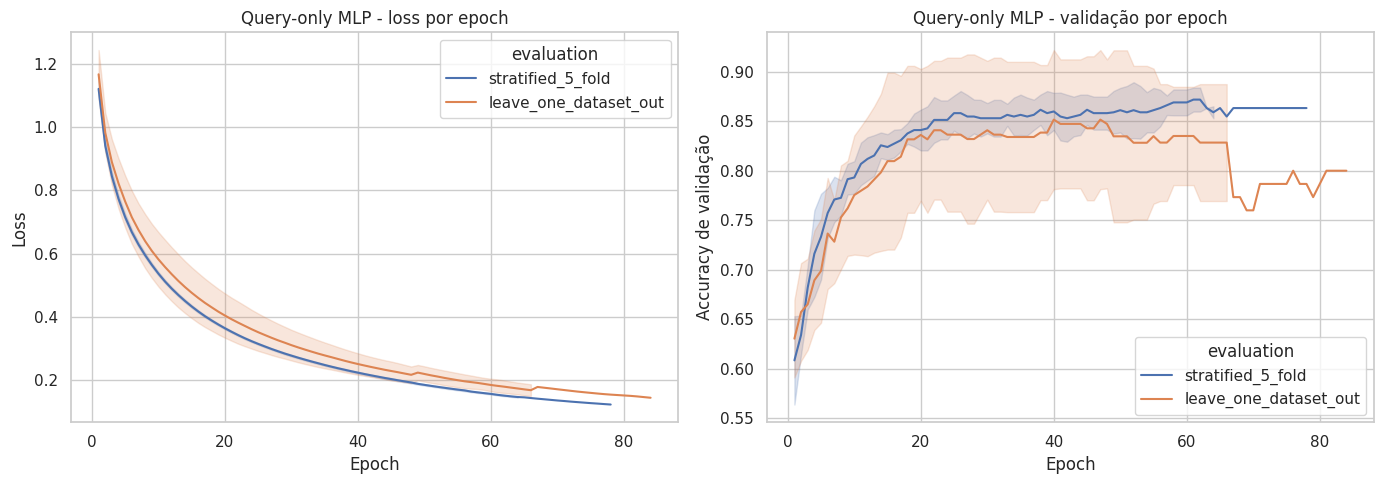

In [52]:
query_only_benchmark = run_query_only_benchmark(
    rankings=rankings_all,
    metric_deltas=query_deltas,
    output_dir=".",
)

query_only_summary = query_only_benchmark["summary"].sort_values(
    ["evaluation", "roc_auc"], ascending=[True, False]
)
display(query_only_summary.round(4))

plt.figure(figsize=(11, 6))
sns.barplot(
    data=query_only_summary,
    x="roc_auc", y="model", hue="evaluation",
)
plt.axvline(0.5, color="black", linestyle="--", linewidth=1)
plt.xlim(0, 1)
plt.title("Benchmark query-only para decidir quando rerankear")
plt.tight_layout()
plt.savefig("query_only_model_benchmark.png", dpi=160, bbox_inches="tight")
plt.show()

query_only_training_history = query_only_benchmark["training_history"]
display(query_only_training_history.head())

if not query_only_training_history.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

    sns.lineplot(
        data=query_only_training_history,
        x="epoch", y="loss", hue="evaluation",
        estimator="mean", ci="sd", ax=axes[0],
    )
    axes[0].set_title("Query-only MLP - loss por epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    validation_history = query_only_training_history.dropna(subset=["validation_score"])
    sns.lineplot(
        data=validation_history,
        x="epoch", y="validation_score", hue="evaluation",
        estimator="mean", ci="sd", ax=axes[1],
    )
    axes[1].set_title("Query-only MLP - validação por epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy de validação")

    plt.tight_layout()
    plt.savefig("query_only_mlp_training_epochs.png", dpi=160, bbox_inches="tight")
    plt.show()


## Auditoria prática da política query-only

Esta seção usa as predições fora-do-fold do benchmark query-only para simular uma política seletiva: executar sempre o BM25, chamar o BGE-Reranker apenas quando o classificador prediz benefício e comparar qualidade/custo contra sempre rerankear.

O tempo seletivo é estimado como `tempo_BM25 + decisão * (tempo_BM25+BGE - tempo_BM25) + tempo_inferência_classificador`. Para modelos baseados em embedding, o tempo médio de gerar embeddings das queries também entra na inferência do classificador.


,model,evaluation,queries,positive_rate,accuracy,rerank_rate,mean_delta_always_rerank,mean_delta_selective_policy,mean_time_bm25_sec,mean_time_always_rerank_sec,mean_time_selective_policy_sec,mean_classifier_inference_sec,total_time_saved_vs_always_rerank_ratio
5,linguistic_gradient_boosting,leave_one_dataset_out,673,0.280832,0.459138,0.473997,0.025234,0.014324,0.083253,3.335738,1.634732,0.000027,0.509934
3,char_tfidf_logistic,leave_one_dataset_out,673,0.280832,0.643388,0.239227,0.025234,0.013816,0.083253,3.335738,0.865591,0.000225,0.740510
1,word_tfidf_logistic,leave_one_dataset_out,673,0.280832,0.534918,0.383358,0.025234,0.010720,0.083253,3.335738,1.333605,0.000047,0.600207
7,embedding_logistic,leave_one_dataset_out,673,0.280832,0.549777,0.359584,0.025234,0.009755,0.083253,3.335738,1.250461,0.000551,0.625132
9,embedding_mlp,leave_one_dataset_out,673,0.280832,0.543834,0.335810,0.025234,0.005901,0.083253,3.335738,1.177618,0.000550,0.646969
6,embedding_logistic,stratified_5_fold,673,0.280832,0.624071,0.350669,0.025234,0.014836,0.083253,3.335738,1.220626,0.000551,0.634076
8,embedding_mlp,stratified_5_fold,673,0.280832,0.683507,0.276374,0.025234,0.013025,0.083253,3.335738,0.979738,0.000550,0.706290
2,char_tfidf_logistic,stratified_5_fold,673,0.280832,0.719168,0.258544,0.025234,0.012794,0.083253,3.335738,0.919628,0.000225,0.724311
0,word_tfidf_logistic,stratified_5_fold,673,0.280832,0.707281,0.252600,0.025234,0.012100,0.083253,3.335738,0.900201,0.000047,0.730134
4,linguistic_gradient_boosting,stratified_5_fold,673,0.280832,0.569094,0.358098,0.025234,0.002770,0.083253,3.335738,1.243485,0.000027,0.627223


,model,input,queries,predict_total_sec,predict_avg_sec,embedding_encode_avg_sec,classifier_inference_avg_sec
0,word_tfidf_logistic,text,673,0.031829,0.000047,0.000000,0.000047
1,char_tfidf_logistic,text,673,0.151526,0.000225,0.000000,0.000225
2,linguistic_gradient_boosting,linguistic,673,0.017986,0.000027,0.000000,0.000027
3,embedding_logistic,embedding,673,0.003644,0.000005,0.000545,0.000551
4,embedding_mlp,embedding,673,0.003353,0.000005,0.000545,0.000550


,dataset,query_id,query_text,rerank_probability,decision,actual_outcome,delta_nDCG@10,correct_decision,bm25_elapsed_sec,bm25_bge_elapsed_sec,estimated_selective_elapsed_sec,time_saved_vs_always_rerank_sec
6127,SciFact,312,De novo assembly of sequence data has more spe...,0.993953,rerankear,empatou,0.000000,False,0.019696,3.278997,3.279547,-0.000550
6411,NF-Corpus,PLAIN-44,Who Should be Careful About Curcumin?,0.006588,usar BM25,melhorou,0.040196,False,0.006927,3.352728,0.007478,3.345251
6338,SciFact,1319,Transplanted human glial cells can differentia...,0.008594,usar BM25,melhorou,0.200253,False,0.014552,3.206262,0.015103,3.191159
6154,SciFact,478,Golli-deficient T-cells prefer to differentiat...,0.010138,usar BM25,melhorou,0.369070,False,0.036994,3.294855,0.037545,3.257311
6514,NF-Corpus,PLAIN-1193,flax oil,0.010394,usar BM25,melhorou,0.075242,False,0.002358,3.390103,0.002909,3.387194
6429,NF-Corpus,PLAIN-238,How Chemically Contaminated Are We?,0.010746,usar BM25,melhorou,0.085143,False,0.005070,3.024535,0.005620,3.018915
6652,NF-Corpus,PLAIN-2670,Is Caramel Color Carcinogenic?,0.013244,usar BM25,melhorou,0.149824,False,0.006269,3.292285,0.006820,3.285466
6311,SciFact,1207,The composition of myosin-II isoform switches ...,0.014320,usar BM25,melhorou,0.569323,False,0.030479,3.308929,0.031030,3.277900
6622,NF-Corpus,PLAIN-2354,walnut oil,0.014596,usar BM25,melhorou,0.044406,False,0.003628,3.334932,0.004178,3.330754
6658,NF-Corpus,PLAIN-2730,Anti-Angiogenesis: Cutting Off Tumor Supply Lines,0.014785,usar BM25,melhorou,0.408798,False,0.010038,3.275116,0.010589,3.264528


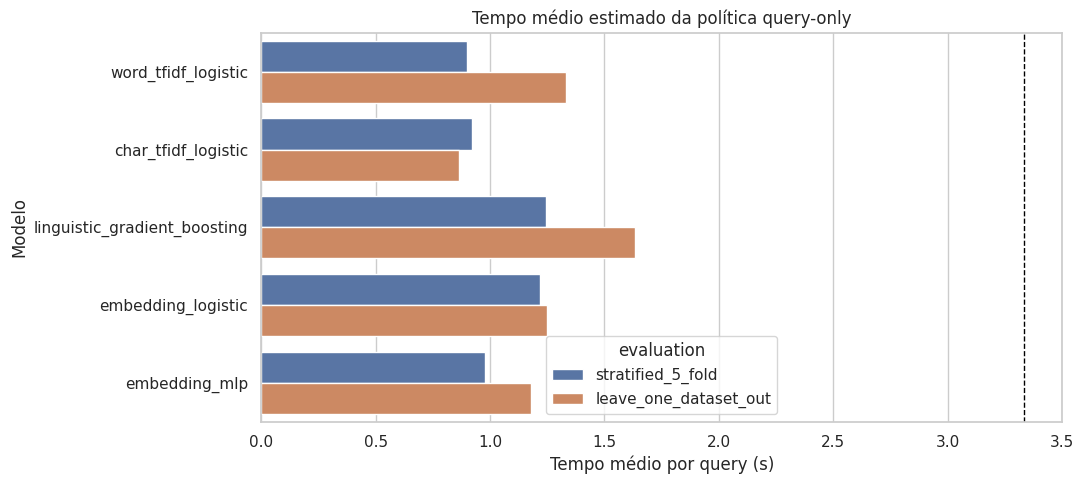

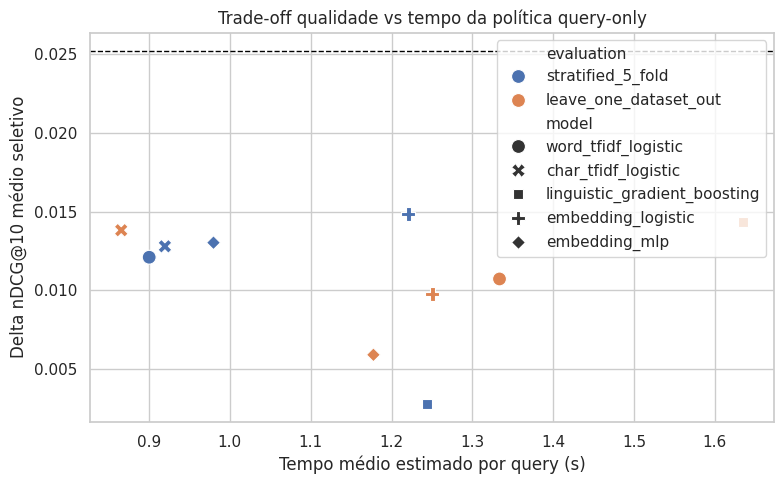

In [53]:
def measure_query_only_inference_time(data, embeddings, embedding_encode_avg_sec=0.0):
    y = data["rerank_beneficial"].to_numpy()
    linguistic_columns = list(query_features("").keys())
    rows = []

    for model_name, (input_type, template, oversample) in query_only_model_specs().items():
        x = benchmark_input(data, input_type, linguistic_columns, embeddings)
        x_train, y_train = x, y
        if oversample:
            x_train, y_train = balance_training_fold(x_train, y_train, QUERY_ONLY_SEED)

        model = clone(template).fit(x_train, y_train)
        start = time.perf_counter()
        _ = model.predict_proba(x)[:, 1]
        predict_elapsed_sec = time.perf_counter() - start
        predict_avg_sec = safe_ratio(predict_elapsed_sec, len(data))
        embedding_avg_sec = embedding_encode_avg_sec if input_type == "embedding" else 0.0

        rows.append({
            "model": model_name,
            "input": input_type,
            "queries": len(data),
            "predict_total_sec": predict_elapsed_sec,
            "predict_avg_sec": predict_avg_sec,
            "embedding_encode_avg_sec": embedding_avg_sec,
            "classifier_inference_avg_sec": predict_avg_sec + embedding_avg_sec,
        })

    return pd.DataFrame(rows)


def build_query_only_policy_audit(query_only_benchmark, results_all):
    data = query_only_benchmark["dataset"]
    embeddings = query_only_benchmark["embeddings"]
    timing = query_only_benchmark.get("timing", {})
    inference_timing = measure_query_only_inference_time(
        data,
        embeddings,
        embedding_encode_avg_sec=timing.get("embedding_encode_avg_sec", 0.0),
    )

    elapsed = results_all[["dataset", "query_id", "pipeline", "elapsed_sec"]].copy()
    elapsed["query_id"] = elapsed["query_id"].astype(str)
    elapsed = elapsed.pivot_table(
        index=["dataset", "query_id"],
        columns="pipeline",
        values="elapsed_sec",
        aggfunc="first",
    ).reset_index()
    elapsed = elapsed.rename(columns={
        "BM25": "bm25_elapsed_sec",
        "BM25 + BGE-Reranker": "bm25_bge_elapsed_sec",
    })

    audit = query_only_benchmark["predictions"].copy()
    audit["query_id"] = audit["query_id"].astype(str)
    audit = audit.merge(elapsed, on=["dataset", "query_id"], how="left")
    audit = audit.merge(
        inference_timing[["model", "classifier_inference_avg_sec"]],
        on="model",
        how="left",
    )
    audit["reranker_extra_elapsed_sec"] = (
        audit["bm25_bge_elapsed_sec"] - audit["bm25_elapsed_sec"]
    ).clip(lower=0)
    audit["estimated_selective_elapsed_sec"] = (
        audit["bm25_elapsed_sec"]
        + audit["rerank_predicted"] * audit["reranker_extra_elapsed_sec"]
        + audit["classifier_inference_avg_sec"].fillna(0)
    )
    audit["time_saved_vs_always_rerank_sec"] = (
        audit["bm25_bge_elapsed_sec"] - audit["estimated_selective_elapsed_sec"]
    )
    audit["selected_delta_nDCG@10"] = audit["delta_nDCG@10"] * audit["rerank_predicted"]
    audit["actual_beneficial"] = audit["rerank_beneficial"].astype(int)
    audit["correct_decision"] = audit["rerank_predicted"].eq(audit["actual_beneficial"])
    audit["decision"] = np.where(audit["rerank_predicted"] == 1, "rerankear", "usar BM25")
    audit["actual_outcome"] = np.select(
        [audit["delta_nDCG@10"] > TARGET_THRESHOLD, audit["delta_nDCG@10"] < -TARGET_THRESHOLD],
        ["melhorou", "piorou"],
        default="empatou",
    )
    return audit, inference_timing


def summarize_query_only_policy(audit):
    rows = []
    for (model, evaluation), group in audit.groupby(["model", "evaluation"], sort=False):
        always_rerank_total = group["bm25_bge_elapsed_sec"].sum()
        selective_total = group["estimated_selective_elapsed_sec"].sum()
        rows.append({
            "model": model,
            "evaluation": evaluation,
            "queries": len(group),
            "positive_rate": group["actual_beneficial"].mean(),
            "accuracy": group["correct_decision"].mean(),
            "rerank_rate": group["rerank_predicted"].mean(),
            "mean_delta_always_rerank": group["delta_nDCG@10"].mean(),
            "mean_delta_selective_policy": group["selected_delta_nDCG@10"].mean(),
            "mean_time_bm25_sec": group["bm25_elapsed_sec"].mean(),
            "mean_time_always_rerank_sec": group["bm25_bge_elapsed_sec"].mean(),
            "mean_time_selective_policy_sec": group["estimated_selective_elapsed_sec"].mean(),
            "mean_classifier_inference_sec": group["classifier_inference_avg_sec"].mean(),
            "total_time_saved_vs_always_rerank_ratio": 1.0 - safe_ratio(selective_total, always_rerank_total),
        })
    return pd.DataFrame(rows)


query_only_policy_audit, query_only_inference_timing = build_query_only_policy_audit(
    query_only_benchmark,
    results_all,
)
query_only_policy_summary = summarize_query_only_policy(query_only_policy_audit)

query_only_policy_audit.to_csv("query_only_policy_query_audit.csv", index=False)
query_only_policy_summary.to_csv("query_only_policy_time_quality_summary.csv", index=False)
query_only_inference_timing.to_csv("query_only_inference_timing.csv", index=False)

display(query_only_policy_summary.sort_values(
    ["evaluation", "mean_delta_selective_policy"], ascending=[True, False]
).round(6))
display(query_only_inference_timing.round(6))

example_model = "embedding_mlp"
example_evaluation = "leave_one_dataset_out"
query_only_policy_examples = query_only_policy_audit[
    (query_only_policy_audit["model"] == example_model)
    & (query_only_policy_audit["evaluation"] == example_evaluation)
].copy()
if query_only_policy_examples.empty:
    query_only_policy_examples = query_only_policy_audit.copy()

query_only_policy_examples["confidence"] = (query_only_policy_examples["rerank_probability"] - 0.5).abs()
query_only_policy_examples = query_only_policy_examples.sort_values(
    ["correct_decision", "confidence"], ascending=[True, False]
).head(20)

display(query_only_policy_examples[[
    "dataset", "query_id", "query_text", "rerank_probability", "decision",
    "actual_outcome", "delta_nDCG@10", "correct_decision",
    "bm25_elapsed_sec", "bm25_bge_elapsed_sec", "estimated_selective_elapsed_sec",
    "time_saved_vs_always_rerank_sec",
]].round(6))

plt.figure(figsize=(11, 5))
sns.barplot(
    data=query_only_policy_summary,
    x="mean_time_selective_policy_sec", y="model", hue="evaluation",
)
plt.axvline(
    query_only_policy_audit["bm25_bge_elapsed_sec"].mean(),
    color="black", linestyle="--", linewidth=1, label="Sempre rerankear",
)
plt.title("Tempo médio estimado da política query-only")
plt.xlabel("Tempo médio por query (s)")
plt.ylabel("Modelo")
plt.tight_layout()
plt.savefig("query_only_policy_time_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=query_only_policy_summary,
    x="mean_time_selective_policy_sec",
    y="mean_delta_selective_policy",
    hue="evaluation",
    style="model",
    s=100,
)
plt.axhline(query_only_policy_audit["delta_nDCG@10"].mean(), color="black", linestyle="--", linewidth=1)
plt.title("Trade-off qualidade vs tempo da política query-only")
plt.xlabel("Tempo médio estimado por query (s)")
plt.ylabel("Delta nDCG@10 médio seletivo")
plt.tight_layout()
plt.savefig("query_only_policy_quality_time_tradeoff.png", dpi=160, bbox_inches="tight")
plt.show()


## Limitações do experimento

- O reranker só reordena os documentos que vieram do BM25; se um documento relevante não entra nos candidatos iniciais, ele não pode aparecer no ranking final.
- O BGE-Reranker pode ter sido treinado em dados próximos a alguns domínios avaliados, o que pode favorecer certos datasets.
- O custo computacional do reranker é maior que o do BM25, especialmente quando `BM25_TOP_N` cresce.
- Os datasets avaliados são em inglês e têm forte viés científico/biomédico; os resultados não necessariamente transferem para outro idioma ou domínio.
- A visualização 3D é ilustrativa: PCA reduz embeddings de alta dimensão para três dimensões e pode distorcer distâncias.
- Bons resultados em BEIR não garantem automaticamente bom desempenho em uma base real de produção, com documentos mais ruidosos, longos ou desatualizados.


### Organizar outputs na pasta `results/`

Esta célula cria a pasta `results/` e move para lá todos os artefatos gerados pelo notebook. Se a pasta já tiver arquivos antigos do relatório, eles são substituídos antes de salvar a nova execução.


In [54]:
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

OUTPUT_EXTENSIONS = {".csv", ".json", ".png", ".html", ".md"}

RESULT_SUBDIR_RULES = [
    ("rankings", lambda p: p.name.startswith("rankings") or p.name.startswith("query_rankings")),
    ("qualitative", lambda p: "qualitative" in p.name or "failure" in p.name or "rank_overlap" in p.name or "relevant_documents" in p.name),
    ("visualizations", lambda p: "visualization" in p.name or p.suffix.lower() in {".png", ".html"}),
    ("metrics", lambda p: p.name.startswith("results") or "summary" in p.name or "metrics" in p.name or "deltas" in p.name or "precision_recall" in p.name),
    ("reports", lambda p: p.suffix.lower() == ".md" or "report" in p.name or "relatorio" in p.name.lower()),
]


def output_subdir_for(file_path):
    for subdir_name, predicate in RESULT_SUBDIR_RULES:
        if predicate(file_path):
            return subdir_name
    return "other"

# Limpa artefatos antigos dentro de results/ para evitar mistura entre execuções.
for old_path in sorted(RESULTS_DIR.rglob("*"), reverse=True):
    if old_path.is_file() and old_path.suffix.lower() in OUTPUT_EXTENSIONS:
        old_path.unlink()
    elif old_path.is_dir() and not any(old_path.iterdir()):
        old_path.rmdir()

moved_files = []
for file_path in Path(".").iterdir():
    if not file_path.is_file():
        continue
    if file_path.suffix.lower() not in OUTPUT_EXTENSIONS:
        continue
    if file_path.name.startswith("results_outputs"):
        continue

    subdir = output_subdir_for(file_path)
    destination_dir = RESULTS_DIR / subdir
    destination_dir.mkdir(parents=True, exist_ok=True)

    destination = destination_dir / file_path.name
    if destination.exists():
        destination.unlink()
    file_path.replace(destination)
    moved_files.append(str(destination.relative_to(RESULTS_DIR)))

moved_files = sorted(moved_files)
print(f"Arquivos organizados em {RESULTS_DIR}/: {len(moved_files)}")
for file_name in moved_files:
    print("-", file_name)


Arquivos organizados em results/: 216
- metrics/metrics_heatmap_values.csv
- metrics/precision_recall_curves.csv
- metrics/precision_recall_per_query.csv
- metrics/quality_cost_summary.csv
- metrics/query_level_metric_deltas.csv
- metrics/query_only_policy_time_quality_summary.csv
- metrics/results_all_datasets.csv
- metrics/results_nfcorpus_bm25.csv
- metrics/results_nfcorpus_bm25_bge_reranker.csv
- metrics/results_rrf_bm25_bge.csv
- metrics/results_scifact_bm25.csv
- metrics/results_scifact_bm25_bge_reranker.csv
- metrics/results_trec_covid_bm25.csv
- metrics/results_trec_covid_bm25_bge_reranker.csv
- metrics/summary_all_datasets.csv
- metrics/summary_rrf_bm25_bge.csv
- metrics/summary_with_rrf_bm25_bge.csv
- metrics/top10_overlap_bm25_bge_summary.csv
- other/automatic_conclusions_by_dataset.csv
- other/candidate_recall_all_datasets.csv
- other/candidate_recall_nfcorpus.csv
- other/candidate_recall_scifact.csv
- other/candidate_recall_trec_covid.csv
- other/dataset_descriptive_stats.

### Lista de arquivos gerados

Esta célula apenas imprime os nomes dos CSVs, PNGs e HTMLs que foram salvos durante a execução do notebook.


In [55]:
RESULTS_DIR = Path("results")
if RESULTS_DIR.exists():
    result_files = sorted(path for path in RESULTS_DIR.rglob("*") if path.is_file())
    print(f"Arquivos salvos em {RESULTS_DIR}/ ({len(result_files)} arquivos):")
    for file_path in result_files:
        print("-", file_path.relative_to(RESULTS_DIR))
else:
    print("A pasta results/ ainda não existe. Execute a célula 'Organizar outputs na pasta results/' primeiro.")


Arquivos salvos em results/ (216 arquivos):
- metrics/metrics_heatmap_values.csv
- metrics/precision_recall_curves.csv
- metrics/precision_recall_per_query.csv
- metrics/quality_cost_summary.csv
- metrics/query_level_metric_deltas.csv
- metrics/query_only_policy_time_quality_summary.csv
- metrics/results_all_datasets.csv
- metrics/results_nfcorpus_bm25.csv
- metrics/results_nfcorpus_bm25_bge_reranker.csv
- metrics/results_rrf_bm25_bge.csv
- metrics/results_scifact_bm25.csv
- metrics/results_scifact_bm25_bge_reranker.csv
- metrics/results_trec_covid_bm25.csv
- metrics/results_trec_covid_bm25_bge_reranker.csv
- metrics/summary_all_datasets.csv
- metrics/summary_rrf_bm25_bge.csv
- metrics/summary_with_rrf_bm25_bge.csv
- metrics/top10_overlap_bm25_bge_summary.csv
- other/automatic_conclusions_by_dataset.csv
- other/candidate_recall_all_datasets.csv
- other/candidate_recall_nfcorpus.csv
- other/candidate_recall_scifact.csv
- other/candidate_recall_trec_covid.csv
- other/dataset_descriptive_

### Download dos resultados no Colab

Esta célula usa `google.colab.files` para baixar os principais arquivos gerados: resultados consolidados, gráficos estáticos e visualizações interativas em HTML.


In [56]:
# Opcional: compactar e baixar todos os resultados do Colab.
from google.colab import files

RESULTS_DIR = Path("results")
if not RESULTS_DIR.exists():
    raise FileNotFoundError("A pasta results/ não existe. Execute a célula 'Organizar outputs na pasta results/' primeiro.")

zip_path = shutil.make_archive("results_outputs", "zip", RESULTS_DIR)
files.download(zip_path)
print(f"Arquivo compactado para download: {zip_path}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Arquivo compactado para download: /content/results_outputs.zip
